In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as ui

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** ML Linear Regression'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/Heart_ML_DropNaNs.pkl")
df_label = pd.read_pickle("../Data/Label_ML.pkl")
df_can = pd.read_pickle("../Data/CAN_ML.pkl")
df_don = pd.read_pickle("../Data/DON_ML.pkl")
df_both = pd.read_pickle("../Data/BOTH_ML.pkl")
df_nominal = pd.read_pickle("../Data/Nominal_ML.pkl")
df_ordinal = pd.read_pickle("../Data/Ordinal_ML.pkl")
df_numeric = pd.read_pickle("../Data/Numeric_ML.pkl")
df_object = pd.read_pickle("../Data/Object_ML.pkl")
df_date = pd.read_pickle("../Data/Date_ML.pkl")
df_dict = pd.read_pickle("../Data/Dictionary_ML.pkl")
df_drop = pd.read_pickle("../Data/Drop_ML.pkl")
df_unknown = pd.read_pickle("../Data/Unknown_ML.pkl")
df_new = pd.read_pickle("../Data/New_ML.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

### Feature Information

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"New Features: {df_new.shape[0]:,}")

Heart Dataset Rows: 9,850 & Columns: 220
Label Features: 1
Candidate Features: 114
Donor Features: 88
Date Features: 0
Both Features: 22
Object Features: 0
Numeric Features: 42
Ordinal Features: 12
Nominal Features: 166
Drop Features: 0
Unknown Features: 0
New Features: 29


### User Function(s)

In [4]:
def getFeatureList(data, string):
    # initialize features and sort them alphabetically
    features = sorted(data.columns[data.columns.str.contains(string)].tolist())

    # display
    print(data[features].describe(include='all').T.to_string())
    print("\n:::: NaN Count:")
    print(data[features].isna().sum().sort_index().to_string())

    return features

### Determine Candidate Survival for 600 Days

In [5]:
# remove unwanted labels
removeCols = df_label.column.to_list()

# create new feature
df['Survival'] = df.TransplantSurvivalDay >= 600
# add to dataframe
df_label  = uf.insertIntoDataFrame(df_label, ['Survival'])

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

# shape
df.shape

Data Dictionary Updated.
Remove 1 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 1 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['TransplantSurvivalDay']

Total Row(s) & Column(s) Before Removing Column(s): 9,850 & columns: 221
Total Row(s) & Column(s) After Removing Column(s): 9,850 & columns: 220


(9850, 220)

In [6]:
df.Survival.value_counts()

Survival
True     5414
False    4436
Name: count, dtype: int64

#### Remove NaNs

In [7]:
# shape
print(f"Total Number of Rows: {df.shape[0]} & Total Number of Features {df.shape[1]}")

Total Number of Rows: 9850 & Total Number of Features 220


#### Examine NaNs

In [8]:
# get NaNs
NaNsDF = uf.percentageNull(df)

# display NaNs
NaNsDF

,percentage,NaNCount


#### Describe

In [9]:
df[df_can.column.to_list()].describe().T

,count,mean,std,min,25%,50%,75%,max
BloodUreaNitrogenLevel_DON,9850.0,26.676726,2.137065e+01,1.450000e+00,1.400000e+01,2.000000e+01,3.200000e+01,2.500000e+02
HemodynamicsRegistration_CO_CAN,9850.0,4.220457,1.295280e+00,4.500000e-01,3.300000e+00,4.100000e+00,4.950000e+00,1.353000e+01
HemodynamicsTransplant_CO_CAN,9850.0,4.453218,1.403848e+00,2.000000e-01,3.500000e+00,4.300000e+00,5.210000e+00,1.500000e+01
TotalDayWaitList_CAN,9850.0,145.834619,2.266264e+02,0.000000e+00,1.400000e+01,5.100000e+01,1.780000e+02,2.012000e+03
PanelReactiveAntibody_CPRA_Interaction_CAN,9850.0,712.905233,1.914311e+03,1.000000e-10,1.000000e-10,1.000000e-10,8.075024e+01,1.000000e+04
PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN,9850.0,3.628122,1.162356e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+02
PanelReactiveAntibody_CPRA_Addition_CAN,9850.0,25.840711,4.829463e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.900000e+01,2.000000e+02
Creatinine_Interaction_CAN,9850.0,2.713977,9.738804e+00,2.940000e-02,9.600000e-01,1.437400e+00,2.210000e+00,5.105184e+02
Creatinine_Difference_RT_CAN,9850.0,0.007662,7.356478e-01,-2.230000e+01,-1.800000e-01,0.000000e+00,1.800000e-01,1.896000e+01
Creatinine_Addition_CAN,9850.0,2.785284,1.907786e+00,3.500000e-01,1.980000e+00,2.400000e+00,3.000000e+00,4.556000e+01


In [10]:
df[df_don.column.to_list()].describe().T

,count,mean,std,min,25%,50%,75%,max
OrganRecovery_PCO2_DON,9850.0,39.163600,6.957478,17.00,34.80,38.60,43.00,106.00
DistanceFromDonorHospitaltoTXCenter,9850.0,222.027107,227.984995,0.00,33.00,161.00,350.00,2215.00
Hematocrit_DON,9850.0,28.149137,4.900109,2.50,24.80,27.60,31.00,60.60
IschemicTimeHour_DON,9850.0,3.268294,1.104085,0.30,2.60,3.30,3.90,12.00
BloodPH_DON,9850.0,7.417995,0.068044,5.57,7.38,7.42,7.46,7.93
LV_EjectionFractionPercent_DON,9850.0,61.618470,6.596256,10.00,56.00,60.00,65.00,91.00
LungPO2_DON,9850.0,280.862944,160.309480,12.00,129.00,260.85,427.00,668.00
LungPO2_FIO2_DON,9850.0,82.265787,25.318153,10.00,60.00,100.00,100.00,100.00
Level_SGOT_Difference_AltAst_DON,9850.0,20.925442,504.639591,-7648.00,-20.00,-1.00,22.00,43967.00
Level_SGOT_Addition_DON,9850.0,224.557807,726.265872,9.00,54.00,94.00,183.00,44267.00


In [11]:
df[df_ordinal.column.to_list()].describe().T

,count,unique,top,freq
MismatchLevel_AMIS,9850,4,2,4741
MismatchLevel_HLMIS,9850,8,5,3433
MismatchLevel_BMIS,9850,4,2,6633
MismatchLevel_DRMIS,9850,4,2,5093
PreviousTransplantNumber_CAN,9850,3,0,9563
EducationLevel_CAN,9850,7,HIGH SCHOOL (9-12) or GED,3571
FunctionalStatusRegistration_CAN,9850,18,"20% - Very sick, hospitalization necessary: active treatment necessary",2188
FunctionalStatusTransplant_CAN,9850,11,"20% - Very sick, hospitalization necessary: active treatment necessary",3133
DiabetesHistory_DON,9850,6,No,9410
CigaretteAbstinence_CAN,9850,10,Missing,5607


In [12]:
df[df_nominal.column.to_list()].describe().T

,count,unique,top,freq
BloodGroup_CAN,9850,8,A,3960
BloodGroup_DON,9850,8,O,4859
BloodGroupMatchLevel,9850,3,Identical,8415
InotropicAgent_DON,9850,7,Missing,6446
HeavyAlcoholUse_DON,9850,3,No,7850
AntiHypertensive_DON,9850,2,No,6393
ArginnieManagement_DON,9850,3,Yes,6968
Biopsy_DON,9850,3,Biopsy not done,9844
WaitListDiagnosisCode_CAN,9850,32,DILATED MYOPATHY: IDIOPATHIC,3501
DiagnosisAtListing_CAN,9850,34,DILATED MYOPATHY: IDIOPATHIC,3577


In [13]:
df[df_numeric.column.to_list()].describe().T

,count,mean,std,min,25%,50%,75%,max
BloodUreaNitrogenLevel_DON,9850.0,26.676726,2.137065e+01,1.450000e+00,1.400000e+01,2.000000e+01,3.200000e+01,2.500000e+02
HemodynamicsRegistration_CO_CAN,9850.0,4.220457,1.295280e+00,4.500000e-01,3.300000e+00,4.100000e+00,4.950000e+00,1.353000e+01
HemodynamicsTransplant_CO_CAN,9850.0,4.453218,1.403848e+00,2.000000e-01,3.500000e+00,4.300000e+00,5.210000e+00,1.500000e+01
TotalDayWaitList_CAN,9850.0,145.834619,2.266264e+02,0.000000e+00,1.400000e+01,5.100000e+01,1.780000e+02,2.012000e+03
OrganRecovery_PCO2_DON,9850.0,39.163600,6.957478e+00,1.700000e+01,3.480000e+01,3.860000e+01,4.300000e+01,1.060000e+02
DistanceFromDonorHospitaltoTXCenter,9850.0,222.027107,2.279850e+02,0.000000e+00,3.300000e+01,1.610000e+02,3.500000e+02,2.215000e+03
Hematocrit_DON,9850.0,28.149137,4.900109e+00,2.500000e+00,2.480000e+01,2.760000e+01,3.100000e+01,6.060000e+01
IschemicTimeHour_DON,9850.0,3.268294,1.104085e+00,3.000000e-01,2.600000e+00,3.300000e+00,3.900000e+00,1.200000e+01
BloodPH_DON,9850.0,7.417995,6.804353e-02,5.570000e+00,7.380000e+00,7.420000e+00,7.460000e+00,7.930000e+00
LV_EjectionFractionPercent_DON,9850.0,61.618470,6.596256e+00,1.000000e+01,5.600000e+01,6.000000e+01,6.500000e+01,9.100000e+01


In [14]:
df[df_both.column.to_list()].describe().T

,count,mean,std,min,25%,50%,75%,max
Age_Difference_CanDon,9850.0,21.530660,15.376301,-35.000000,11.000000,22.000000,33.000000,60.000000
Age_Addition,9850.0,86.382640,17.559023,26.000000,76.000000,87.000000,98.000000,137.000000
BMI_Difference_CanDon,9850.0,-0.064205,7.000128,-42.788380,-4.001791,0.574478,4.598691,22.206122
BMI_Addition,9850.0,55.430175,8.763950,32.503121,49.222959,54.607685,60.779593,110.418750
Creatinine_Interaction_CAN,9850.0,2.713977,9.738804,0.029400,0.960000,1.437400,2.210000,510.518400
Creatinine_Difference_RT_CAN,9850.0,0.007662,0.735648,-22.300000,-0.180000,0.000000,0.180000,18.960000
Creatinine_Addition_CAN,9850.0,2.785284,1.907786,0.350000,1.980000,2.400000,3.000000,45.560000
HeightCm_Difference_CanDon,9850.0,-0.226457,9.589461,-50.800000,-6.400000,0.000000,6.300000,41.000000
HeightCm_Addition,9850.0,347.419472,17.073923,284.000000,335.300000,348.300000,360.300000,404.100000
Level_SGOT_Difference_AltAst_DON,9850.0,20.925442,504.639591,-7648.000000,-20.000000,-1.000000,22.000000,43967.000000


In [15]:
df[df_new.column.to_list()].describe().T

,count,mean,std,min,25%,50%,75%,max
Age_Difference_CanDon,9850.0,21.530660,1.537630e+01,-3.500000e+01,1.100000e+01,2.200000e+01,3.300000e+01,6.000000e+01
Age_Addition,9850.0,86.382640,1.755902e+01,2.600000e+01,7.600000e+01,8.700000e+01,9.800000e+01,1.370000e+02
BMI_Difference_CanDon,9850.0,-0.064205,7.000128e+00,-4.278838e+01,-4.001791e+00,5.744777e-01,4.598691e+00,2.220612e+01
BMI_Addition,9850.0,55.430175,8.763950e+00,3.250312e+01,4.922296e+01,5.460769e+01,6.077959e+01,1.104188e+02
PanelReactiveAntibody_CPRA_Interaction_CAN,9850.0,712.905233,1.914311e+03,1.000000e-10,1.000000e-10,1.000000e-10,8.075024e+01,1.000000e+04
PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN,9850.0,3.628122,1.162356e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+02
PanelReactiveAntibody_CPRA_Addition_CAN,9850.0,25.840711,4.829463e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.900000e+01,2.000000e+02
Creatinine_Interaction_CAN,9850.0,2.713977,9.738804e+00,2.940000e-02,9.600000e-01,1.437400e+00,2.210000e+00,5.105184e+02
Creatinine_Difference_RT_CAN,9850.0,0.007662,7.356478e-01,-2.230000e+01,-1.800000e-01,0.000000e+00,1.800000e-01,1.896000e+01
Creatinine_Addition_CAN,9850.0,2.785284,1.907786e+00,3.500000e-01,1.980000e+00,2.400000e+00,3.000000e+00,4.556000e+01


### Wrangle

In [16]:
print(sorted([df_new.column.to_list()]))

[['Age_Difference_CanDon', 'Age_Addition', 'BMI_Difference_CanDon', 'BMI_Addition', 'PanelReactiveAntibody_CPRA_Interaction_CAN', 'PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN', 'PanelReactiveAntibody_CPRA_Addition_CAN', 'Creatinine_Interaction_CAN', 'Creatinine_Difference_RT_CAN', 'Creatinine_Addition_CAN', 'HeightCm_Difference_CanDon', 'HeightCm_Addition', 'HemodynamicsRegistration_Interaction_CAN', 'HemodynamicsRegistration_Addition_CAN', 'HemodynamicsTransplant_Interaction_CAN', 'HemodynamicsTransplant_Addition_CAN', 'Hemodynamics_Difference_CO_RT_CAN', 'Hemodynamics_Difference_PA_DIA_RT_CAN', 'Hemodynamics_Difference_PA_MN_RT_CAN', 'Hemodynamics_Difference_PCW_RT_CAN', 'Hemodynamics_Difference_SYS_RT_CAN', 'Hemodynamics_Interaction_Difference_CAN', 'Hemodynamics_Addition_Difference_CAN', 'Level_SGOT_Difference_AltAst_DON', 'Level_SGOT_Addition_DON', 'TotalBilirubin_Difference_CanDon', 'TotalBilirubin_Addition', 'WeightKg_Difference_CanDon', 'WeightKg_Addition']]


#### Age

In [17]:
# examine features
features = getFeatureList(df, 'Age_')

                        count      mean        std   min   25%   50%   75%    max
Age_Addition           9850.0  86.38264  17.559023  26.0  76.0  87.0  98.0  137.0
Age_Difference_CanDon  9850.0  21.53066  15.376301 -35.0  11.0  22.0  33.0   60.0

:::: NaN Count:
Age_Addition             0
Age_Difference_CanDon    0


In [18]:
df[features].corr()

,Age_Addition,Age_Difference_CanDon
Age_Addition,1.000000,0.156042
Age_Difference_CanDon,0.156042,1.000000


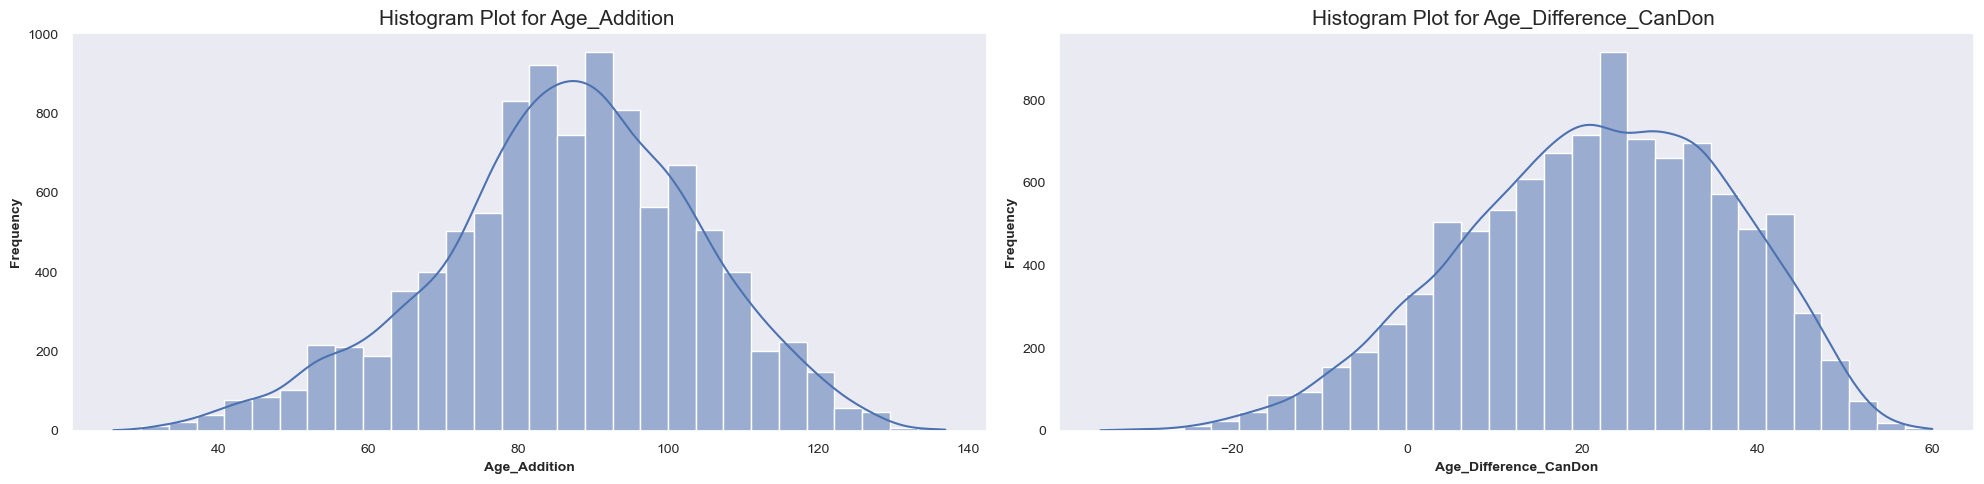

In [19]:
# plots
uv.histogramPlot(df, features, bins=30)

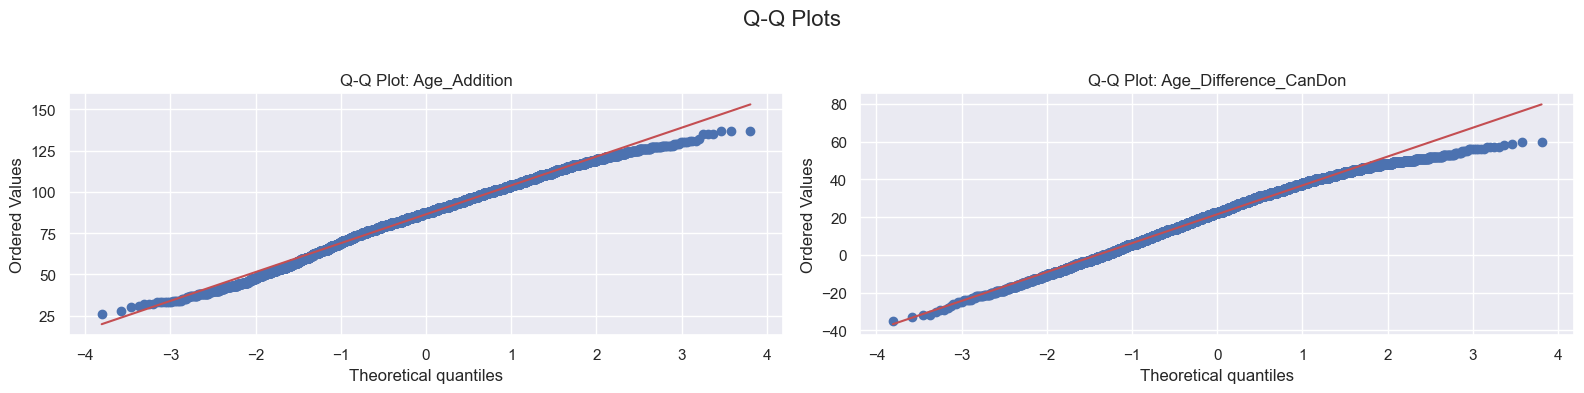

In [20]:
uv.plotQQ(df,features)

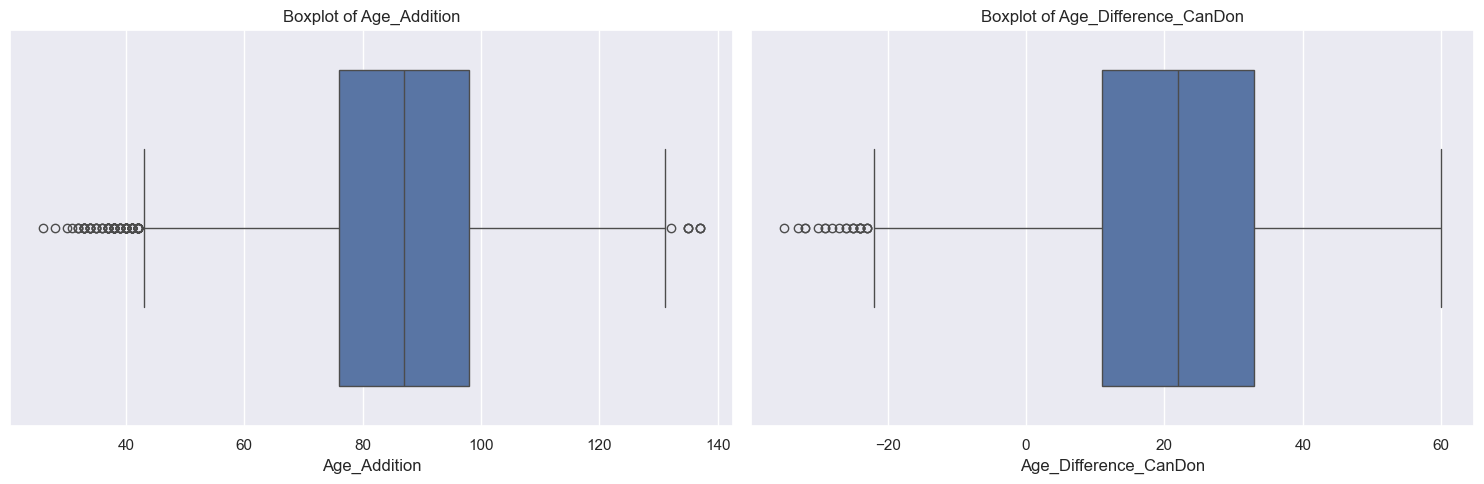

In [21]:
uv.plotBoxPlot(df, features, orientation='h')

#### BMI

In [22]:
# examine features
features = getFeatureList(df, 'BMI_')

                        count       mean       std        min        25%        50%        75%         max
BMI_Addition           9850.0  55.430175  8.763950  32.503121  49.222959  54.607685  60.779593  110.418750
BMI_Difference_CanDon  9850.0  -0.064205  7.000128 -42.788380  -4.001791   0.574478   4.598691   22.206122

:::: NaN Count:
BMI_Addition             0
BMI_Difference_CanDon    0


In [23]:
df[features].corr()

,BMI_Addition,BMI_Difference_CanDon
BMI_Addition,1.000000,-0.247713
BMI_Difference_CanDon,-0.247713,1.000000


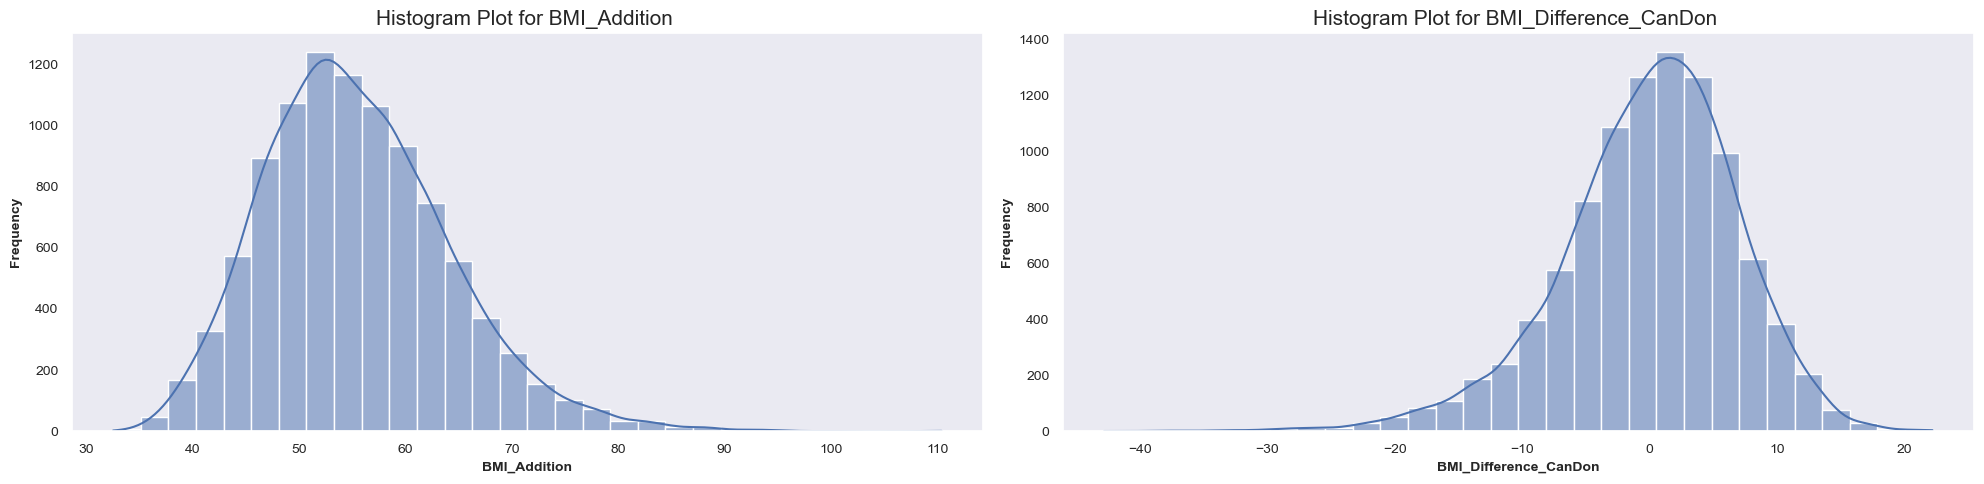

In [24]:
# plots
uv.histogramPlot(df, features, bins=30)

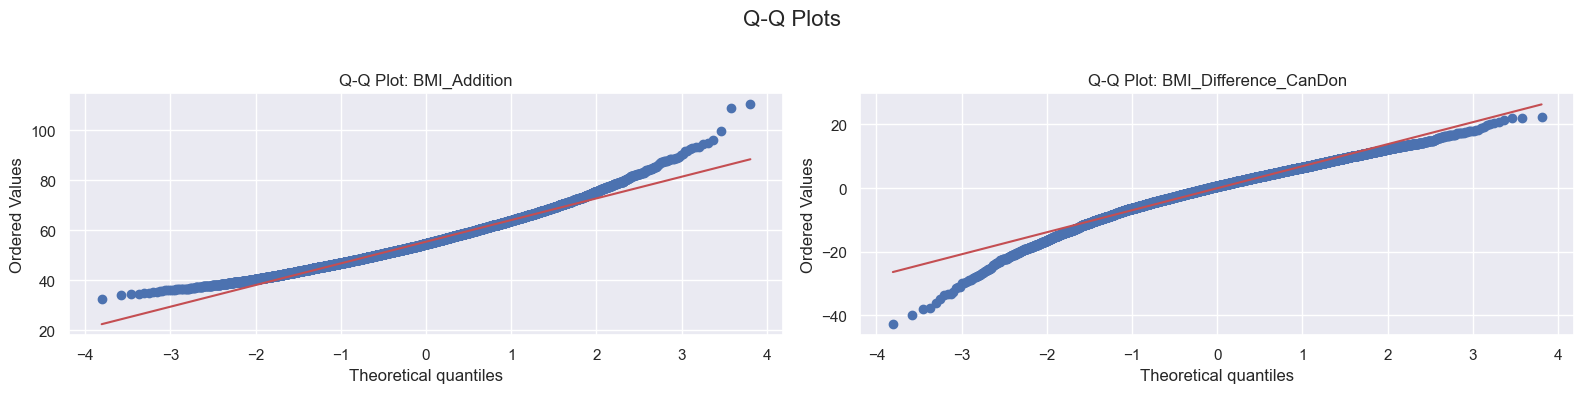

In [25]:
uv.plotQQ(df,features)

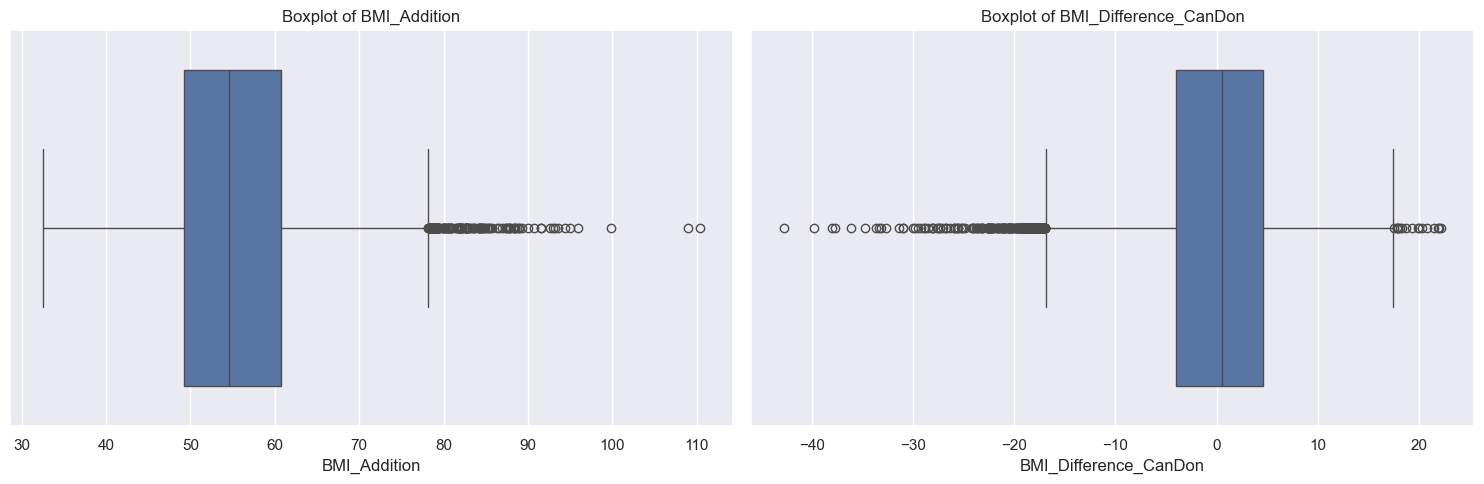

In [26]:
uv.plotBoxPlot(df, features, orientation='h')

#### CPRA

In [27]:
# examine features
features = getFeatureList(df, 'CPRA')

                                                       count        mean          std           min           25%           50%       75%        max
PanelReactiveAntibody_CPRA_Addition_CAN               9850.0   25.840711    48.294628  0.000000e+00  0.000000e+00  0.000000e+00  29.00000    200.000
PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN  9850.0    3.628122    11.623562  0.000000e+00  0.000000e+00  0.000000e+00   0.00000    100.000
PanelReactiveAntibody_CPRA_Interaction_CAN            9850.0  712.905233  1914.310975  1.000000e-10  1.000000e-10  1.000000e-10  80.75024  10000.002

:::: NaN Count:
PanelReactiveAntibody_CPRA_Addition_CAN                 0
PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN    0
PanelReactiveAntibody_CPRA_Interaction_CAN              0


In [28]:
df[features].corr()

,PanelReactiveAntibody_CPRA_Addition_CAN,PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN,PanelReactiveAntibody_CPRA_Interaction_CAN
PanelReactiveAntibody_CPRA_Addition_CAN,1.000000,0.268885,0.933500
PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN,0.268885,1.000000,0.052507
PanelReactiveAntibody_CPRA_Interaction_CAN,0.933500,0.052507,1.000000


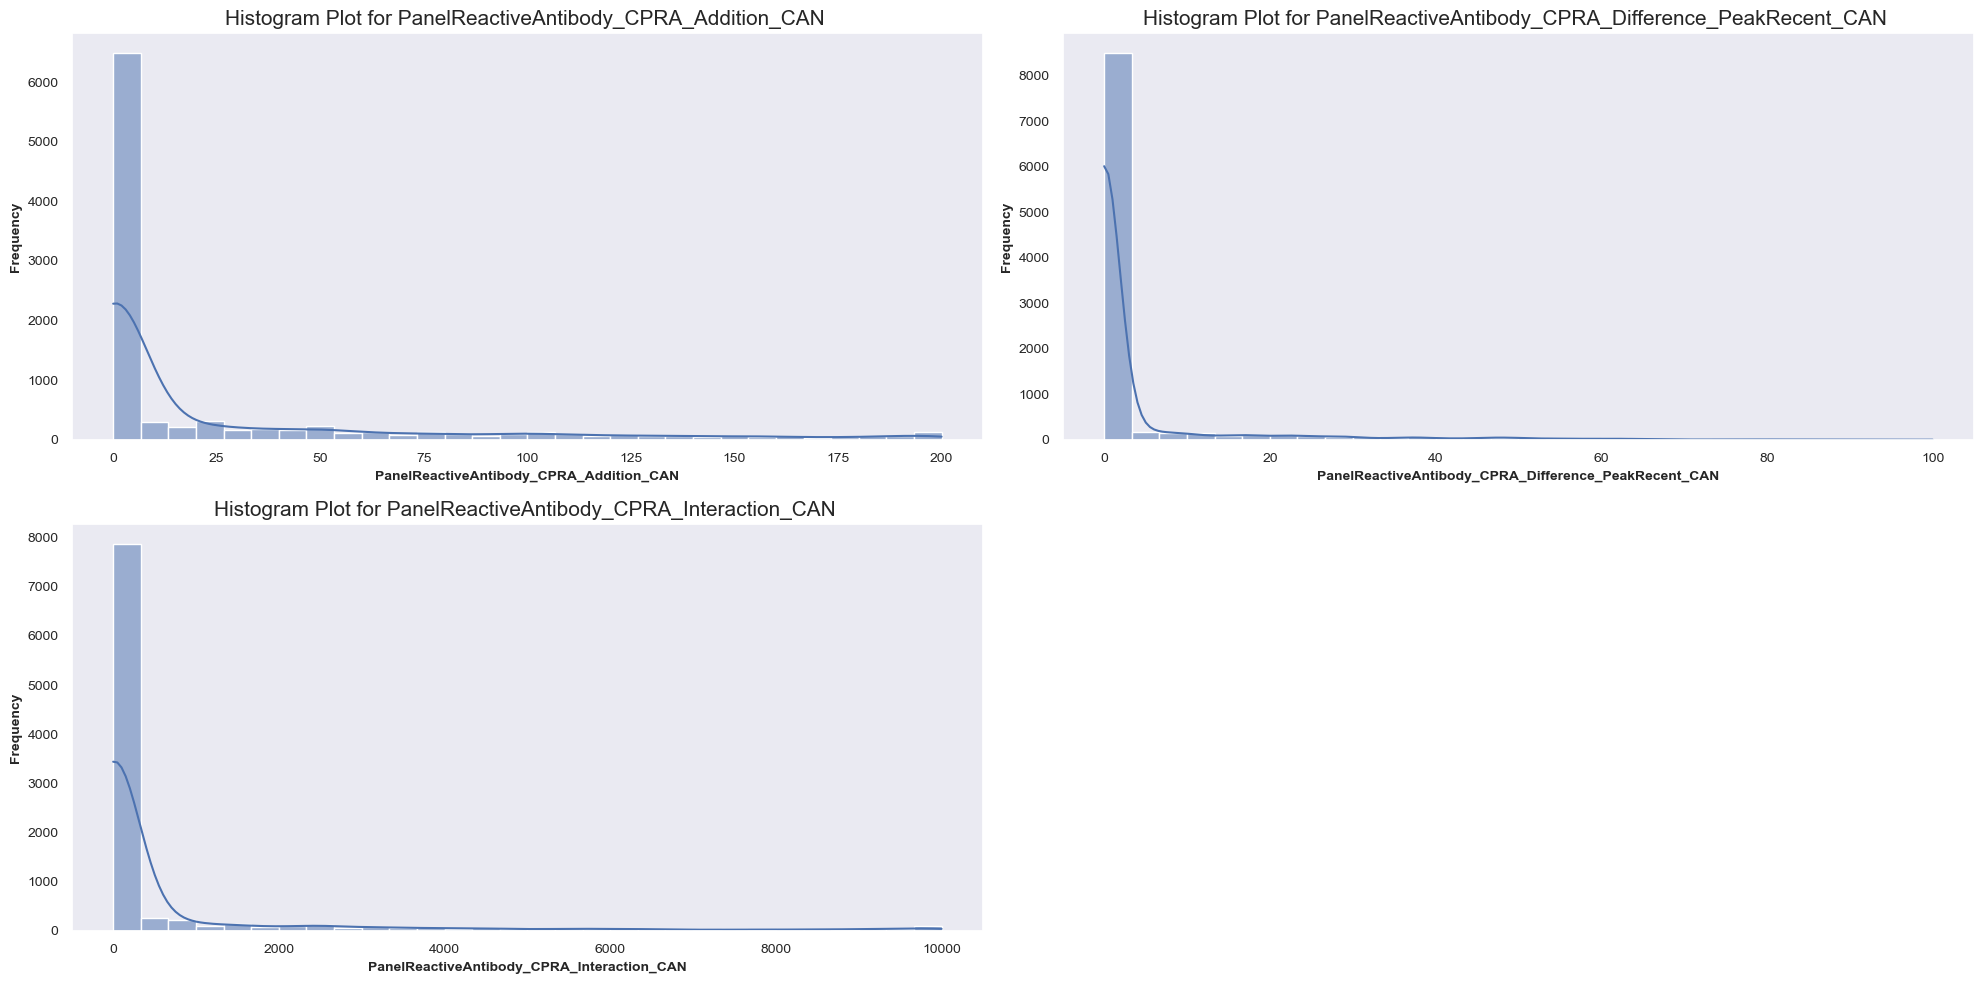

In [29]:
# plots
uv.histogramPlot(df, features, bins=30)

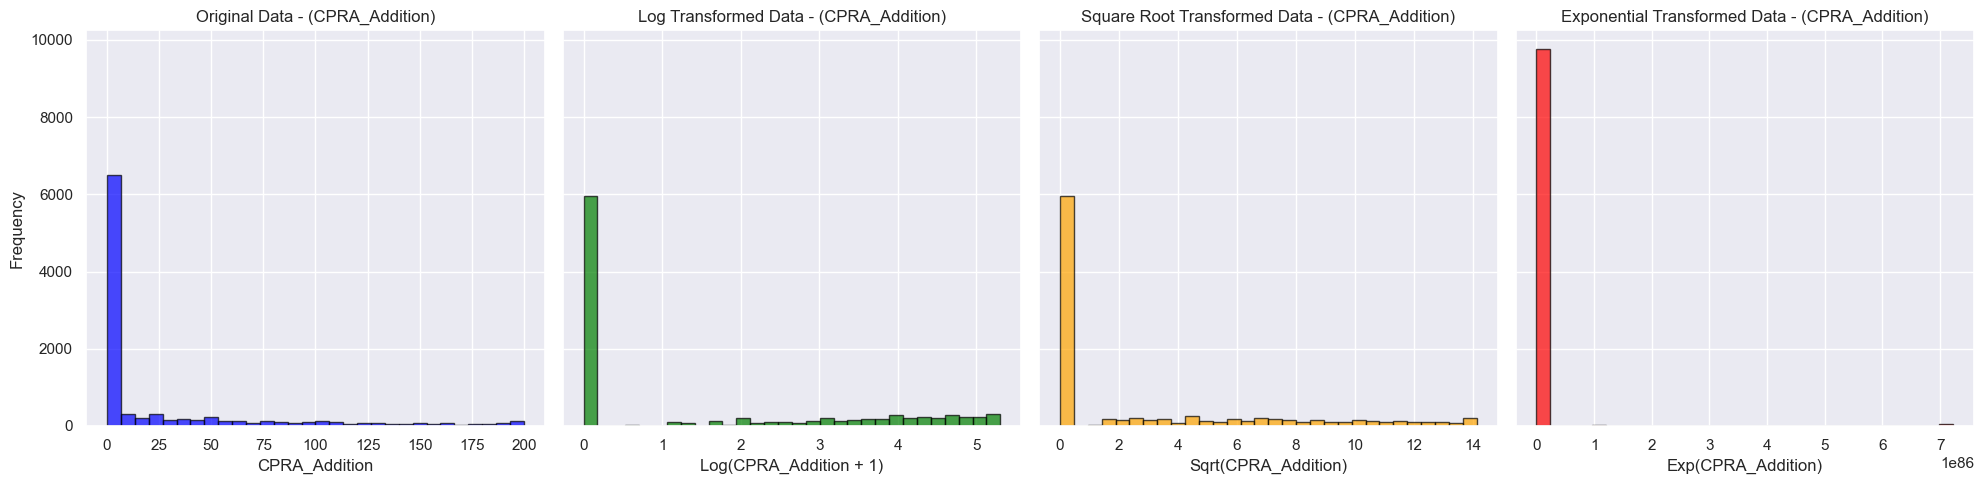

In [30]:
uv.transformPlots(df.PanelReactiveAntibody_CPRA_Addition_CAN, txt='CPRA_Addition')

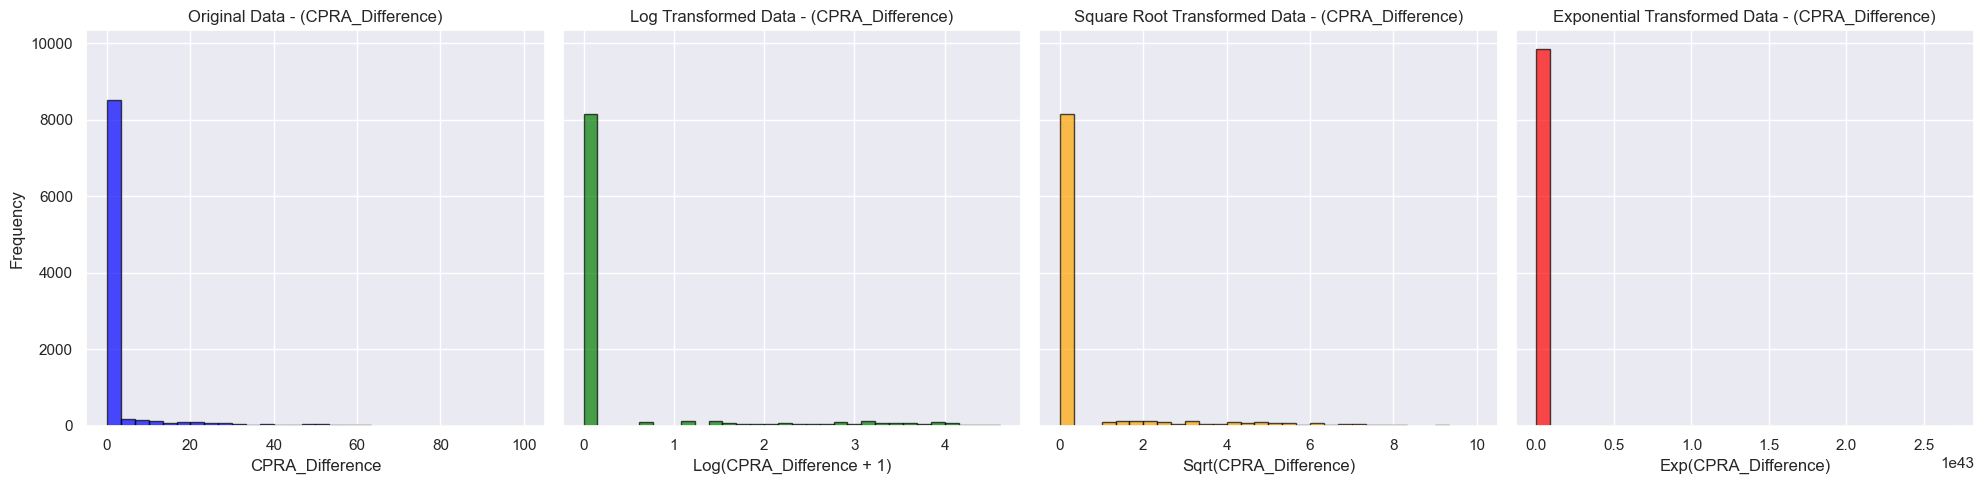

In [31]:
uv.transformPlots(df.PanelReactiveAntibody_CPRA_Difference_PeakRecent_CAN, txt='CPRA_Difference')

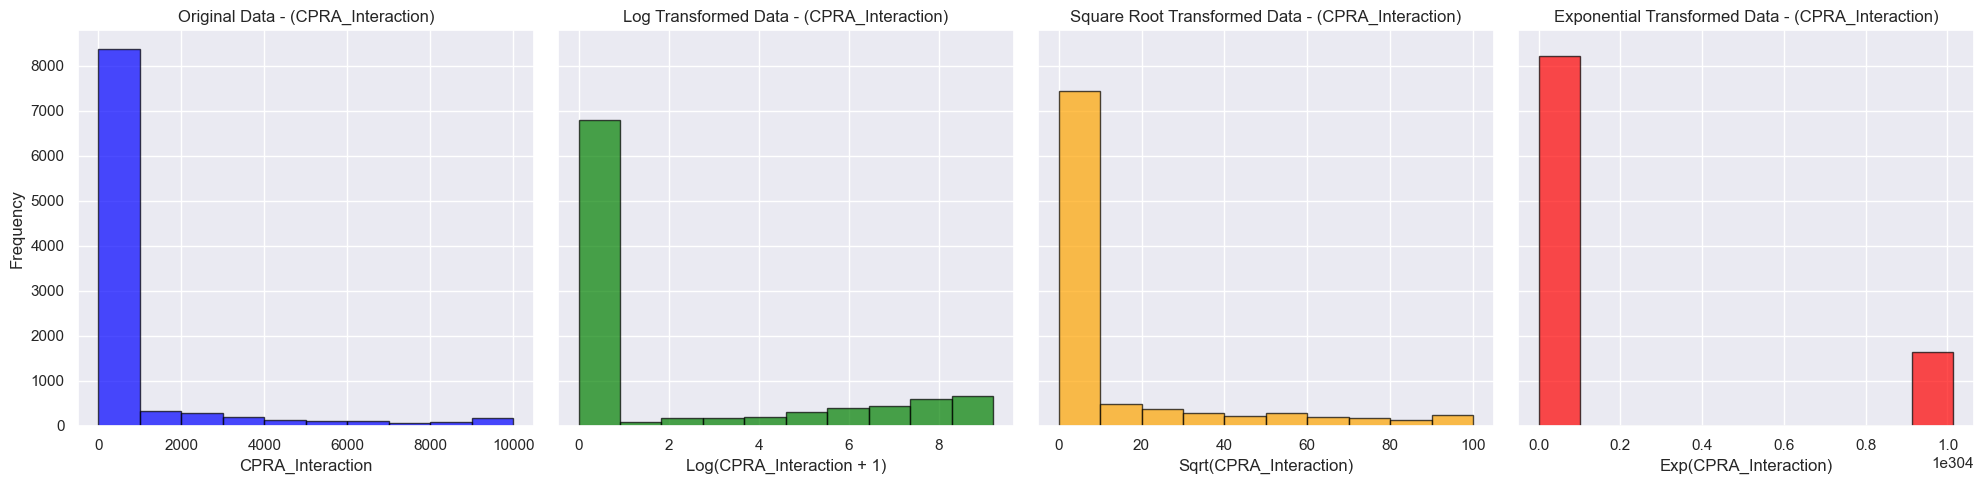

In [32]:
uv.transformPlots(df.PanelReactiveAntibody_CPRA_Interaction_CAN, txt='CPRA_Interaction', bins=10)

##### There is no transformation due to the lack of differences in the features after transformation.

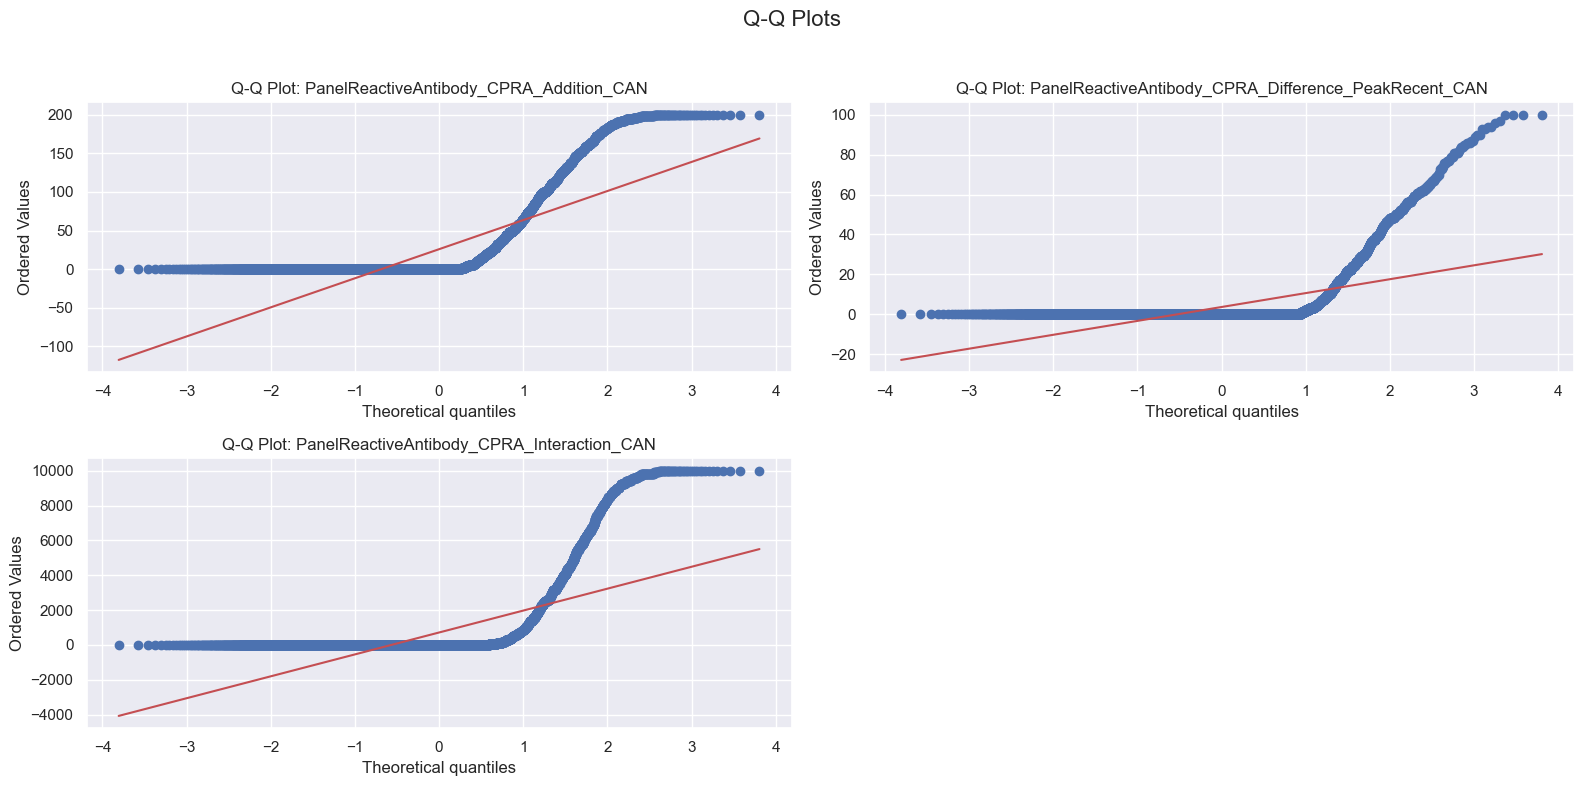

In [33]:
uv.plotQQ(df,features)

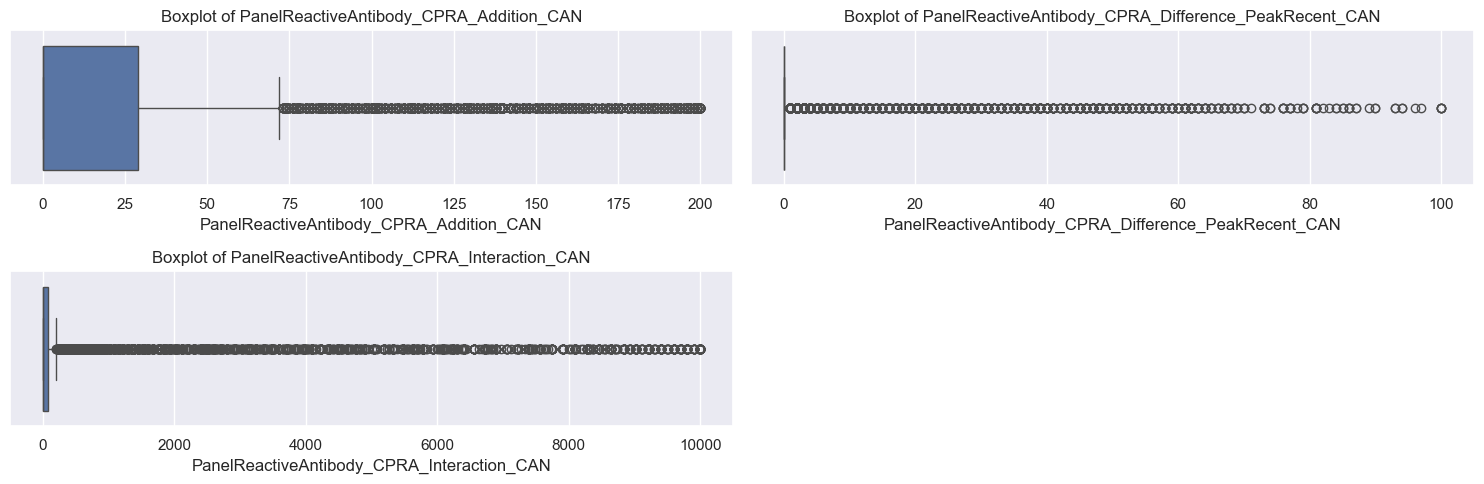

In [34]:
uv.plotBoxPlot(df, features, orientation='h')

#### Creatinine

In [35]:
# examine features
features = getFeatureList(df, 'Creatinine')

                               count      mean       std      min   25%     50%   75%       max
Creatinine_Addition_CAN       9850.0  2.785284  1.907786   0.3500  1.98  2.4000  3.00   45.5600
Creatinine_Difference_RT_CAN  9850.0  0.007662  0.735648 -22.3000 -0.18  0.0000  0.18   18.9600
Creatinine_Interaction_CAN    9850.0  2.713977  9.738804   0.0294  0.96  1.4374  2.21  510.5184

:::: NaN Count:
Creatinine_Addition_CAN         0
Creatinine_Difference_RT_CAN    0
Creatinine_Interaction_CAN      0


In [36]:
df[features].corr()

,Creatinine_Addition_CAN,Creatinine_Difference_RT_CAN,Creatinine_Interaction_CAN
Creatinine_Addition_CAN,1.000000,0.025477,0.846276
Creatinine_Difference_RT_CAN,0.025477,1.000000,0.000433
Creatinine_Interaction_CAN,0.846276,0.000433,1.000000


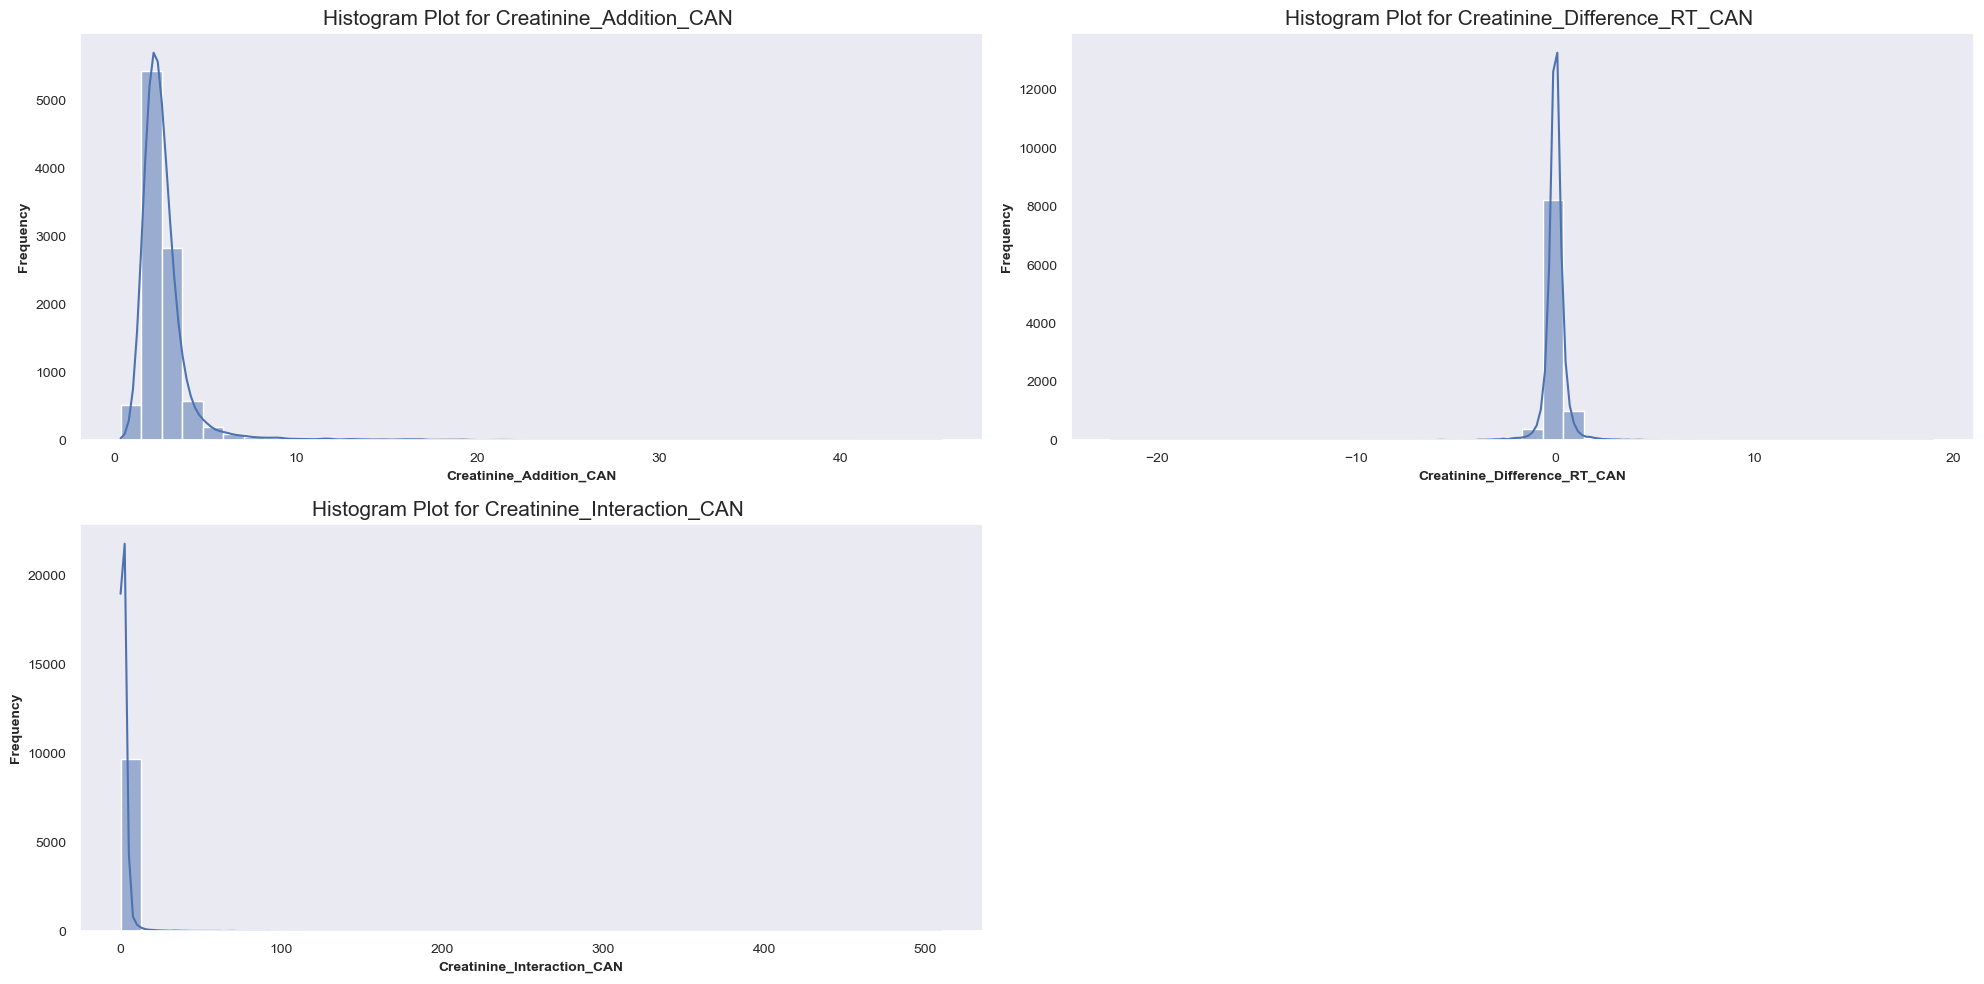

In [37]:
# plots
uv.histogramPlot(df, features, bins=40)

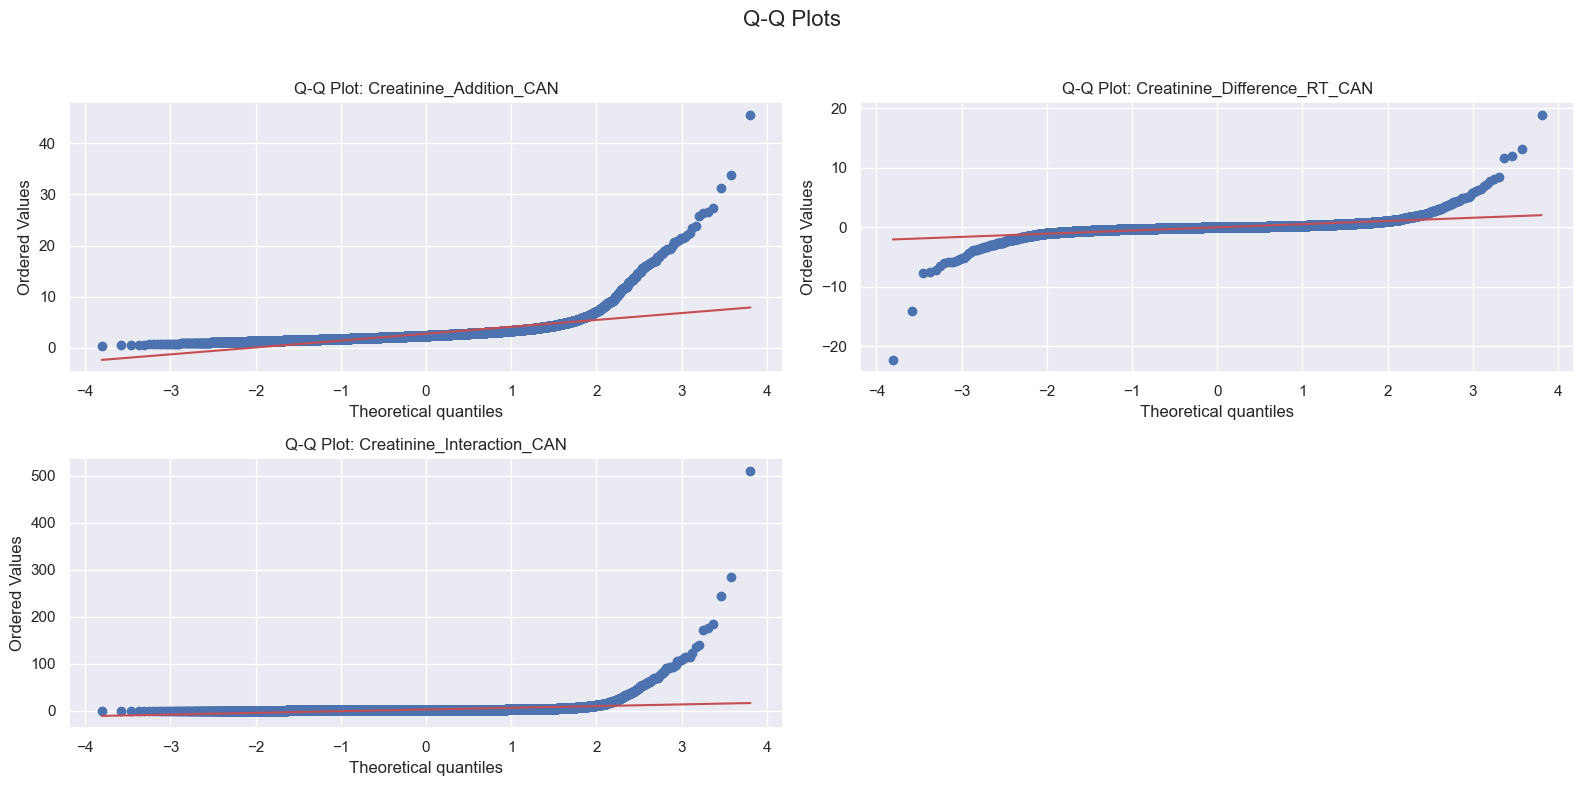

In [38]:
uv.plotQQ(df,features)

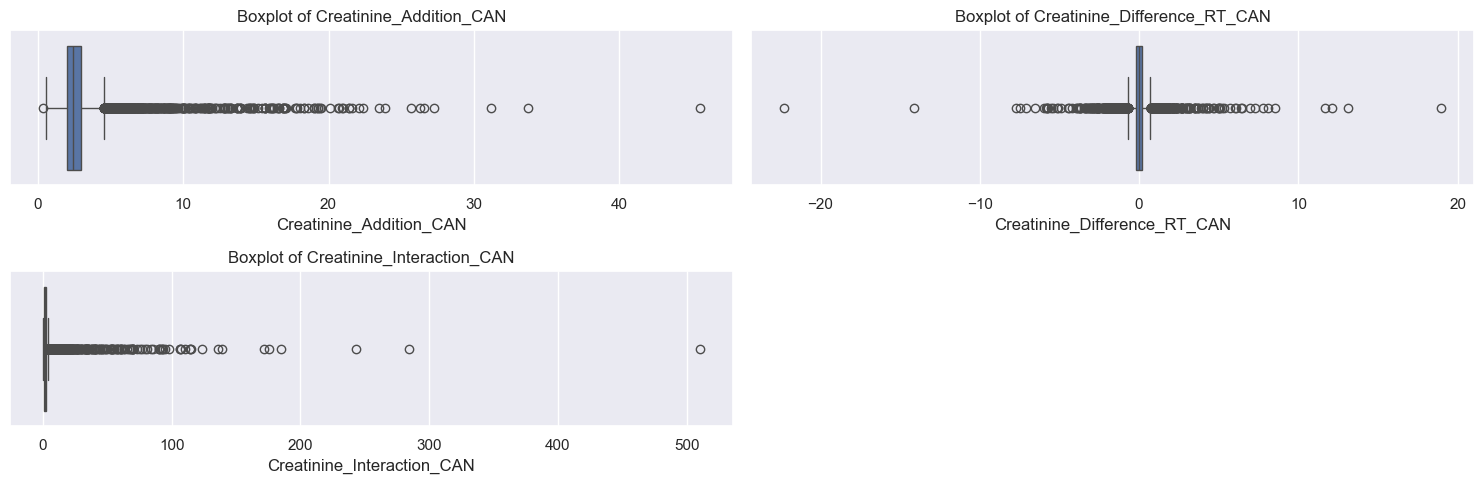

In [39]:
uv.plotBoxPlot(df, features, orientation='h')

#### HeightCm

In [40]:
# examine features
features = getFeatureList(df, 'HeightCm')

                             count        mean        std    min    25%    50%    75%    max
HeightCm_Addition           9850.0  347.419472  17.073923  284.0  335.3  348.3  360.3  404.1
HeightCm_Difference_CanDon  9850.0   -0.226457   9.589461  -50.8   -6.4    0.0    6.3   41.0

:::: NaN Count:
HeightCm_Addition             0
HeightCm_Difference_CanDon    0


In [41]:
df[features].corr()

,HeightCm_Addition,HeightCm_Difference_CanDon
HeightCm_Addition,1.000000,0.061141
HeightCm_Difference_CanDon,0.061141,1.000000


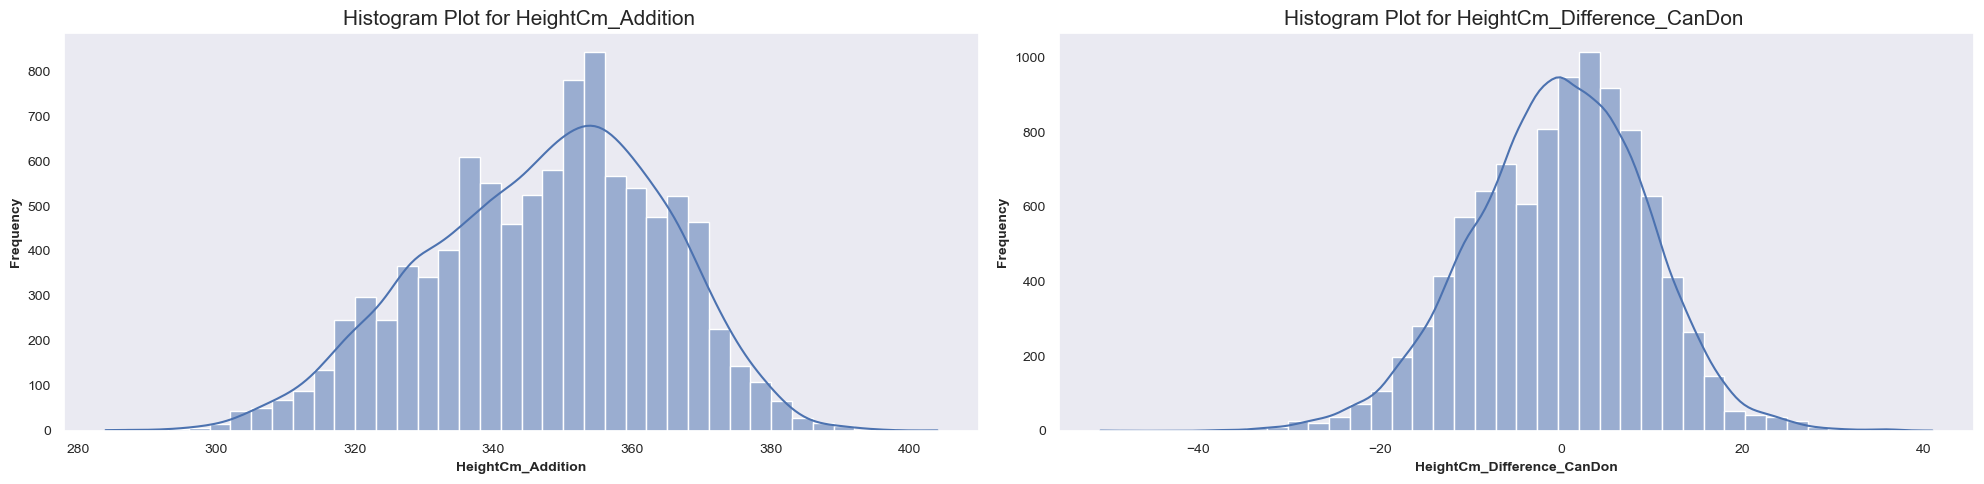

In [42]:
# plots
uv.histogramPlot(df, features, bins=40)

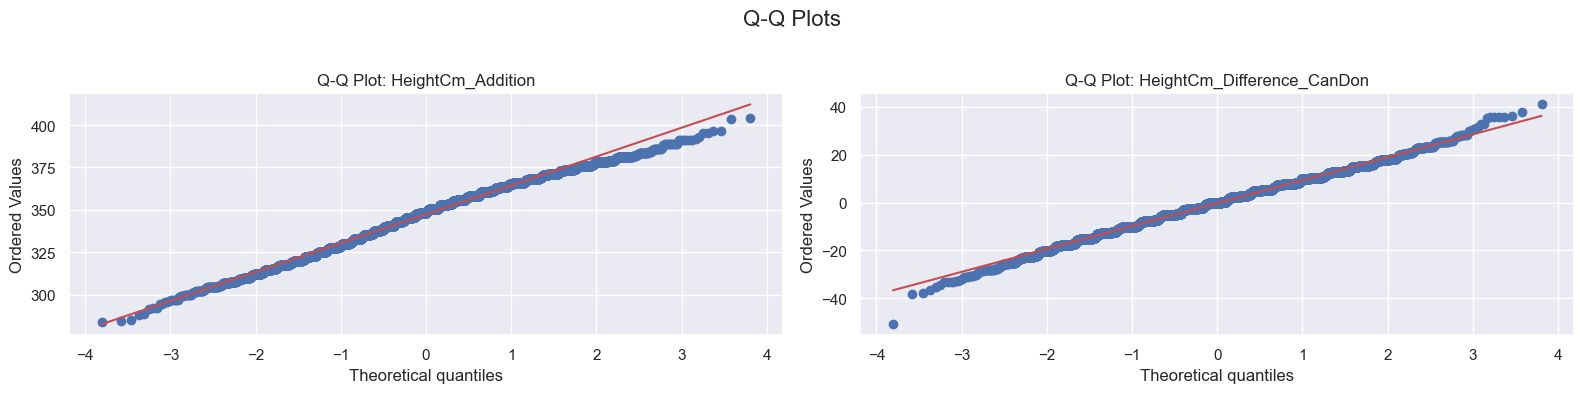

In [43]:
uv.plotQQ(df,features)

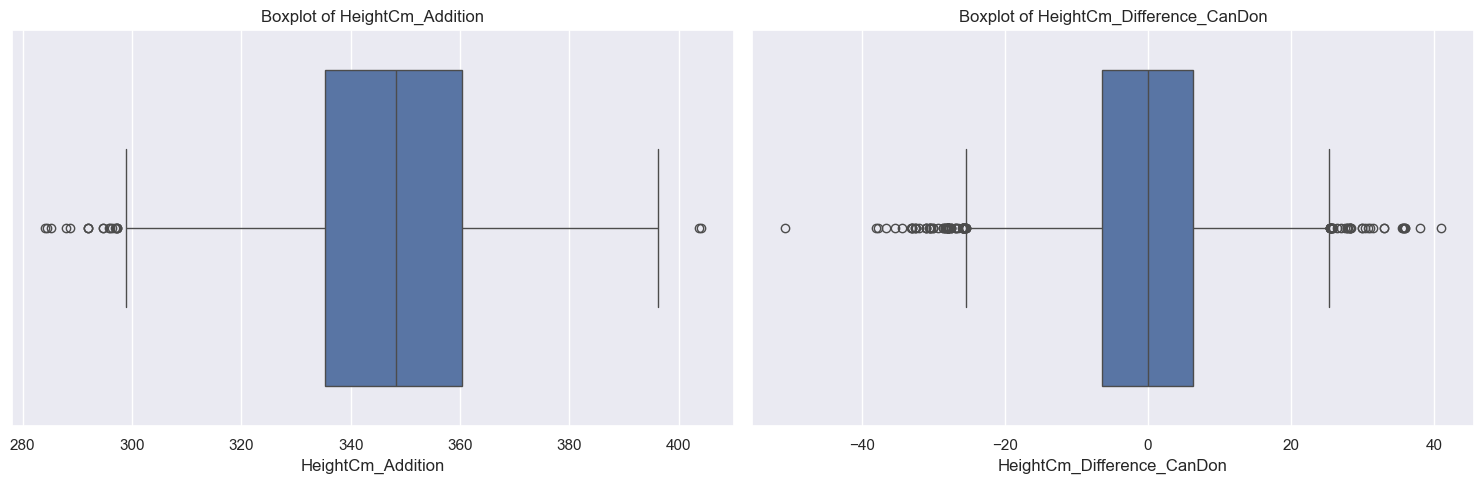

In [44]:
uv.plotBoxPlot(df, features, orientation='h')

#### Hemodynamics

In [45]:
# examine features
features = getFeatureList(df, 'Hemodynamics')

                                           count           mean           std           min           25%           50%           75%           max
HemodynamicsRegistration_Addition_CAN     9850.0     107.752747  3.922202e+01  1.600000e+01  7.800000e+01  1.050000e+02  1.350000e+02  2.800000e+02
HemodynamicsRegistration_CO_CAN           9850.0       4.220457  1.295280e+00  4.500000e-01  3.300000e+00  4.100000e+00  4.950000e+00  1.353000e+01
HemodynamicsRegistration_Interaction_CAN  9850.0  819125.483511  1.189964e+06  5.000065e-04  1.014423e+05  3.837246e+05  1.071714e+06  2.131921e+07
HemodynamicsTransplant_Addition_CAN       9850.0     102.979932  3.799864e+01  1.600000e+01  7.400000e+01  9.900000e+01  1.290000e+02  2.660000e+02
HemodynamicsTransplant_CO_CAN             9850.0       4.453218  1.403848e+00  2.000000e-01  3.500000e+00  4.300000e+00  5.210000e+00  1.500000e+01
HemodynamicsTransplant_Interaction_CAN    9850.0  699940.193059  1.066242e+06  5.000065e-04  8.064021e+04  2.948

In [46]:
df[features].corr()

,HemodynamicsRegistration_Addition_CAN,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_Interaction_CAN,HemodynamicsTransplant_Addition_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_Interaction_CAN,Hemodynamics_Addition_Difference_CAN,Hemodynamics_Difference_CO_RT_CAN,Hemodynamics_Difference_PA_DIA_RT_CAN,Hemodynamics_Difference_PA_MN_RT_CAN,Hemodynamics_Difference_PCW_RT_CAN,Hemodynamics_Difference_SYS_RT_CAN,Hemodynamics_Interaction_Difference_CAN
HemodynamicsRegistration_Addition_CAN,1.000000,-0.210887,0.834626,0.639246,-0.079641,0.515329,0.493658,-0.125708,0.413796,0.435832,0.546709,0.424933,0.266809
HemodynamicsRegistration_CO_CAN,-0.210887,1.000000,-0.188909,-0.126329,0.550224,-0.109348,-0.098068,0.407345,-0.101932,-0.097580,-0.084557,-0.082007,-0.040289
HemodynamicsRegistration_Interaction_CAN,0.834626,-0.188909,1.000000,0.488505,-0.063711,0.533122,0.461257,-0.120953,0.403020,0.413020,0.489663,0.398452,0.405208
HemodynamicsTransplant_Addition_CAN,0.639246,-0.126329,0.488505,1.000000,-0.193243,0.834447,-0.343771,0.083871,-0.349480,-0.378318,-0.163152,-0.369349,-0.094751
HemodynamicsTransplant_CO_CAN,-0.079641,0.550224,-0.063711,-0.193243,1.000000,-0.192790,0.128723,-0.538469,0.124851,0.117806,0.126310,0.109222,0.042931
HemodynamicsTransplant_Interaction_CAN,0.515329,-0.109348,0.533122,0.834447,-0.192790,1.000000,-0.310632,0.100511,-0.320264,-0.335312,-0.171827,-0.316678,-0.024552
Hemodynamics_Addition_Difference_CAN,0.493658,-0.098068,0.461257,-0.343771,0.128723,-0.310632,1.000000,-0.239750,0.888132,0.965259,0.893084,0.933611,0.443205
Hemodynamics_Difference_CO_RT_CAN,-0.125708,0.407345,-0.120953,0.083871,-0.538469,0.100511,-0.239750,1.000000,-0.239415,-0.227318,-0.223477,-0.202215,-0.087613
Hemodynamics_Difference_PA_DIA_RT_CAN,0.413796,-0.101932,0.403020,-0.349480,0.124851,-0.320264,0.888132,-0.239415,1.000000,0.844477,0.729470,0.749581,0.407624
Hemodynamics_Difference_PA_MN_RT_CAN,0.435832,-0.097580,0.413020,-0.378318,0.117806,-0.335312,0.965259,-0.227318,0.844477,1.000000,0.822928,0.889331,0.429300


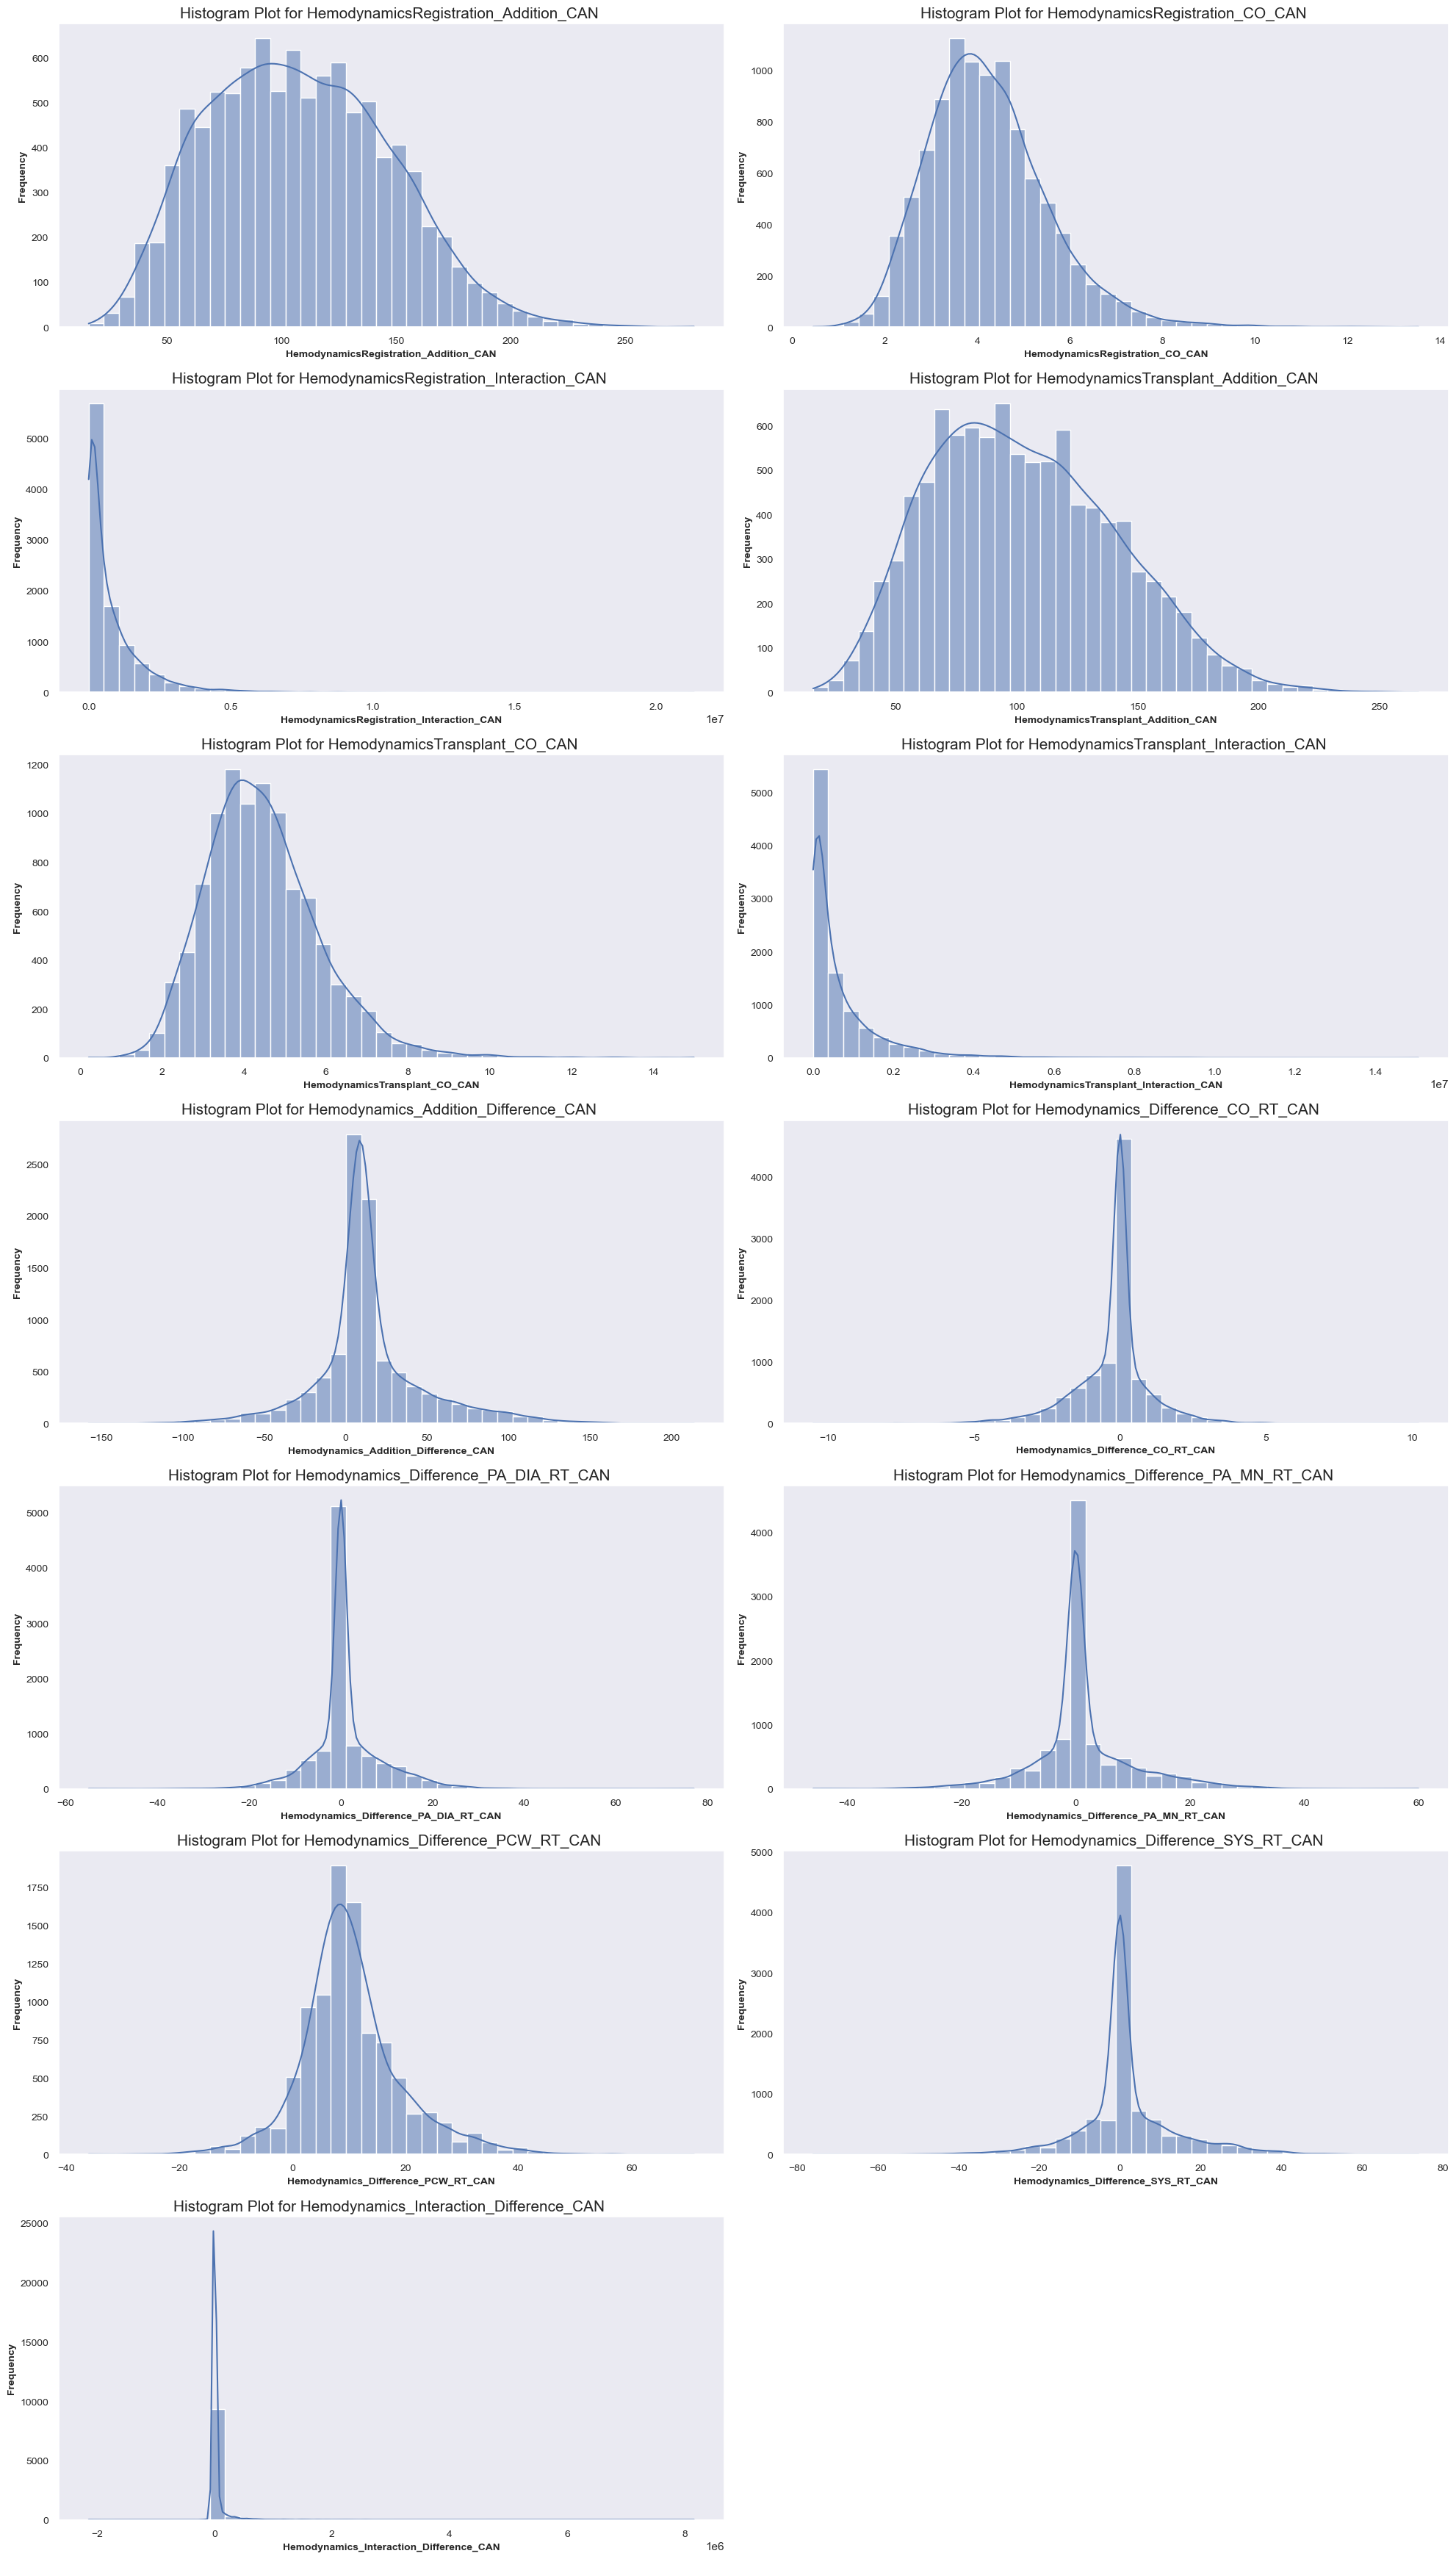

In [47]:
# plots
uv.histogramPlot(df, features, bins=40)

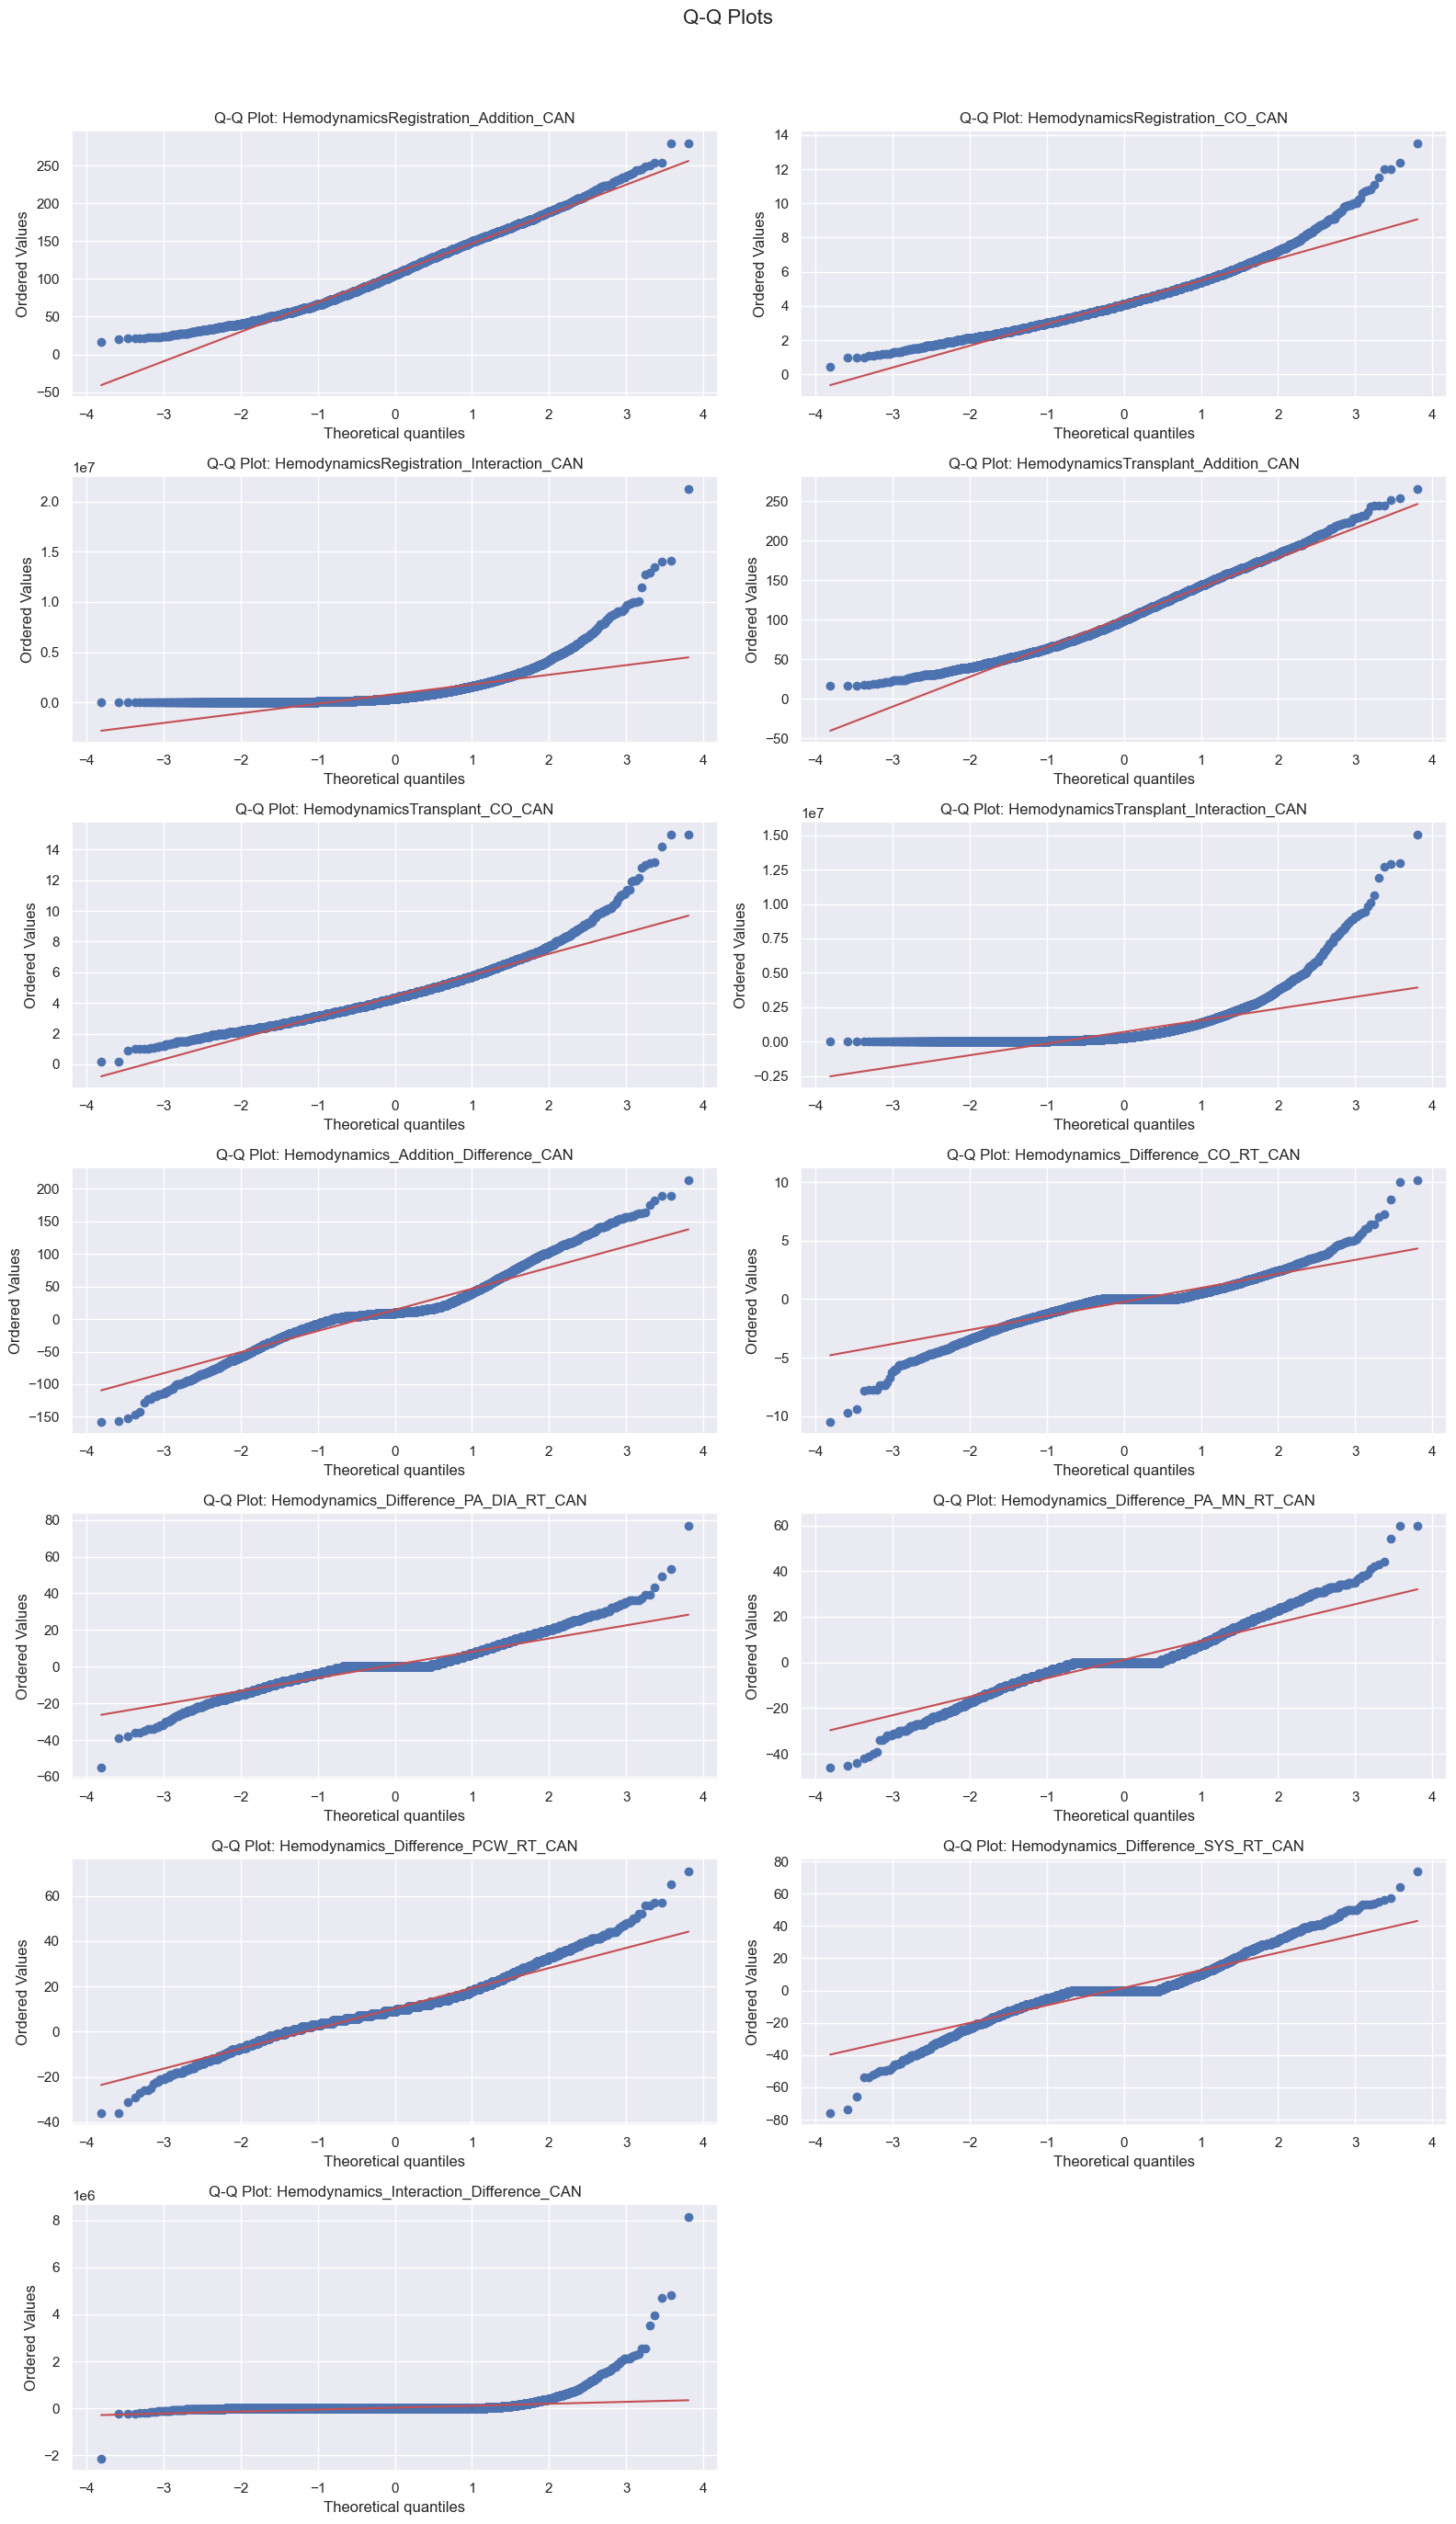

In [48]:
uv.plotQQ(df,features)

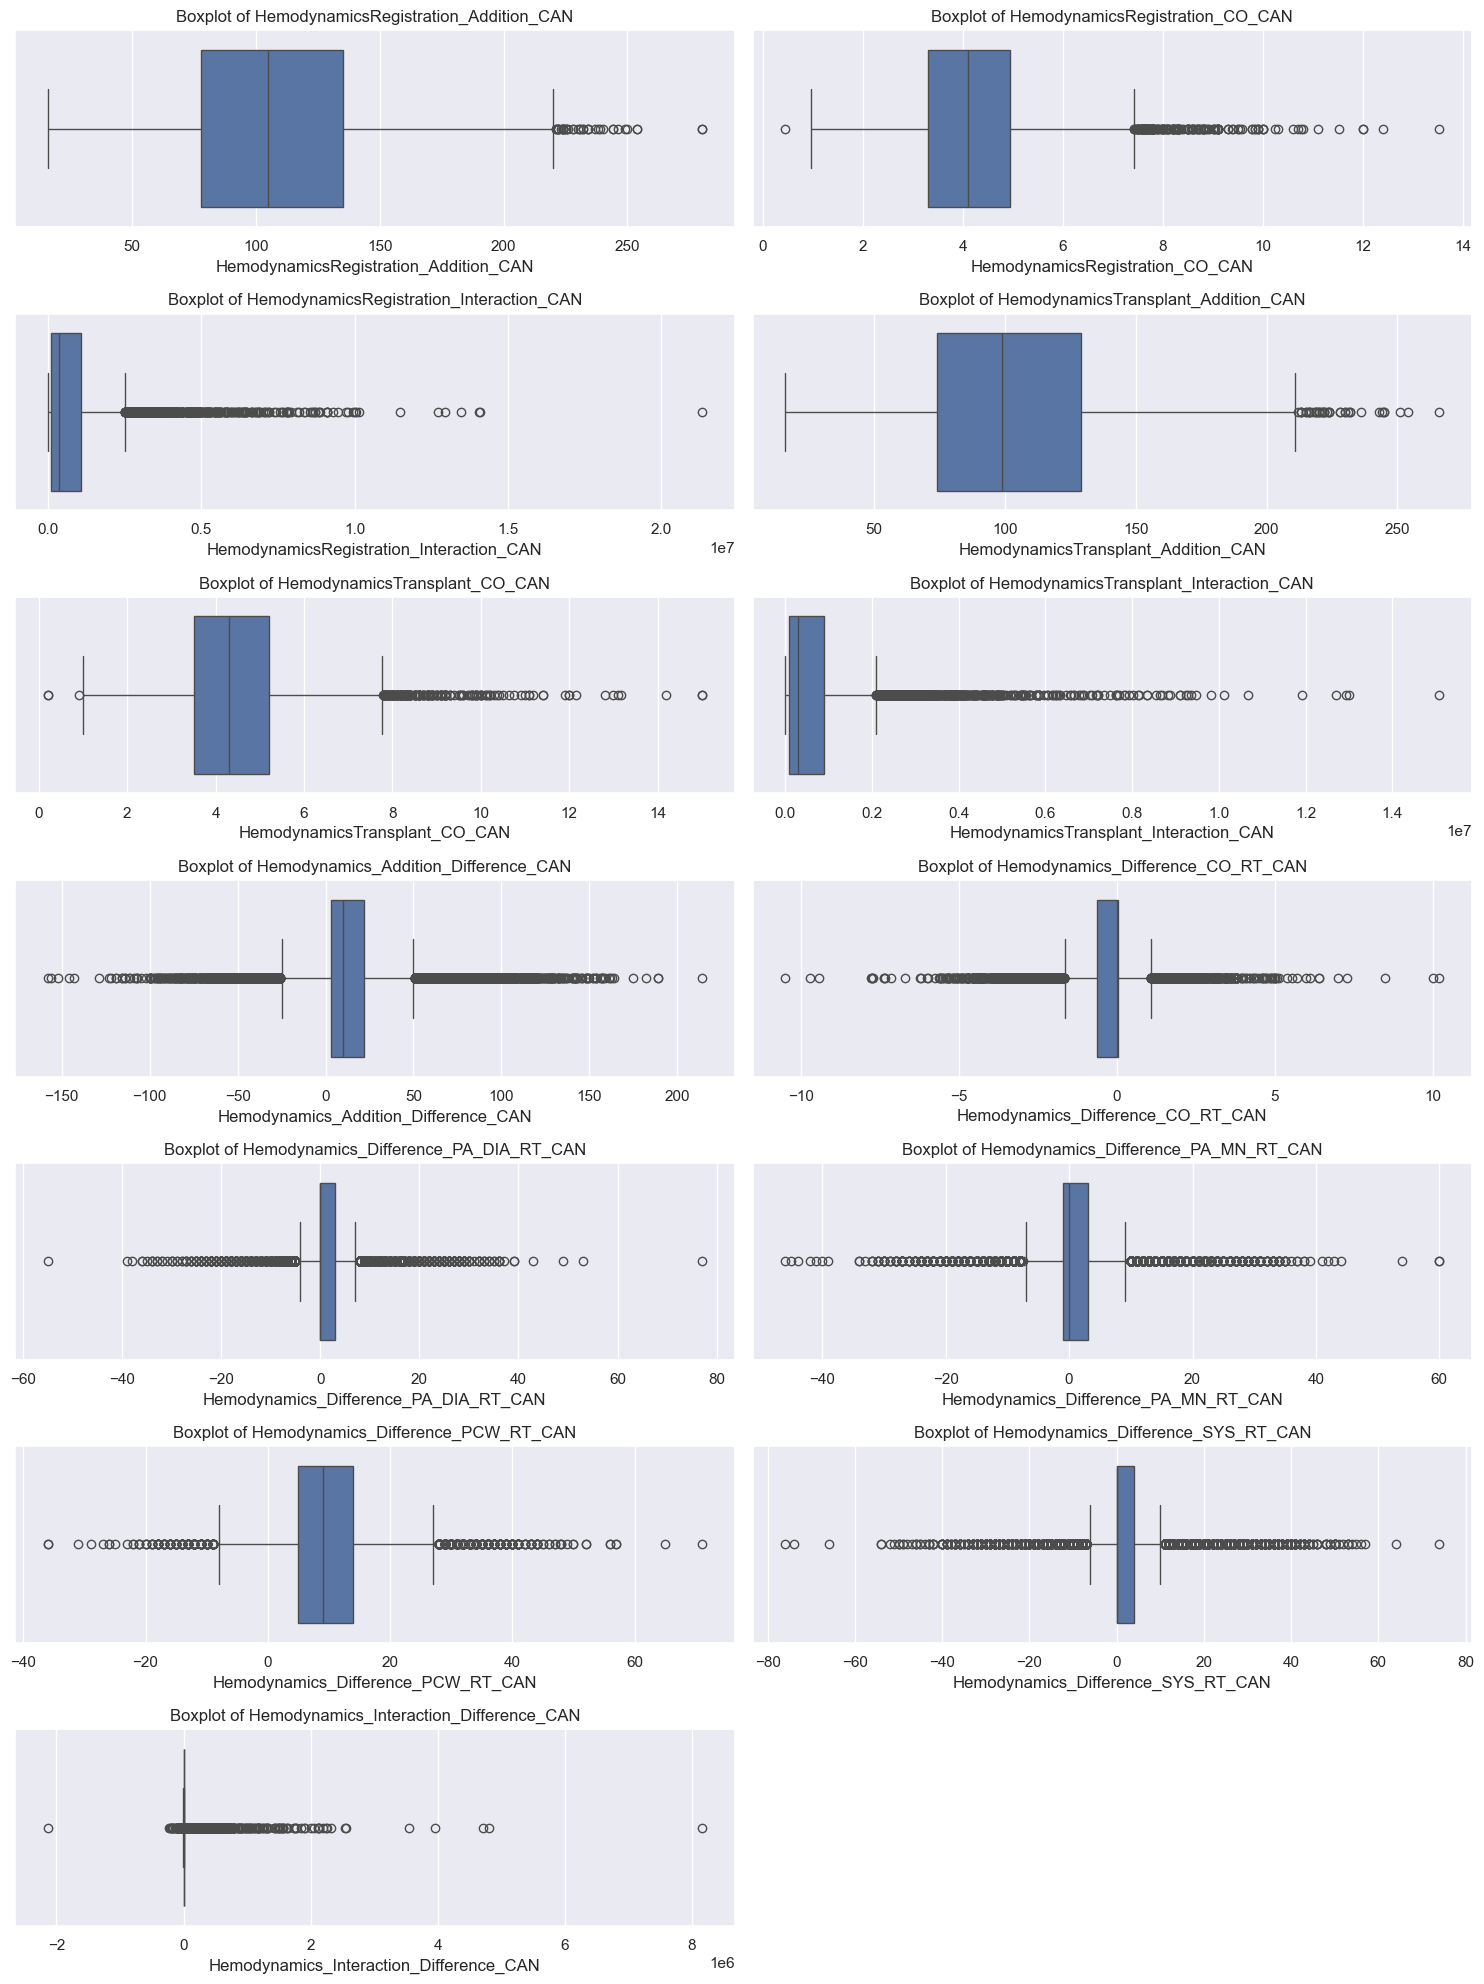

In [49]:
uv.plotBoxPlot(df, features, orientation='h', figsize=(15, 20))

#### SGOT

In [50]:
# examine features
features = getFeatureList(df, 'SGOT')

                                   count        mean         std     min   25%   50%    75%      max
Level_SGOT_Addition_DON           9850.0  224.557807  726.265872     9.0  54.0  94.0  183.0  44267.0
Level_SGOT_Difference_AltAst_DON  9850.0   20.925442  504.639591 -7648.0 -20.0  -1.0   22.0  43967.0

:::: NaN Count:
Level_SGOT_Addition_DON             0
Level_SGOT_Difference_AltAst_DON    0


In [51]:
df[features].corr()

,Level_SGOT_Addition_DON,Level_SGOT_Difference_AltAst_DON
Level_SGOT_Addition_DON,1.000000,0.546292
Level_SGOT_Difference_AltAst_DON,0.546292,1.000000


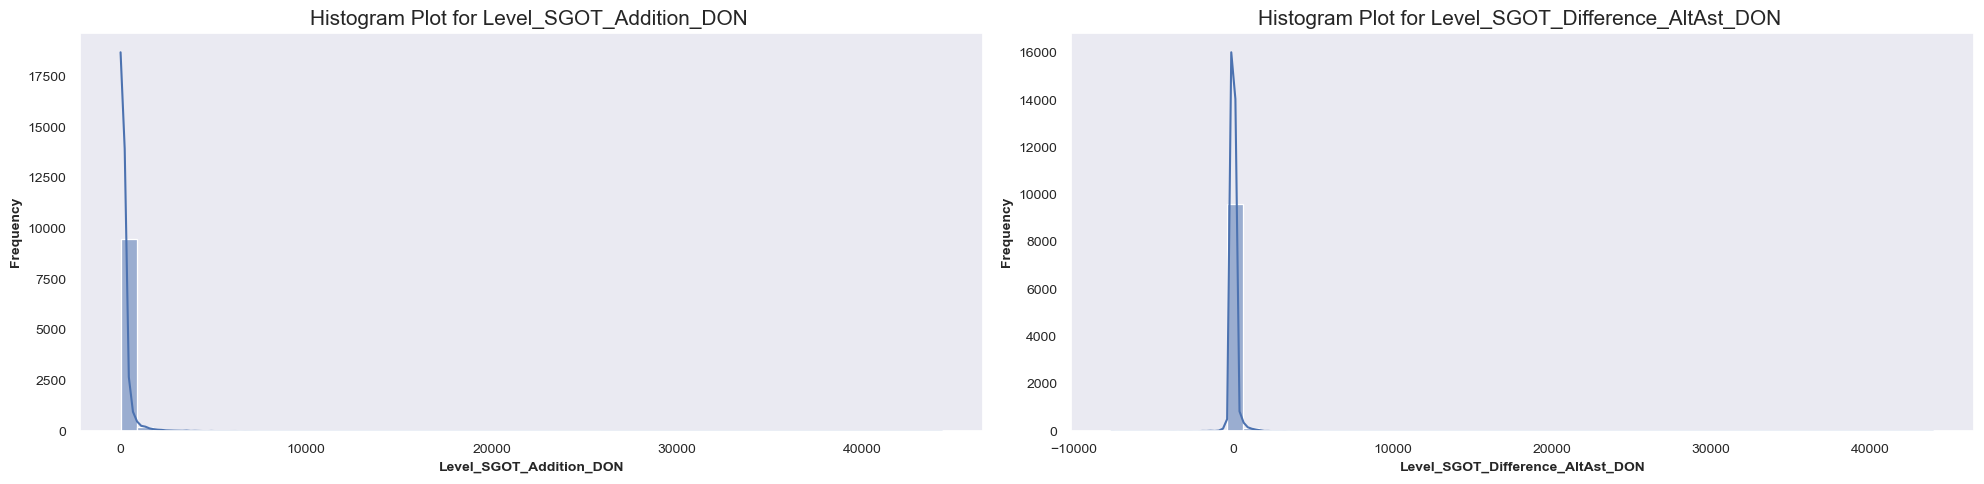

In [52]:
# plots
uv.histogramPlot(df, features, bins=50)

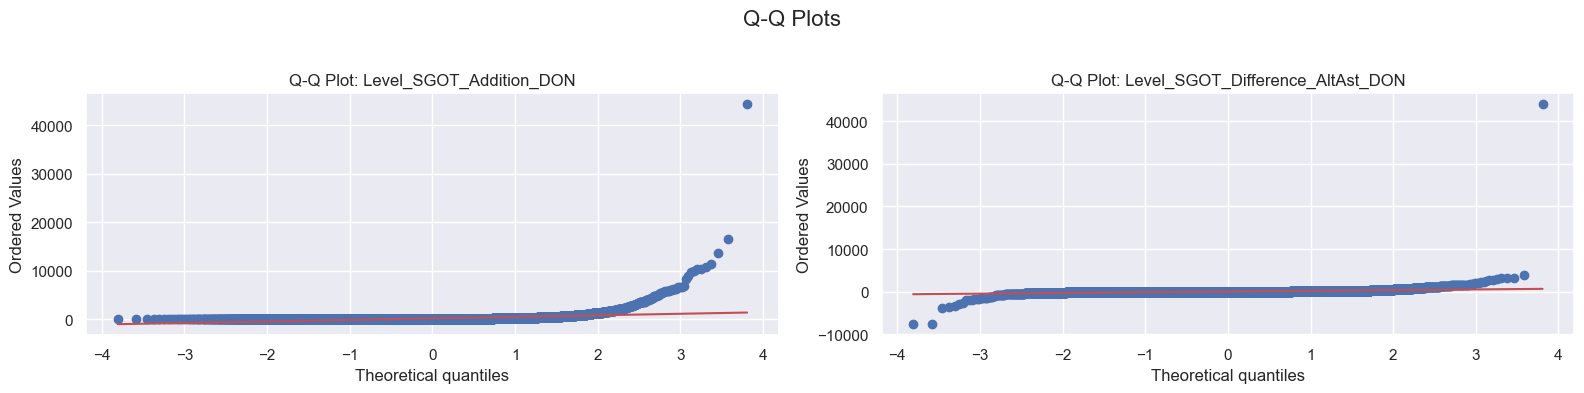

In [53]:
uv.plotQQ(df,features)

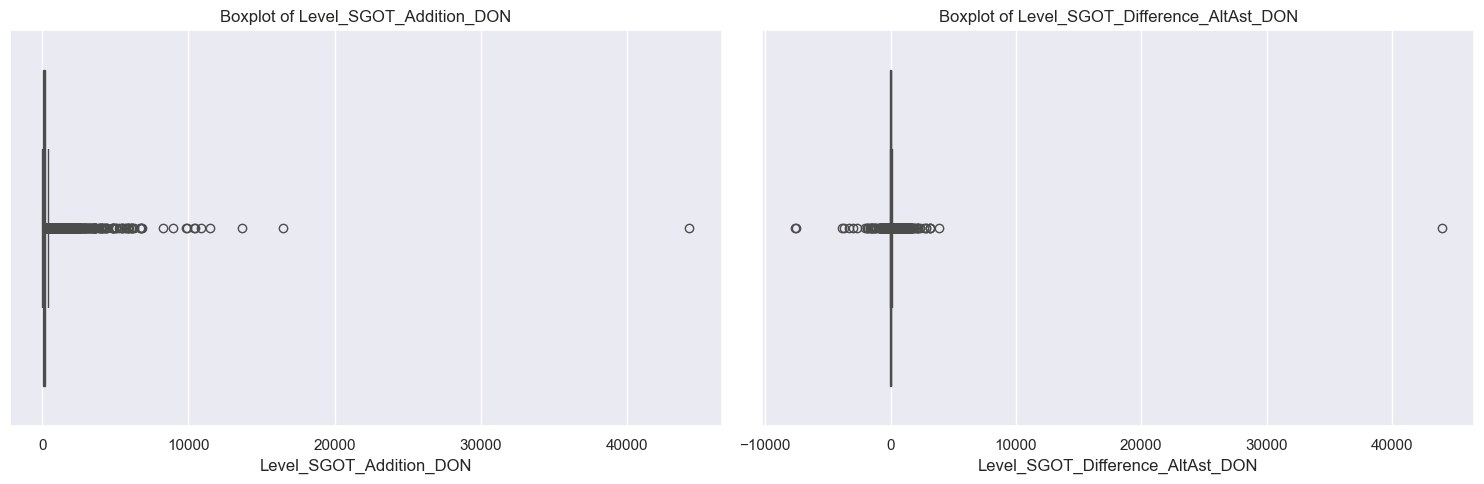

In [54]:
uv.plotBoxPlot(df, features, orientation='h')

#### TotalBilirubin

In [55]:
# examine features
features = getFeatureList(df, 'TotalBilirubin')

                                   count      mean       std   min  25%  50%  75%   max
TotalBilirubin_Addition           9850.0  2.008749  2.483715   0.3  1.1  1.5  2.2  80.3
TotalBilirubin_Difference_CanDon  9850.0 -0.078146  2.482001 -44.7 -0.5  0.0  0.4  79.7

:::: NaN Count:
TotalBilirubin_Addition             0
TotalBilirubin_Difference_CanDon    0


In [56]:
df[features].corr()

,TotalBilirubin_Addition,TotalBilirubin_Difference_CanDon
TotalBilirubin_Addition,1.000000,0.199515
TotalBilirubin_Difference_CanDon,0.199515,1.000000


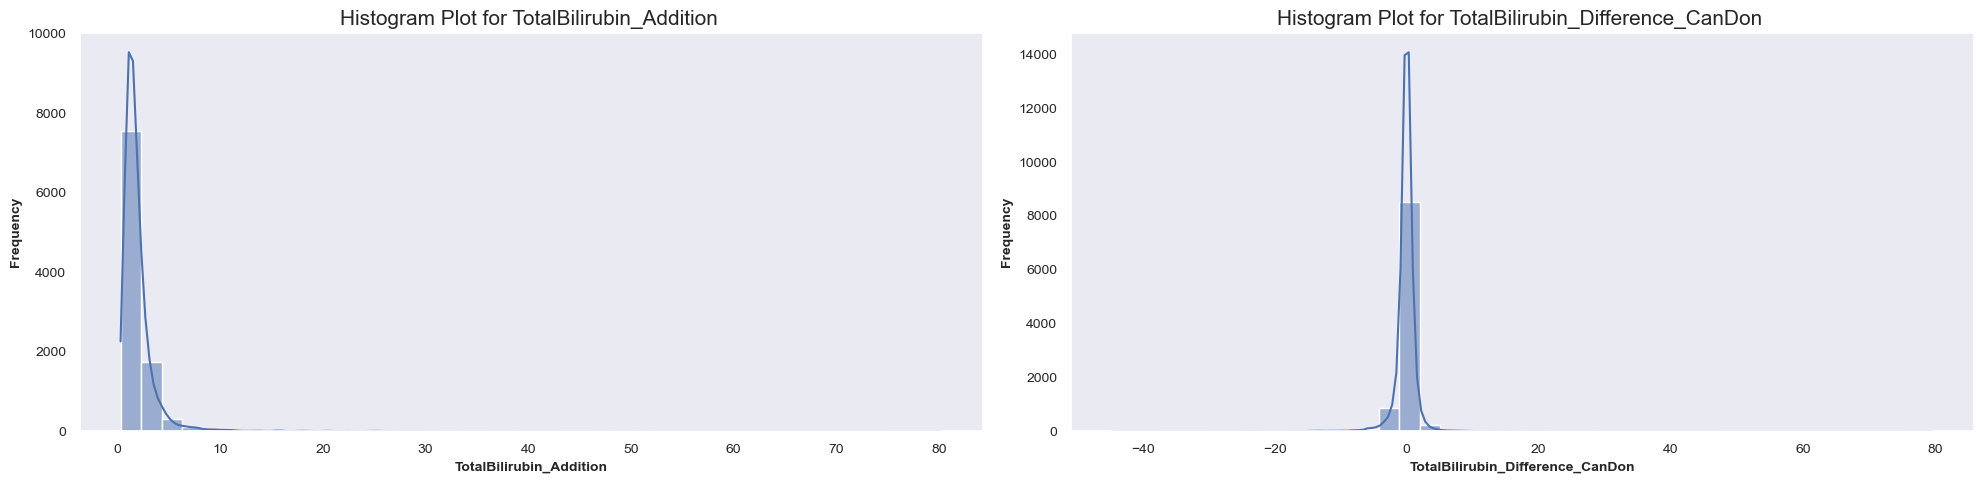

In [57]:
# plots
uv.histogramPlot(df, features, bins=40)

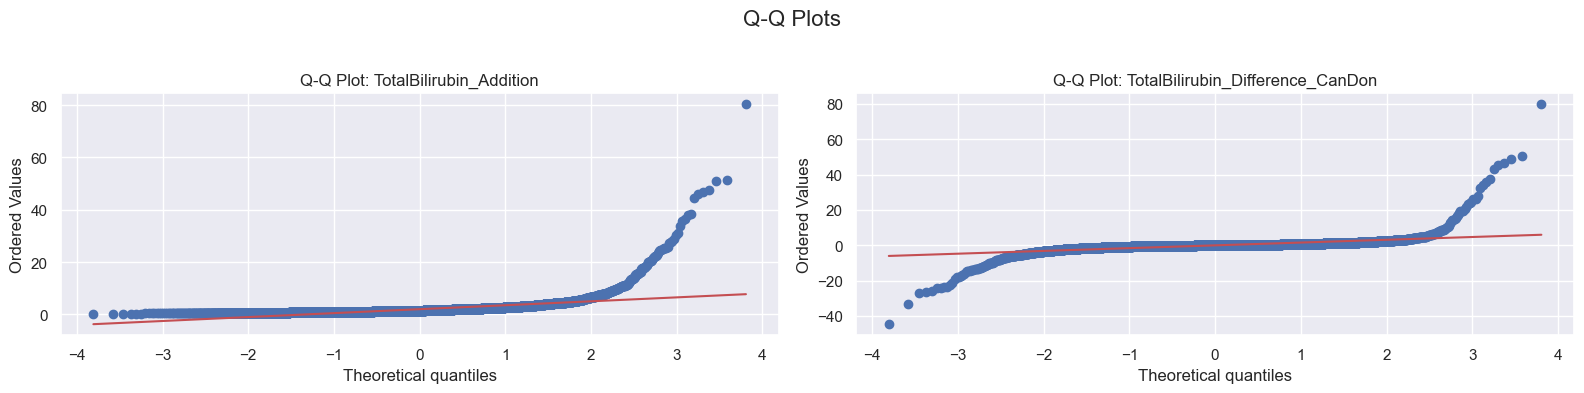

In [58]:
uv.plotQQ(df,features)

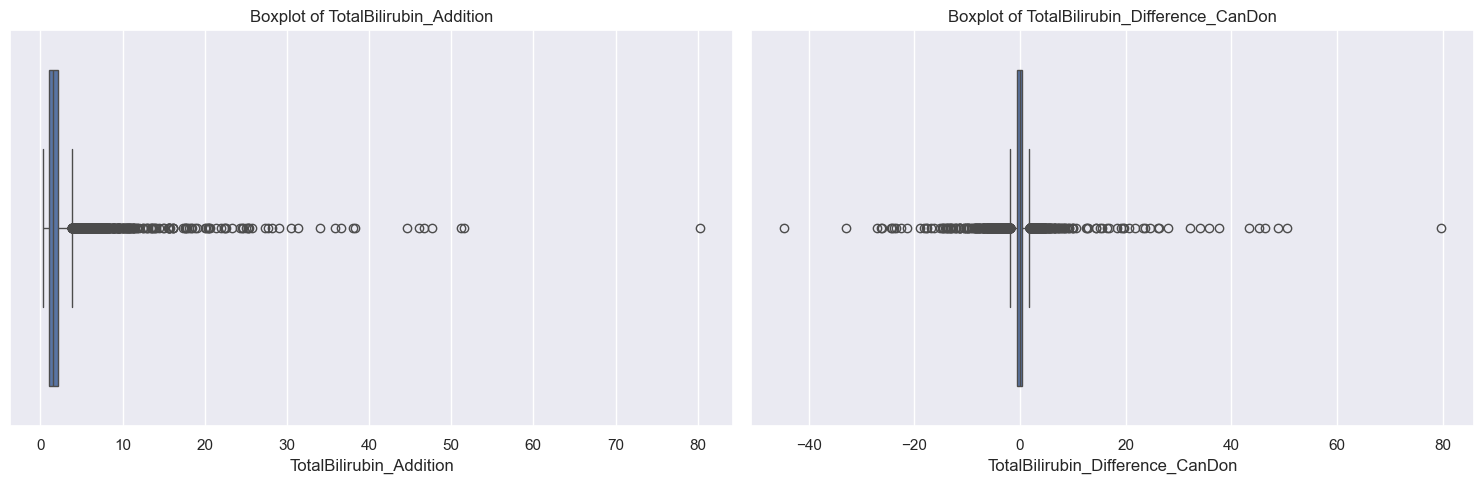

In [59]:
uv.plotBoxPlot(df, features, orientation='h')

#### WeightKg

In [60]:
# examine features
features = getFeatureList(df, 'WeightKg')

                             count        mean        std    min    25%     50%    75%    max
WeightKg_Addition           9850.0  167.675340  32.239209   80.9  144.9  165.15  187.9  323.1
WeightKg_Difference_CanDon  9850.0   -0.012518  20.211393 -109.5  -11.6    1.60   13.3   86.5

:::: NaN Count:
WeightKg_Addition             0
WeightKg_Difference_CanDon    0


In [61]:
df[features].corr()

,WeightKg_Addition,WeightKg_Difference_CanDon
WeightKg_Addition,1.000000,-0.098953
WeightKg_Difference_CanDon,-0.098953,1.000000


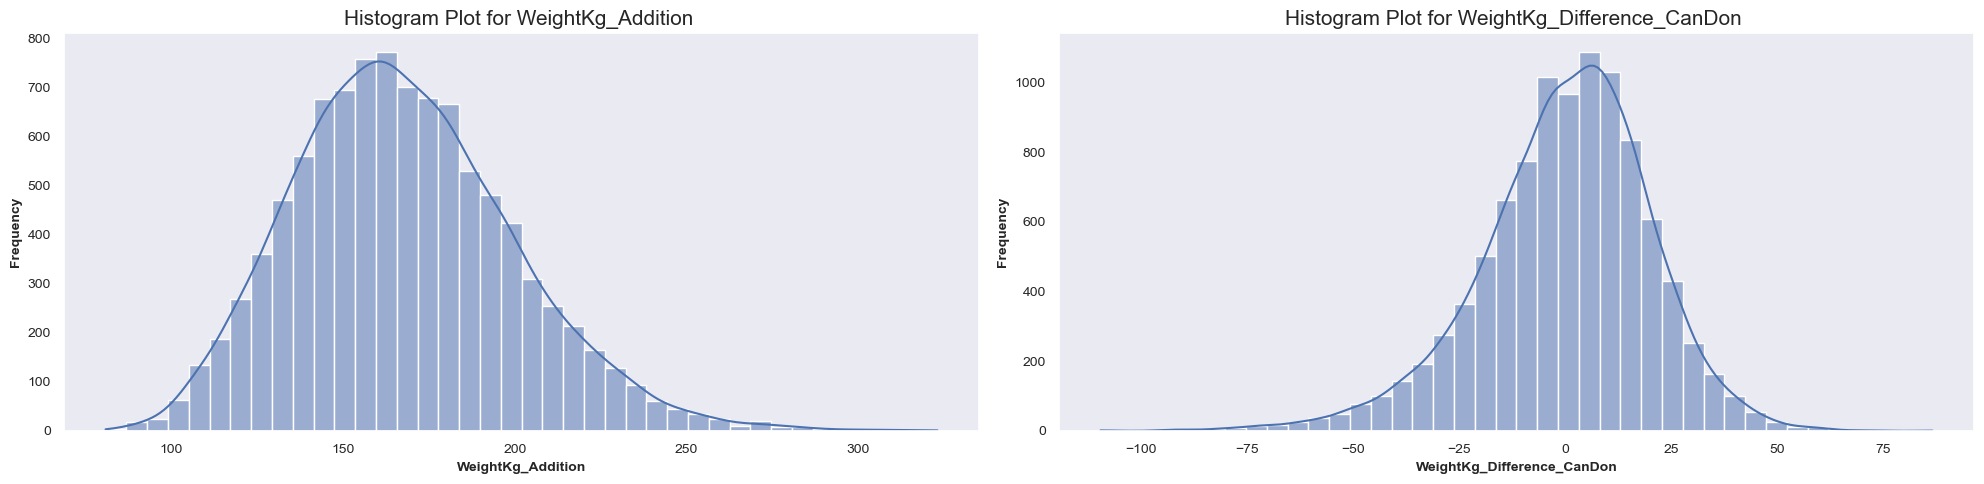

In [62]:
# plots
uv.histogramPlot(df, features, bins=40)

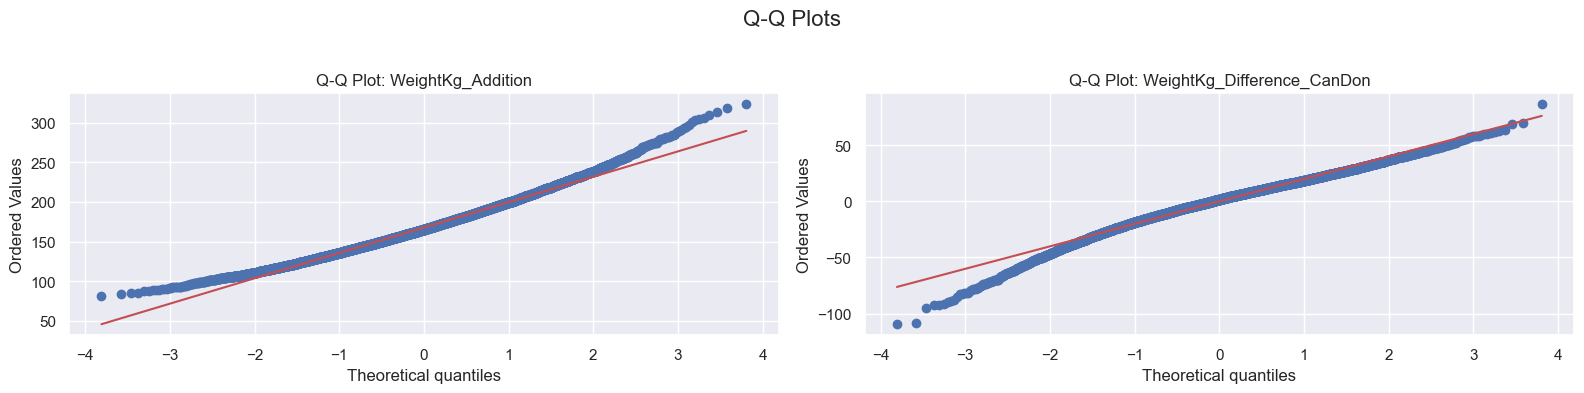

In [63]:
uv.plotQQ(df,features)

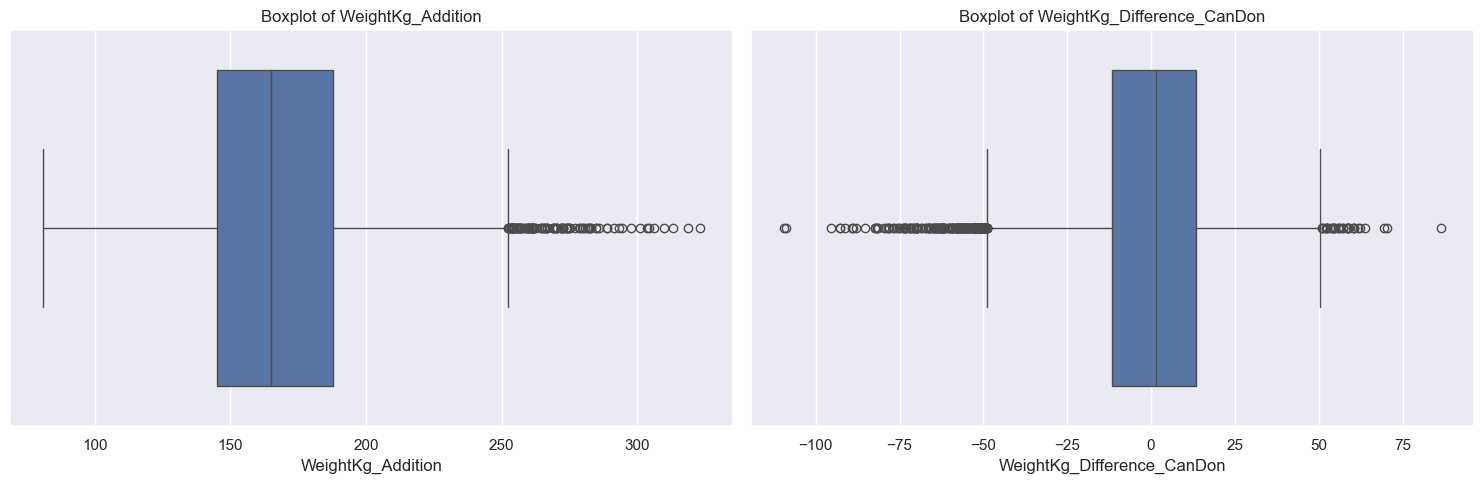

In [64]:
uv.plotBoxPlot(df, features, orientation='h')

#### Variance Check

In [65]:
df[df_numeric.column.to_list()].var().T

BloodUreaNitrogenLevel_DON                              4.567045e+02
HemodynamicsRegistration_CO_CAN                         1.677751e+00
HemodynamicsTransplant_CO_CAN                           1.970790e+00
TotalDayWaitList_CAN                                    5.135954e+04
OrganRecovery_PCO2_DON                                  4.840650e+01
DistanceFromDonorHospitaltoTXCenter                     5.197716e+04
Hematocrit_DON                                          2.401106e+01
IschemicTimeHour_DON                                    1.219004e+00
BloodPH_DON                                             4.629922e-03
LV_EjectionFractionPercent_DON                          4.351059e+01
LungPO2_DON                                             2.569913e+04
LungPO2_FIO2_DON                                        6.410089e+02
Age_Difference_CanDon                                   2.364306e+02
Age_Addition                                            3.083193e+02
BMI_Difference_CanDon             

#### Removed Unused Category

In [66]:
df = uf.removeCatZeroCount(df)

#### Examine Nominal

In [67]:
print(sorted(df[df_nominal.column.to_list()]))

['AllocationType_DON', 'AntiHypertensive_DON', 'AntibodyResultHBSAB_DON', 'AntibodyResultRPR_VDRL_DON', 'Antibody_HEP_C_DON', 'AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDA2_DON', 'AntigenDB1_DON', 'AntigenDB2_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR2_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'ArginnieManagement_DON', 'Biopsy_DON', 'BloodGroupMatchLevel', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BronchoscopyLeft_DON', 'BronchoscopyRight_DON', 'CMVStatus_Transplant_CAN', 'CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN', 'CancerExtraCranial_DON', 'CancerHistory_DON', 'CancerIntraCranial_DON', 'CancerSkin_DON', 'CardiacArrest_DON', 'CauseOfDeath_DON', 'CerebroVascularDisease_CAN', 'ChestXray_

##### AllocationType_DON

In [68]:
# examine features
features = getFeatureList(df, 'AllocationType_DON')

                   count unique    top  freq
AllocationType_DON  9850      3  Local  4202

:::: NaN Count:
AllocationType_DON    0


In [69]:
uf.categoryContingencySurvival(df, 'AllocationType_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Local,1217.0,2985.0,4202.0,28.962399,71.037601
National,2020.0,1547.0,3567.0,56.630221,43.369779
Regional,1199.0,882.0,2081.0,57.616531,42.383469
Column Total,4436.0,5414.0,9850.0,45.035533,54.964467


##### AntiHypertensive_DON

In [70]:
# examine features
features = getFeatureList(df, 'AntiHypertensive_DON')

                     count unique top  freq
AntiHypertensive_DON  9850      2  No  6393

:::: NaN Count:
AntiHypertensive_DON    0


In [71]:
uf.categoryContingencySurvival(df, 'AntiHypertensive_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,2870.0,3523.0,6393.0,44.892852,55.107148
Yes,1566.0,1891.0,3457.0,45.299393,54.700607
Column Total,4436.0,5414.0,9850.0,45.035533,54.964467


##### AntibodyResult
- HBSAB (Hepatitis B Surface Antibody) and RPR/VDRL (Rapid Plasma Reagin/Venereal Disease Research Laboratory), are used to detect different infections.
    - HBSAB (Hepatitis B Surface Antibody):
        - Purpose: This test detects antibodies against the hepatitis B virus (HBV). A positive result indicates immunity to hepatitis B, either from vaccination or recovery from a past infection.
        - Use: It helps determine if a person is protected against hepatitis B.
    - RPR/VDRL (Rapid Plasma Reagin/Venereal Disease Research Laboratory):

        - Purpose: These are non-treponemal tests used to screen for syphilis, a sexually transmitted infection caused by the bacterium Treponema pallidum2.
        - Use: They detect antibodies produced in response to the infection. Positive results typically require confirmation with a treponemal test to diagnose syphilis accurately2. 

In [72]:
# examine features
features = getFeatureList(df, 'AntibodyResult')

                           count unique       top  freq
AntibodyResultHBSAB_DON     9850      5  Not Done  8614
AntibodyResultRPR_VDRL_DON  9850      3  Negative  9758

:::: NaN Count:
AntibodyResultHBSAB_DON       0
AntibodyResultRPR_VDRL_DON    0


In [73]:
uf.categoryContingencySurvival(df, 'AntibodyResultHBSAB_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Indeterminate,4.0,17.0,21.0,19.047619,80.952381
Negative,238.0,490.0,728.0,32.692308,67.307692
Not Done,4005.0,4609.0,8614.0,46.494079,53.505921
Positive,188.0,295.0,483.0,38.923395,61.076605
Unknown,1.0,3.0,4.0,25.000000,75.000000
Column Total,4436.0,5414.0,9850.0,45.035533,54.964467


In [74]:
uf.categoryContingencySurvival(df, 'AntibodyResultRPR_VDRL_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4390.0,5368.0,9758.0,44.988727,55.011273
Not Done,2.0,1.0,3.0,66.666667,33.333333
Positive,44.0,45.0,89.0,49.438202,50.561798
Column Total,4436.0,5414.0,9850.0,45.035533,54.964467


In [75]:
def reMapCat(value):
    if value in ['Indeterminate','Not Done', 'Missing']:
        return 'Unknown'
    else:
        return value

In [76]:
# consolidate category
df['AntibodyResultHBSAB_DON'] = df['AntibodyResultHBSAB_DON'].apply(reMapCat)
df['AntibodyResultRPR_VDRL_DON'] = df['AntibodyResultRPR_VDRL_DON'].apply(reMapCat)

In [77]:
uf.categoryContingencySurvival(df, 'AntibodyResultHBSAB_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,238.0,490.0,728.0,32.692308,67.307692
Positive,188.0,295.0,483.0,38.923395,61.076605
Unknown,4010.0,4629.0,8639.0,46.417409,53.582591
Column Total,4436.0,5414.0,9850.0,45.035533,54.964467


In [78]:
uf.categoryContingencySurvival(df, 'AntibodyResultRPR_VDRL_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4390.0,5368.0,9758.0,44.988727,55.011273
Unknown,2.0,1.0,3.0,66.666667,33.333333
Positive,44.0,45.0,89.0,49.438202,50.561798
Column Total,4436.0,5414.0,9850.0,45.035533,54.964467


The p-value is greater than the significance level (0.05), we fail to reject the null hypothesis, indicating no significant association between the variables. A Cramér's V value close to 0 suggests no association between the variables.

In [79]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,AntibodyResultHBSAB_DON,AntibodyResultRPR_VDRL_DON,1.58477,0.811527,0.008969


##### Antibody_HEP_C_DON
- The Antibody_HEP_C_DON test is used to detect antibodies against the hepatitis C virus (HCV). This test is often referred to as the HCV antibody test or anti-HCV test.

In [80]:
# examine features
features = getFeatureList(df, 'Antibody_HEP_C_DON')

                   count unique       top  freq
Antibody_HEP_C_DON  9850      3  Negative  8979

:::: NaN Count:
Antibody_HEP_C_DON    0


In [81]:
uf.categoryContingencySurvival(df, 'Antibody_HEP_C_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,3942.0,5037.0,8979.0,43.902439,56.097561
Not Done,0.0,1.0,1.0,0.000000,100.000000
Positive,494.0,376.0,870.0,56.781609,43.218391
Column Total,4436.0,5414.0,9850.0,45.035533,54.964467


In [82]:
# remove Not Done	
idx = df[df.Antibody_HEP_C_DON == 'Not Done'].index

# remove the row
df = df.drop(index=idx).copy()

##### Hepatitis_B_CoreAntibody_CAN

In [83]:
# examine features
features = getFeatureList(df, 'Hepatitis_B_CoreAntibody')

                             count unique       top  freq
Hepatitis_B_CoreAntibody_CAN  9849      4  Negative  8990
Hepatitis_B_CoreAntibody_DON  9849      3  Negative  9600

:::: NaN Count:
Hepatitis_B_CoreAntibody_CAN    0
Hepatitis_B_CoreAntibody_DON    0


There is no statistically significant association between the candidate's Hepatitis B Core Antibody status and the donor's Hepatitis B Core Antibody status (p > 0.05). The strength of the association is extremely weak (Cramer's V < 0.1). 

In [84]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Hepatitis_B_CoreAntibody_CAN,Hepatitis_B_CoreAntibody_DON,4.942278,0.551238,0.01584


In [85]:
uf.categoryContingencySurvival(df, 'Hepatitis_B_CoreAntibody_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4053.0,4937.0,8990.0,45.083426,54.916574
Not Done,147.0,210.0,357.0,41.176471,58.823529
Positive,230.0,253.0,483.0,47.619048,52.380952
Unknown,6.0,13.0,19.0,31.578947,68.421053
Column Total,4436.0,5413.0,9849.0,45.040106,54.959894


In [86]:
uf.categoryContingencySurvival(df, 'Hepatitis_B_CoreAntibody_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4318.0,5282.0,9600.0,44.979167,55.020833
Not Done,3.0,2.0,5.0,60.000000,40.000000
Positive,115.0,129.0,244.0,47.131148,52.868852
Column Total,4436.0,5413.0,9849.0,45.040106,54.959894


In [87]:
# consolidate category
df['Hepatitis_B_CoreAntibody_CAN'] = df['Hepatitis_B_CoreAntibody_CAN'].apply(reMapCat)
df['Hepatitis_B_CoreAntibody_DON'] = df['Hepatitis_B_CoreAntibody_DON'].apply(reMapCat)

In [88]:
uf.categoryContingencySurvival(df, 'Hepatitis_B_CoreAntibody_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4053.0,4937.0,8990.0,45.083426,54.916574
Positive,230.0,253.0,483.0,47.619048,52.380952
Unknown,153.0,223.0,376.0,40.691489,59.308511
Column Total,4436.0,5413.0,9849.0,45.040106,54.959894


In [89]:
uf.categoryContingencySurvival(df, 'Hepatitis_B_CoreAntibody_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4318.0,5282.0,9600.0,44.979167,55.020833
Unknown,3.0,2.0,5.0,60.000000,40.000000
Positive,115.0,129.0,244.0,47.131148,52.868852
Column Total,4436.0,5413.0,9849.0,45.040106,54.959894


##### SurfaceHBVAntibodyTotalTransplant_CAN

In [90]:
# examine features
features = getFeatureList(df, 'SurfaceHBVAntibody')

                                      count unique       top  freq
SurfaceHBVAntibodyTotalTransplant_CAN  9849      5  Negative  6695

:::: NaN Count:
SurfaceHBVAntibodyTotalTransplant_CAN    0


In [91]:
uf.categoryContingencySurvival(df, 'SurfaceHBVAntibodyTotalTransplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Missing,115.0,184.0,299.0,38.461538,61.538462
Negative,2963.0,3732.0,6695.0,44.256908,55.743092
Not Done,95.0,249.0,344.0,27.616279,72.383721
Positive,1248.0,1205.0,2453.0,50.876478,49.123522
Unknown,15.0,43.0,58.0,25.862069,74.137931
Column Total,4436.0,5413.0,9849.0,45.040106,54.959894


In [92]:
# consolidate category
df['SurfaceHBVAntibodyTotalTransplant_CAN'] = df['SurfaceHBVAntibodyTotalTransplant_CAN'].apply(reMapCat)

In [93]:
uf.categoryContingencySurvival(df, 'SurfaceHBVAntibodyTotalTransplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,2963.0,3732.0,6695.0,44.256908,55.743092
Positive,1248.0,1205.0,2453.0,50.876478,49.123522
Unknown,225.0,476.0,701.0,32.097004,67.902996
Column Total,4436.0,5413.0,9849.0,45.040106,54.959894


##### Antigen
- In HLA nomenclature, the value before the colon (":") in an antigen designation represents the primary allele group. This group indicates a set of alleles that share similar sequences and characteristics. For example, in 68:02:
    - First Set of Digits (Primary Allele Group):
        - This indicates the primary allele group, which often corresponds to the serological antigen carried by an allotype. For example, in HLA-A*68:02, "68" is the primary allele group.
    - Second Set of Digits (Specific Allele or Subtype):
        - This specifies the exact variant within the primary allele group. For example, in HLA-A*68:02, "02" is the specific subtype of the HLA-A68 allele. This means it is the second variant identified within the HLA-A68 group.

In [94]:
# examine features
features = getFeatureList(df, '^Antigen.*_CAN')

                  count unique top  freq
AntigenBW4_CAN     9849      4   0  5976
AntigenBW6_CAN     9849      3   0  5812
AntigenC1_CAN      9849     36   0  5749
AntigenC2_CAN      9849     44   0  6071
AntigenDQ1_CAN     9849     24   0  5750
AntigenDQ2_CAN     9849     25   0  6178
AntigenDR51_2_CAN  9849      7   0  8806
AntigenDR51_CAN    9849      9   0  6275
AntigenDR52_2_CAN  9849     10   0  8779
AntigenDR52_CAN    9849     10   0  6014
AntigenDR53_2_CAN  9849      6   0  8813
AntigenDR53_CAN    9849      7   0  6143
AntigenRA1_CAN     9849     46   2  3291
AntigenRA2_CAN     9849     49  24   899
AntigenRB1_CAN     9849     87   7  1603
AntigenRB2_CAN     9849     92  44  1193
AntigenRDR1_CAN    9849     50   4  1799
AntigenRDR2_CAN    9849     54  15  1925

:::: NaN Count:
AntigenBW4_CAN       0
AntigenBW6_CAN       0
AntigenC1_CAN        0
AntigenC2_CAN        0
AntigenDQ1_CAN       0
AntigenDQ2_CAN       0
AntigenDR51_2_CAN    0
AntigenDR51_CAN      0
AntigenDR52_2_CAN   

In [95]:
# the HLA-C1 antigen value of 0 represent is negative and rest is positive
# define a function to categorize the results
def categorizeResult(value):
    if value == '0':
        return 'Negative'
    elif value in ['Missing','Not Done']:
        return 'Unknown'
    elif value in ['No second antigen detected','No antigen detected']:
        return 'Negative'
    else:
        return 'Positive'

In [96]:
# apply the function to create a new column
df['AntigenBW4_CAN'] = df['AntigenBW4_CAN'].apply(categorizeResult).fillna(df.AntigenBW4_CAN)
df['AntigenBW6_CAN'] = df['AntigenBW6_CAN'].apply(categorizeResult).fillna(df.AntigenBW6_CAN)

# display
print(df.AntigenBW4_CAN.value_counts())
print(df.AntigenBW6_CAN.value_counts())

AntigenBW4_CAN
Negative    5976
Positive    3871
Unknown        2
Name: count, dtype: int64
AntigenBW6_CAN
Negative    5812
Positive    4037
Name: count, dtype: int64


In [97]:
# remove Not Done	
idx = df[df.AntigenBW4_CAN == 'Unknown'].index

# remove the row
df = df.drop(index=idx).copy()

In [98]:
# apply the function to create a new column
df['AntigenC1_CAN'] = df['AntigenC1_CAN'].apply(categorizeResult).fillna(df.AntigenC1_CAN)
df['AntigenC2_CAN'] = df['AntigenC2_CAN'].apply(categorizeResult).fillna(df.AntigenC2_CAN)

# display
print(df.AntigenC1_CAN.value_counts())
print(df.AntigenC2_CAN.value_counts())

AntigenC1_CAN
Negative    5749
Positive    4098
Name: count, dtype: int64
AntigenC2_CAN
Negative    6071
Positive    3776
Name: count, dtype: int64


In [99]:
# apply the function to create a new column
df['AntigenDQ1_CAN'] = df['AntigenDQ1_CAN'].apply(categorizeResult).fillna(df.AntigenDQ1_CAN)
df['AntigenDQ2_CAN'] = df['AntigenDQ2_CAN'].apply(categorizeResult).fillna(df.AntigenDQ2_CAN)

# display
print(df.AntigenDQ1_CAN.value_counts())
print(df.AntigenDQ2_CAN.value_counts())

AntigenDQ1_CAN
Negative    5750
Positive    4097
Name: count, dtype: int64
AntigenDQ2_CAN
Negative    6178
Positive    3669
Name: count, dtype: int64


In [100]:
# apply the function to create a new column
df['AntigenDR51_CAN'] = df['AntigenDR51_CAN'].apply(categorizeResult).fillna(df.AntigenDR51_CAN)
df['AntigenDR52_CAN'] = df['AntigenDR52_CAN'].apply(categorizeResult).fillna(df.AntigenDR52_CAN)
df['AntigenDR53_CAN'] = df['AntigenDR53_CAN'].apply(categorizeResult).fillna(df.AntigenDR53_CAN)

# display
print(df.AntigenDR51_CAN.value_counts())
print(df.AntigenDR52_CAN.value_counts())
print(df.AntigenDR53_CAN.value_counts())

AntigenDR51_CAN
Negative    6275
Positive    3502
Unknown       70
Name: count, dtype: int64
AntigenDR52_CAN
Negative    6014
Positive    3765
Unknown       68
Name: count, dtype: int64
AntigenDR53_CAN
Negative    6143
Positive    3630
Unknown       74
Name: count, dtype: int64


In [101]:
# apply the function to create a new column
df['AntigenDR51_2_CAN'] = df['AntigenDR51_2_CAN'].apply(categorizeResult).fillna(df.AntigenDR51_2_CAN)
df['AntigenDR52_2_CAN'] = df['AntigenDR52_2_CAN'].apply(categorizeResult).fillna(df.AntigenDR52_2_CAN)
df['AntigenDR53_2_CAN'] = df['AntigenDR53_2_CAN'].apply(categorizeResult).fillna(df.AntigenDR53_2_CAN)

# display
print(df.AntigenDR51_2_CAN.value_counts())
print(df.AntigenDR52_2_CAN.value_counts())
print(df.AntigenDR53_2_CAN.value_counts())

AntigenDR51_2_CAN
Negative    8804
Positive     997
Unknown       46
Name: count, dtype: int64
AntigenDR52_2_CAN
Negative    8777
Positive    1022
Unknown       48
Name: count, dtype: int64
AntigenDR53_2_CAN
Negative    8811
Positive     989
Unknown       47
Name: count, dtype: int64


In [102]:
# apply the function to create a new column
df['AntigenRA1_CAN'] = df['AntigenRA1_CAN'].apply(categorizeResult).fillna(df.AntigenRA1_CAN)
df['AntigenRA2_CAN'] = df['AntigenRA2_CAN'].apply(categorizeResult).fillna(df.AntigenRA2_CAN)

print(df.AntigenRA1_CAN.value_counts())
print(df.AntigenRA2_CAN.value_counts())

AntigenRA1_CAN
Positive    9230
Unknown      616
Negative       1
Name: count, dtype: int64
AntigenRA2_CAN
Positive    8505
Negative     726
Unknown      616
Name: count, dtype: int64


In [103]:
# apply the function to create a new column
df['AntigenRB1_CAN'] = df['AntigenRB1_CAN'].apply(categorizeResult).fillna(df.AntigenRB1_CAN)
df['AntigenRB2_CAN'] = df['AntigenRB2_CAN'].apply(categorizeResult).fillna(df.AntigenRB2_CAN)

print(df.AntigenRB1_CAN.value_counts())
print(df.AntigenRB2_CAN.value_counts())

AntigenRB1_CAN
Positive    9230
Unknown      616
Negative       1
Name: count, dtype: int64
AntigenRB2_CAN
Positive    8849
Unknown      616
Negative     382
Name: count, dtype: int64


In [104]:
# apply the function to create a new column
df['AntigenRDR1_CAN'] = df['AntigenRDR1_CAN'].apply(categorizeResult).fillna(df.AntigenRDR1_CAN)
df['AntigenRDR2_CAN'] = df['AntigenRDR2_CAN'].apply(categorizeResult).fillna(df.AntigenRDR2_CAN)

print(df.AntigenRDR1_CAN.value_counts())
print(df.AntigenRDR2_CAN.value_counts())

AntigenRDR1_CAN
Positive    9229
Unknown      616
Negative       2
Name: count, dtype: int64
AntigenRDR2_CAN
Positive    8697
Unknown      616
Negative     534
Name: count, dtype: int64


This table shows the results of chi-square tests and Cramer's V calculations for associations between nominal features. 
- Features will be consolidated
- HLA Antigen information

In [105]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
associationDF = usf.pairColsMultiIndependenceCat(df, features)

# display
associationDF.head()

,column1,column2,chi2,p_value,cramer_v
34,AntigenC1_CAN,AntigenDQ1_CAN,9560.998801,0.0,0.985371
90,AntigenDR51_2_CAN,AntigenDR53_2_CAN,18309.471318,0.0,0.964208
109,AntigenDR52_2_CAN,AntigenDR53_2_CAN,17974.080786,0.0,0.955337
88,AntigenDR51_2_CAN,AntigenDR52_2_CAN,17894.950794,0.0,0.953231
17,AntigenBW6_CAN,AntigenC1_CAN,8828.705112,0.0,0.946883


In [106]:
# display
associationDF.tail()

,column1,column2,chi2,p_value,cramer_v
94,AntigenDR51_2_CAN,AntigenRB1_CAN,77.981516,4.661101e-16,0.062926
92,AntigenDR51_2_CAN,AntigenRA1_CAN,77.981516,4.661101e-16,0.062926
130,AntigenDR53_2_CAN,AntigenRDR1_CAN,77.530453,5.807370e-16,0.062744
128,AntigenDR53_2_CAN,AntigenRB1_CAN,77.396613,6.198849e-16,0.062689
126,AntigenDR53_2_CAN,AntigenRA1_CAN,77.396613,6.198849e-16,0.062689


In [107]:
associationDF[associationDF.column1 == 'AntigenBW4_CAN']

,column1,column2,chi2,p_value,cramer_v
3,AntigenBW4_CAN,AntigenDQ1_CAN,8249.495538,0.000000e+00,0.915296
1,AntigenBW4_CAN,AntigenC1_CAN,8223.139376,0.000000e+00,0.913833
0,AntigenBW4_CAN,AntigenBW6_CAN,8054.621431,0.000000e+00,0.904421
8,AntigenBW4_CAN,AntigenDR52_CAN,7564.212156,0.000000e+00,0.876456
2,AntigenBW4_CAN,AntigenC2_CAN,7383.773766,0.000000e+00,0.865939
6,AntigenBW4_CAN,AntigenDR51_CAN,7372.187312,0.000000e+00,0.865259
10,AntigenBW4_CAN,AntigenDR53_CAN,7321.883271,0.000000e+00,0.862302
4,AntigenBW4_CAN,AntigenDQ2_CAN,7003.409565,0.000000e+00,0.843340
5,AntigenBW4_CAN,AntigenDR51_2_CAN,1623.628200,0.000000e+00,0.406061
7,AntigenBW4_CAN,AntigenDR52_2_CAN,1616.259798,0.000000e+00,0.405139


In [108]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Negative', 'Unknown']:
        return 0
    else:
        return 1

In [109]:
# apply function
df['AntigenBW4_CAN'] = df['AntigenBW4_CAN'].apply(categorizeNumericResult).fillna(df.AntigenBW4_CAN)
df['AntigenBW6_CAN'] = df['AntigenBW6_CAN'].apply(categorizeNumericResult).fillna(df.AntigenBW6_CAN)
df['AntigenC1_CAN'] = df['AntigenC1_CAN'].apply(categorizeNumericResult).fillna(df.AntigenC1_CAN)
df['AntigenC2_CAN'] = df['AntigenC2_CAN'].apply(categorizeNumericResult).fillna(df.AntigenC2_CAN)
df['AntigenDQ1_CAN'] = df['AntigenDQ1_CAN'].apply(categorizeNumericResult).fillna(df.AntigenDQ1_CAN)
df['AntigenDQ2_CAN'] = df['AntigenDQ2_CAN'].apply(categorizeNumericResult).fillna(df.AntigenDQ2_CAN)
df['AntigenDR51_CAN'] = df['AntigenDR51_CAN'].apply(categorizeNumericResult).fillna(df.AntigenDR51_CAN)
df['AntigenDR52_CAN'] = df['AntigenDR52_CAN'].apply(categorizeNumericResult).fillna(df.AntigenDR52_CAN)
df['AntigenDR53_CAN'] = df['AntigenDR53_CAN'].apply(categorizeNumericResult).fillna(df.AntigenDR53_CAN)
df['AntigenDR51_2_CAN'] = df['AntigenDR51_2_CAN'].apply(categorizeNumericResult).fillna(df.AntigenDR51_2_CAN)
df['AntigenDR52_2_CAN'] = df['AntigenDR52_2_CAN'].apply(categorizeNumericResult).fillna(df.AntigenDR52_2_CAN)
df['AntigenDR53_2_CAN'] = df['AntigenDR53_2_CAN'].apply(categorizeNumericResult).fillna(df.AntigenDR53_2_CAN)
df['AntigenRA1_CAN'] = df['AntigenRA1_CAN'].apply(categorizeNumericResult).fillna(df.AntigenRA1_CAN)
df['AntigenRA2_CAN'] = df['AntigenRA2_CAN'].apply(categorizeNumericResult).fillna(df.AntigenRA2_CAN)
df['AntigenRB1_CAN'] = df['AntigenRB1_CAN'].apply(categorizeNumericResult).fillna(df.AntigenRB1_CAN)
df['AntigenRB2_CAN'] = df['AntigenRB2_CAN'].apply(categorizeNumericResult).fillna(df.AntigenRB2_CAN)
df['AntigenRDR1_CAN'] = df['AntigenRDR1_CAN'].apply(categorizeNumericResult).fillna(df.AntigenRDR1_CAN)
df['AntigenRDR2_CAN'] = df['AntigenRDR2_CAN'].apply(categorizeNumericResult).fillna(df.AntigenRDR2_CAN)

# new feature
df['Antigen_Combine_Count_CAN'] = df[features].sum(axis=1)

# add to list 
removeCols.extend(features)

# add to ordinal DataFrame
df_ordinal.loc[len(df_ordinal)] = 'Antigen_Combine_Count_CAN'
df_new.loc[len(df_new)] = 'Antigen_Combine_Count_CAN'

In [110]:
uf.categoryContingencySurvival(df, 'Antigen_Combine_Count_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,257.0,359.0,616.0,41.720779,58.279221
2,0.0,1.0,1.0,0.000000,100.000000
3,12.0,10.0,22.0,54.545455,45.454545
4,39.0,56.0,95.0,41.052632,58.947368
5,279.0,389.0,668.0,41.766467,58.233533
6,1912.0,2258.0,4170.0,45.851319,54.148681
7,4.0,3.0,7.0,57.142857,42.857143
8,12.0,38.0,50.0,24.000000,76.000000
9,31.0,41.0,72.0,43.055556,56.944444
10,28.0,51.0,79.0,35.443038,64.556962


In [111]:
# examine features
features = getFeatureList(df, '^Antigen.*_DON')

               count unique top  freq
AntigenDA1_DON  9847     34   2  3895
AntigenDA2_DON  9847     42  24  1109
AntigenDB1_DON  9847     69   7  1896
AntigenDB2_DON  9847     80  44  1484
AntigenDR1_DON  9847     39   4  2414
AntigenDR2_DON  9847     44  15  2076

:::: NaN Count:
AntigenDA1_DON    0
AntigenDA2_DON    0
AntigenDB1_DON    0
AntigenDB2_DON    0
AntigenDR1_DON    0
AntigenDR2_DON    0


In [112]:
# apply the function to create a new column
df['AntigenDA1_DON'] = df['AntigenDA1_DON'].apply(categorizeResult).fillna(df.AntigenDA1_DON)
df['AntigenDA2_DON'] = df['AntigenDA2_DON'].apply(categorizeResult).fillna(df.AntigenDA2_DON)

print(df.AntigenDA1_DON.value_counts())
print(df.AntigenDA2_DON.value_counts())

AntigenDA1_DON
Positive    9847
Name: count, dtype: int64
AntigenDA2_DON
Positive    9199
Negative     643
Unknown        5
Name: count, dtype: int64


In [113]:
# apply the function to create a new column
df['AntigenDB1_DON'] = df['AntigenDB1_DON'].apply(categorizeResult).fillna(df.AntigenDB1_DON)
df['AntigenDB2_DON'] = df['AntigenDB2_DON'].apply(categorizeResult).fillna(df.AntigenDB2_DON)

print(df.AntigenDB1_DON.value_counts())
print(df.AntigenDB2_DON.value_counts())

AntigenDB1_DON
Positive    9847
Name: count, dtype: int64
AntigenDB2_DON
Positive    9502
Negative     339
Unknown        6
Name: count, dtype: int64


In [114]:
# apply the function to create a new column
df['AntigenDR1_DON'] = df['AntigenDR1_DON'].apply(categorizeResult).fillna(df.AntigenDR1_DON)
df['AntigenDR2_DON'] = df['AntigenDR2_DON'].apply(categorizeResult).fillna(df.AntigenDR2_DON)

print(df.AntigenDR1_DON.value_counts())
print(df.AntigenDR2_DON.value_counts())

AntigenDR1_DON
Positive    9847
Name: count, dtype: int64
AntigenDR2_DON
Positive    9327
Negative     517
Unknown        3
Name: count, dtype: int64


Most donor antigens appear to be independent of each other, but top three has a weak association according to Cramer V.
- No action will be taken for these features

In [115]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
13,AntigenDB2_DON,AntigenDR2_DON,874.788085,4.831094e-188,0.210758
8,AntigenDA2_DON,AntigenDR2_DON,760.977189,2.174626e-163,0.196571
6,AntigenDA2_DON,AntigenDB2_DON,518.439117,6.882023e-111,0.162249
0,AntigenDA1_DON,AntigenDA2_DON,0.000000,1.000000e+00,NaN
1,AntigenDA1_DON,AntigenDB1_DON,0.000000,1.000000e+00,NaN
2,AntigenDA1_DON,AntigenDB2_DON,0.000000,1.000000e+00,NaN
3,AntigenDA1_DON,AntigenDR1_DON,0.000000,1.000000e+00,NaN
4,AntigenDA1_DON,AntigenDR2_DON,0.000000,1.000000e+00,NaN
5,AntigenDA2_DON,AntigenDB1_DON,0.000000,1.000000e+00,NaN
7,AntigenDA2_DON,AntigenDR1_DON,0.000000,1.000000e+00,NaN


In [116]:
# add to list: No Value added
removeCols.extend(['AntigenDA1_DON','AntigenDB1_DON', 'AntigenDR1_DON'])

##### SurfaceAntigen
- The Surface Antigen HEP_B test, also known as the HBsAg test, is used to detect the presence of the hepatitis B surface antigen in the blood. 

In [117]:
# examine features
features = getFeatureList(df, 'SurfaceAntigen')

                        count unique       top  freq
SurfaceAntigenHEP_B_CAN  9847      4  Negative  9562
SurfaceAntigenHEP_B_DON  9847      3  Negative  9827

:::: NaN Count:
SurfaceAntigenHEP_B_CAN    0
SurfaceAntigenHEP_B_DON    0


In [118]:
print(df.SurfaceAntigenHEP_B_CAN.value_counts())
print(df.SurfaceAntigenHEP_B_DON.value_counts())

SurfaceAntigenHEP_B_CAN
Negative    9562
Positive     143
Not Done     124
Unknown       18
Name: count, dtype: int64
SurfaceAntigenHEP_B_DON
Negative    9827
Positive      15
Not Done       5
Name: count, dtype: int64


In [119]:
# merge 'Not Done' into 'Unknown'
df['SurfaceAntigenHEP_B_CAN'] = df['SurfaceAntigenHEP_B_CAN'].apply(reMapCat)
df['SurfaceAntigenHEP_B_DON'] = df['SurfaceAntigenHEP_B_DON'].apply(reMapCat)

While there is a statistically significant association between the candidate's and donor's Hepatitis B surface antigen status (p < 0.05), the strength of this association is very weak (Cramer's V < 0.1). This suggests that knowing the Hepatitis B surface antigen status of either the candidate or the donor provides very little information about the status of the other. The statistical significance may be due to the large sample size rather than a clinically meaningful relationship.

In [120]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,SurfaceAntigenHEP_B_CAN,SurfaceAntigenHEP_B_DON,15.264997,0.004182,0.027841


In [121]:
uf.categoryContingencySurvival(df, 'SurfaceAntigenHEP_B_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4319.0,5243.0,9562.0,45.168375,54.831625
Positive,75.0,68.0,143.0,52.447552,47.552448
Unknown,42.0,100.0,142.0,29.577465,70.422535
Column Total,4436.0,5411.0,9847.0,45.049254,54.950746


In [122]:
uf.categoryContingencySurvival(df, 'SurfaceAntigenHEP_B_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4429.0,5398.0,9827.0,45.069706,54.930294
Unknown,1.0,4.0,5.0,20.000000,80.000000
Positive,6.0,9.0,15.0,40.000000,60.000000
Column Total,4436.0,5411.0,9847.0,45.049254,54.950746


##### ArginnieManagement_DON

In [123]:
# examine features
features = getFeatureList(df, 'ArginnieManagement')

                       count unique  top  freq
ArginnieManagement_DON  9847      3  Yes  6966

:::: NaN Count:
ArginnieManagement_DON    0


In [124]:
uf.categoryContingencySurvival(df, 'ArginnieManagement_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,1336.0,1541.0,2877.0,46.437261,53.562739
Unknown,2.0,2.0,4.0,50.000000,50.000000
Yes,3098.0,3868.0,6966.0,44.473155,55.526845
Column Total,4436.0,5411.0,9847.0,45.049254,54.950746


In [125]:
# remove Not Done	
idx = df[df.ArginnieManagement_DON == 'Unknown'].index

# remove the row
df = df.drop(index=idx).copy()

##### Biopsy_DON (REMOVE)

In [126]:
# examine features
features = getFeatureList(df, 'Biopsy')

           count unique              top  freq
Biopsy_DON  9843      3  Biopsy not done  9837

:::: NaN Count:
Biopsy_DON    0


In [127]:
uf.categoryContingencySurvival(df, 'Biopsy_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Biopsy not done,4432.0,5405.0,9837.0,45.054386,54.945614
"Yes, rejection confirmed",2.0,1.0,3.0,66.666667,33.333333
"Yes, rejection not confirmed",0.0,3.0,3.0,0.000000,100.000000
Column Total,4434.0,5409.0,9843.0,45.047242,54.952758


In [128]:
# add to removeCols
removeCols.extend(features)

##### BloodGroup (REMOVE)

In [129]:
# examine features
features = getFeatureList(df, 'BloodGroup')

                     count unique        top  freq
BloodGroupMatchLevel  9843      3  Identical  8409
BloodGroup_CAN        9843      8          A  3957
BloodGroup_DON        9843      8          O  4856

:::: NaN Count:
BloodGroupMatchLevel    0
BloodGroup_CAN          0
BloodGroup_DON          0


In [130]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,BloodGroup_CAN,BloodGroup_DON,16412.468260,0.000000e+00,0.488061
0,BloodGroupMatchLevel,BloodGroup_CAN,2128.890276,0.000000e+00,0.328850
1,BloodGroupMatchLevel,BloodGroup_DON,611.288235,2.103738e-121,0.176216


In [131]:
uf.categoryContingencySurvival(df, 'BloodGroupMatchLevel', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Compatible,645.0,788.0,1433.0,45.010468,54.989532
Identical,3788.0,4621.0,8409.0,45.046973,54.953027
Incompatible,1.0,0.0,1.0,100.000000,0.000000
Column Total,4434.0,5409.0,9843.0,45.047242,54.952758


In [132]:
# remove Not Done	
idx = df[df.BloodGroupMatchLevel == 'Incompatible'].index

# remove the row
df = df.drop(index=idx).copy()

The 100% survival rates for A1B, A2, and A2B are based on very small sample sizes (1 case each) and are not statistically reliable, including A1, which has two samples.
- Antigen expression:
  - A1B: Strongest expression of A antigen
  - A2B: Weaker expression of A antigen compared to A1B
  - AB: General term that includes both A1B and A2B
  - A1: Stronger expression of A antigen
  - A2: Weaker expression of A antigen
  - A: General term that includes both A1 and A2

In [133]:
uf.categoryContingencySurvival(df, 'BloodGroup_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
A,1700.0,2257.0,3957.0,42.961840,57.038160
A1,1.0,1.0,2.0,50.000000,50.000000
A1B,0.0,1.0,1.0,0.000000,100.000000
A2,0.0,1.0,1.0,0.000000,100.000000
A2B,0.0,1.0,1.0,0.000000,100.000000
AB,254.0,315.0,569.0,44.639719,55.360281
B,699.0,883.0,1582.0,44.184576,55.815424
O,1779.0,1950.0,3729.0,47.707160,52.292840
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [134]:
uf.categoryContingencySurvival(df, 'BloodGroup_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
A,732.0,897.0,1629.0,44.935543,55.064457
A1,688.0,968.0,1656.0,41.545894,58.454106
A1B,29.0,45.0,74.0,39.189189,60.810811
A2,137.0,187.0,324.0,42.283951,57.716049
A2B,13.0,16.0,29.0,44.827586,55.172414
AB,47.0,77.0,124.0,37.903226,62.096774
B,510.0,640.0,1150.0,44.347826,55.652174
O,2277.0,2579.0,4856.0,46.890445,53.109555
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [135]:
# add to list
removeCols.extend(['BloodGroup_CAN','BloodGroup_DON'])

##### BloodInfectionSource_DON

In [136]:
# examine features
features = getFeatureList(df, 'BloodInfectionSource_DON')

                          count  unique  top  freq
BloodInfectionSource_DON   9842       2    0  8829

:::: NaN Count:
BloodInfectionSource_DON    0


In [137]:
uf.categoryContingencySurvival(df, 'BloodInfectionSource_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,3940.0,4889.0,8829.0,44.625665,55.374335
1,493.0,520.0,1013.0,48.667325,51.332675
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### Bronchoscopy

In [138]:
# examine features
features = getFeatureList(df, 'Bronchoscopy')

                      count unique      top  freq
BronchoscopyLeft_DON   9842      9  Missing  5006
BronchoscopyRight_DON  9842      9  Missing  5023

:::: NaN Count:
BronchoscopyLeft_DON     0
BronchoscopyRight_DON    0


There is a highly statistically significant and very strong association between the donor's left and right bronchoscopy results. 

In [139]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,BronchoscopyLeft_DON,BronchoscopyRight_DON,54351.551736,0.0,0.830844


In [140]:
uf.categoryContingencySurvival(df, 'BronchoscopyLeft_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Abnormal-anatomy/other lesion,23.0,33.0,56.0,41.071429,58.928571
Abnormal-aspiration of foreign body,16.0,18.0,34.0,47.058824,52.941176
Abnormal-blood,113.0,175.0,288.0,39.236111,60.763889
Abnormal-purulent secretions,312.0,453.0,765.0,40.784314,59.215686
Missing,2377.0,2629.0,5006.0,47.483020,52.516980
No Bronchoscopy,109.0,128.0,237.0,45.991561,54.008439
Normal,1480.0,1966.0,3446.0,42.948346,57.051654
Unknown,3.0,6.0,9.0,33.333333,66.666667
Unknown if bronchoscopy performed,0.0,1.0,1.0,0.000000,100.000000
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [141]:
uf.categoryContingencySurvival(df, 'BronchoscopyRight_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Abnormal-anatomy/other lesion,33.0,35.0,68.0,48.529412,51.470588
Abnormal-aspiration of foreign body,26.0,24.0,50.0,52.000000,48.000000
Abnormal-blood,140.0,191.0,331.0,42.296073,57.703927
Abnormal-purulent secretions,343.0,517.0,860.0,39.883721,60.116279
Missing,2375.0,2648.0,5023.0,47.282500,52.717500
No Bronchoscopy,111.0,129.0,240.0,46.250000,53.750000
Normal,1400.0,1858.0,3258.0,42.971148,57.028852
Unknown,5.0,6.0,11.0,45.454545,54.545455
Unknown if bronchoscopy performed,0.0,1.0,1.0,0.000000,100.000000
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [142]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Missing', 'Normal', 'No Bronchoscopy', 'Unknown if bronchoscopy performed']:
        return 0
    else:
        return 1

In [143]:
# apply the function to create a new column
df['BronchoscopyLeft_DON'] = df['BronchoscopyLeft_DON'].apply(categorizeNumericResult).fillna(df.BronchoscopyLeft_DON)
df['BronchoscopyRight_DON'] = df['BronchoscopyRight_DON'].apply(categorizeNumericResult).fillna(df.BronchoscopyRight_DON)

# new feature
df['Bronchoscopy_Count_DON'] = df[features].sum(axis=1)

# add to list 
removeCols.extend(features)

# add to ordinal DataFrame
df_ordinal.loc[len(df_ordinal)] = 'Bronchoscopy_Count_DON'
df_new.loc[len(df_new)] = 'Bronchoscopy_Count_DON'

In [144]:
uf.categoryContingencySurvival(df, 'Bronchoscopy_Count_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,3809.0,4522.0,8331.0,45.720802,54.279198
1,234.0,316.0,550.0,42.545455,57.454545
2,390.0,571.0,961.0,40.582726,59.417274
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### CMV (REMOVE)
- The `CMVStatus_Transplant_CAN` test is used to monitor cytomegalovirus (CMV) status in transplant patients.
    - Monitoring CMV is essential for transplant patients because the virus can lead to serious health issues, including organ rejection and other complications.
      - Positive/Reactive: Indicates a current or recent CMV infection. This is crucial for transplant patients as CMV can cause significant complications due to their immunosuppressed state.
      - Negative/Non-Reactive: Indicates no current or recent CMV infection12. 
- The CMV `IgM/IgG` test is used to detect IgM/IgG antibodies against cytomegalovirus (CMV), which is particularly important for transplant patients.
    - For transplant patients, monitoring CMV is crucial because the virus can cause significant complications due to their immunosuppressed state 
        - Positive/Reactive: Indicates a recent or active CMV infection. This is crucial for transplant patients as CMV can cause significant complications due to their immunosuppressed state.
        - Negative/Non-Reactive: Indicates no current or recent CMV infection1.
- The `SerologyAntiCMV_DON` test is used to detect antibodies against cytomegalovirus (CMV) in a donor's blood.
    - For transplant recipients, knowing the CMV status of the donor is crucial because CMV can cause significant complications, especially in immunosuppressed individuals.
        - Positive/Reactive: Indicates that the donor has been exposed to CMV and has developed antibodies against it. This means the donor has had a CMV infection at some point.
        - Negative/Non-Reactive: Indicates that the donor has not been exposed to CMV and does not have antibodies against it

In [145]:
# examine features
features = getFeatureList(df, 'CMV')

                         count unique       top  freq
CMVStatus_Transplant_CAN  9842      4  Positive  5498
CMV_IGG_Transplant_CAN    9842      1   Missing  9842
CMV_IGM_Transplant_CAN    9842      1   Missing  9842
SerologyAntiCMV_DON       9842      5  Positive  6061

:::: NaN Count:
CMVStatus_Transplant_CAN    0
CMV_IGG_Transplant_CAN      0
CMV_IGM_Transplant_CAN      0
SerologyAntiCMV_DON         0


In [146]:
print(df.CMVStatus_Transplant_CAN.value_counts())
print(df.CMV_IGG_Transplant_CAN.value_counts())
print(df.CMV_IGM_Transplant_CAN.value_counts())
print(df.SerologyAntiCMV_DON.value_counts())

CMVStatus_Transplant_CAN
Positive    5498
Negative    4193
Not Done     138
Unknown       13
Name: count, dtype: int64
CMV_IGG_Transplant_CAN
Missing    9842
Name: count, dtype: int64
CMV_IGM_Transplant_CAN
Missing    9842
Name: count, dtype: int64
SerologyAntiCMV_DON
Positive         6061
Negative         3719
Indeterminate      53
Not Done            8
Unknown             1
Name: count, dtype: int64


In [147]:
# all to list: no value added
removeCols.extend(['CMV_IGG_Transplant_CAN', 'CMV_IGM_Transplant_CAN'])

# merge 'Unknown' into 'Not Done'
df['CMVStatus_Transplant_CAN'] = df['CMVStatus_Transplant_CAN'].map({'Not Done': 'Unknown'}).fillna(df['CMVStatus_Transplant_CAN'])
# merge 'Unknown' into 'Not Done'
df['SerologyAntiCMV_DON'] = df['SerologyAntiCMV_DON'].map({'Not Done': 'Unknown', 'Indeterminate': 'Unknown'}).fillna(df['SerologyAntiCMV_DON'])

While there is a statistically significant association between the candidate's CMV status at transplant and the donor's CMV serology (p < 0.05), the strength of this association is very weak (Cramer's V < 0.1). 
- There is a relationship between these two variables, but it's not strong enough to be clinically meaningful on its own.

In [148]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, ['CMVStatus_Transplant_CAN','SerologyAntiCMV_DON'])

,column1,column2,chi2,p_value,cramer_v
0,CMVStatus_Transplant_CAN,SerologyAntiCMV_DON,18.798642,0.000861,0.030903


In [149]:
uf.categoryContingencySurvival(df, 'CMVStatus_Transplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,1848.0,2345.0,4193.0,44.073456,55.926544
Positive,2534.0,2964.0,5498.0,46.089487,53.910513
Unknown,51.0,100.0,151.0,33.774834,66.225166
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [150]:
uf.categoryContingencySurvival(df, 'SerologyAntiCMV_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,1703.0,2016.0,3719.0,45.791880,54.208120
Positive,2698.0,3363.0,6061.0,44.514107,55.485893
Unknown,32.0,30.0,62.0,51.612903,48.387097
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### Cancer (REMOVE)

In [151]:
# examine features
features = getFeatureList(df, 'Cancer')

                       count unique top  freq
CancerExtraCranial_DON  9842      3  No  9774
CancerHistory_DON       9842      3  No  9647
CancerIntraCranial_DON  9842      3  No  9776
CancerSkin_DON          9842      3  No  9783

:::: NaN Count:
CancerExtraCranial_DON    0
CancerHistory_DON         0
CancerIntraCranial_DON    0
CancerSkin_DON            0


In [152]:
# define conditions and choices for the new column
conditions = [
    df[features].eq('Yes').any(axis=1),       # if all column is 'Yes'
    df[features].eq('Unknown').all(axis=1),   # if all columns are 'Unknown'
    df[features].eq('No').all(axis=1),        # if all columns are 'No'
]

# choice
choices = ['Yes', 'Unknown', 'No']

# apply np.select to create the new column based on conditions
df['Cancer_Combined_DON'] = np.select(conditions, choices, default='Unknown')

# change to category
df['Cancer_Combined_DON'] = df['Cancer_Combined_DON'].astype('category')

# add to list 
removeCols.extend(features)

# add to nominal DataFrame
df_nominal.loc[len(df_nominal)] = 'Cancer_Combined_DON'
df_new.loc[len(df_new)] = 'Cancer_Combined_DON'

In [153]:
uf.categoryContingencySurvival(df, 'Cancer_Combined_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,4307.0,5296.0,9603.0,44.850568,55.149432
Unknown,65.0,33.0,98.0,66.326531,33.673469
Yes,61.0,80.0,141.0,43.262411,56.737589
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### CardiacArrest_DON

In [154]:
# examine features
features = getFeatureList(df, 'CardiacArrest')

                  count unique top  freq
CardiacArrest_DON  9842      3  No  8980

:::: NaN Count:
CardiacArrest_DON    0


In [155]:
uf.categoryContingencySurvival(df, 'CardiacArrest_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Missing,206.0,1.0,207.0,99.516908,0.483092
No,3934.0,5046.0,8980.0,43.808463,56.191537
Yes,293.0,362.0,655.0,44.732824,55.267176
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [156]:
# merge 'Not Done' into 'Unknown'
df['CardiacArrest_DON'] = df['CardiacArrest_DON'].apply(reMapCat)

In [157]:
uf.categoryContingencySurvival(df, 'CardiacArrest_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Unknown,206.0,1.0,207.0,99.516908,0.483092
No,3934.0,5046.0,8980.0,43.808463,56.191537
Yes,293.0,362.0,655.0,44.732824,55.267176
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### CauseOfDeath (REMOVE)

In [158]:
# examine features
features = getFeatureList(df, 'Death')

                      count unique                        top  freq
CauseOfDeath_DON       9842      5                     ANOXIA  4157
DeathCircumstance_DON  9842      7  DEATH FROM NATURAL CAUSES  2178
DeathMechanism_DON     9842     12               BLUNT INJURY  2453

:::: NaN Count:
CauseOfDeath_DON         0
DeathCircumstance_DON    0
DeathMechanism_DON       0


All three aspects of donor death (cause, mechanism, and circumstances) are significantly related to each other, and the strongest association is between the cause of death and the mechanism of death.

In [159]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CauseOfDeath_DON,DeathMechanism_DON,19254.904501,0.0,0.699357
2,DeathCircumstance_DON,DeathMechanism_DON,19940.408962,0.0,0.581098
0,CauseOfDeath_DON,DeathCircumstance_DON,8647.744185,0.0,0.468684


In [160]:
# add to list: removing DeathMechanism_DON & DeathCircumstance_DON
removeCols.extend(['DeathMechanism_DON','DeathCircumstance_DON'])

uf.categoryContingencySurvival(df, 'CauseOfDeath_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
ANOXIA,1985.0,2172.0,4157.0,47.750782,52.249218
CEREBROVASCULAR/STROKE,551.0,791.0,1342.0,41.058122,58.941878
CNS TUMOR,16.0,19.0,35.0,45.714286,54.285714
HEAD TRAUMA,1769.0,2295.0,4064.0,43.528543,56.471457
OTHER SPECIFY,112.0,132.0,244.0,45.901639,54.098361
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### CerebroVascularDisease_CAN

In [161]:
# examine features
features = getFeatureList(df, 'CerebroVascularDisease')

                           count unique top  freq
CerebroVascularDisease_CAN  9842      3  No  9083

:::: NaN Count:
CerebroVascularDisease_CAN    0


In [162]:
uf.categoryContingencySurvival(df, 'CerebroVascularDisease_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,4042.0,5041.0,9083.0,44.500716,55.499284
Unknown,36.0,39.0,75.0,48.000000,52.000000
Yes,355.0,329.0,684.0,51.900585,48.099415
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### ChestXray_DON

In [163]:
# examine features
features = getFeatureList(df, 'Chest')

              count unique            top  freq
ChestXray_DON  9842      7  Abnormal-both  5678

:::: NaN Count:
ChestXray_DON    0


In [164]:
uf.categoryContingencySurvival(df, 'ChestXray_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Abnormal-both,2632.0,3046.0,5678.0,46.354350,53.645650
Abnormal-left,356.0,460.0,816.0,43.627451,56.372549
Abnormal-right,459.0,611.0,1070.0,42.897196,57.102804
Missing,221.0,217.0,438.0,50.456621,49.543379
No chest x-ray,1.0,1.0,2.0,50.000000,50.000000
Normal,753.0,1068.0,1821.0,41.350906,58.649094
Results Unknown,11.0,6.0,17.0,64.705882,35.294118
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [165]:
# define a function to categorize the results
def categorizeResult(value):
    if value in ['Missing', 'No chest x-ray', 'Results Unknown']:
        return 'Unknown'
    elif value == 'Normal':
        return 'Normal'
    else:
        return 'Abnormal'

In [166]:
# apply the function to create a new column
df['ChestXray_DON'] = df['ChestXray_DON'].apply(categorizeResult).fillna(df.ChestXray_DON)

In [167]:
uf.categoryContingencySurvival(df, 'ChestXray_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Abnormal,3447.0,4117.0,7564.0,45.571126,54.428874
Normal,753.0,1068.0,1821.0,41.350906,58.649094
Unknown,233.0,224.0,457.0,50.984683,49.015317
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### Cigarette (REMOVE)

In [168]:
# examine features
features = getFeatureList(df, 'Cigarette')

                        count unique      top  freq
CigaretteAbstinence_CAN  9842     10  Missing  5602
CigaretteHistory_DON     9842      3       No  8496
CigaretteUse_CAN         9842      2       No  5602

:::: NaN Count:
CigaretteAbstinence_CAN    0
CigaretteHistory_DON       0
CigaretteUse_CAN           0


In [169]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CigaretteAbstinence_CAN,CigaretteUse_CAN,9842.000000,0.000000,1.000000
0,CigaretteAbstinence_CAN,CigaretteHistory_DON,23.694849,0.165281,0.034695
2,CigaretteHistory_DON,CigaretteUse_CAN,1.290575,0.524512,0.011451


In [170]:
# remove CigaretteAbstinence_CAN
removeCols.extend(['CigaretteAbstinence_CAN'])

uf.categoryContingencySurvival(df, 'CigaretteUse_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,2524.0,3078.0,5602.0,45.055337,54.944663
Yes,1909.0,2331.0,4240.0,45.023585,54.976415
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [171]:
uf.categoryContingencySurvival(df, 'CigaretteHistory_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,3774.0,4722.0,8496.0,44.420904,55.579096
Unknown,106.0,74.0,180.0,58.888889,41.111111
Yes,553.0,613.0,1166.0,47.427101,52.572899
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### Citizenship

In [172]:
# examine features
features = getFeatureList(df, 'Citizenship')

                count unique         top  freq
Citizenship_CAN  9842      4  US Citizen  9459
Citizenship_DON  9842      4  US Citizen  8799

:::: NaN Count:
Citizenship_CAN    0
Citizenship_DON    0


While there is a statistically significant association between the candidate's citizenship and the donor's citizenship (p < 0.05), the strength of this association is very weak (Cramer's V < 0.1). 

In [173]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Citizenship_CAN,Citizenship_DON,62.230364,4.972637e-10,0.045909


In [174]:
uf.categoryContingencySurvival(df, 'Citizenship_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
"Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant",19.0,7.0,26.0,73.076923,26.923077
"Non-US Citizen/Non-US Resident, Traveled to US for Transplant",25.0,15.0,40.0,62.500000,37.500000
Non-US Citizen/US Resident,126.0,191.0,317.0,39.747634,60.252366
US Citizen,4263.0,5196.0,9459.0,45.068189,54.931811
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [175]:
uf.categoryContingencySurvival(df, 'Citizenship_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
"Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant",6.0,28.0,34.0,17.647059,82.352941
Non-US Citizen/US Resident,98.0,149.0,247.0,39.676113,60.323887
US Citizen,3969.0,4830.0,8799.0,45.107399,54.892601
Unknown,360.0,402.0,762.0,47.244094,52.755906
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### Cocaine & Drug Use (REMOVE)

In [176]:
# examine features
features = getFeatureList(df, 'Cocaine|Drug')

                     count unique      top  freq
CocaineUse_DON        9842      4  Missing  7251
OtherDrugUse_DON      9842      4      Yes  4760
PastCocaineUse_DON    9842      3       No  7073
PastOtherDrugUse_DON  9842      3      Yes  5933

:::: NaN Count:
CocaineUse_DON          0
OtherDrugUse_DON        0
PastCocaineUse_DON      0
PastOtherDrugUse_DON    0


All drug use variables are significantly related to each other.

In [177]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,CocaineUse_DON,PastCocaineUse_DON,9842.000000,0.000000e+00,0.707107
4,OtherDrugUse_DON,PastOtherDrugUse_DON,9842.000000,0.000000e+00,0.707107
5,PastCocaineUse_DON,PastOtherDrugUse_DON,3320.761723,0.000000e+00,0.410735
0,CocaineUse_DON,OtherDrugUse_DON,1844.624149,0.000000e+00,0.249949
3,OtherDrugUse_DON,PastCocaineUse_DON,1070.563972,4.872426e-228,0.233211
2,CocaineUse_DON,PastOtherDrugUse_DON,1050.446100,1.096072e-223,0.231010


In [178]:
# define a function to categorize the results
def categorizeResult(value):
    if value in ['No', 'Unknown', 'Missing']:
        return 0
    else:
        return 1

In [179]:
# apply the function
df['CocaineUse_DON'] = df['CocaineUse_DON'].apply(categorizeResult).fillna(df.CocaineUse_DON)
df['OtherDrugUse_DON'] = df['OtherDrugUse_DON'].apply(categorizeResult).fillna(df.OtherDrugUse_DON)
df['PastCocaineUse_DON'] = df['PastCocaineUse_DON'].apply(categorizeResult).fillna(df.PastCocaineUse_DON)
df['PastOtherDrugUse_DON'] = df['PastOtherDrugUse_DON'].apply(categorizeResult).fillna(df.PastOtherDrugUse_DON)

# new feature
df['Drug_Combine_Count_DON'] = df[features].sum(axis=1)

# add to list 
removeCols.extend(features)

# add to ordinal DataFrame
df_ordinal.loc[len(df_ordinal)] = 'Drug_Combine_Count_DON'
df_new.loc[len(df_new)] = 'Drug_Combine_Count_DON'

In [180]:
uf.categoryContingencySurvival(df, 'Drug_Combine_Count_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1513.0,2051.0,3564.0,42.452301,57.547699
1,402.0,535.0,937.0,42.902882,57.097118
2,1650.0,1750.0,3400.0,48.529412,51.470588
3,311.0,384.0,695.0,44.748201,55.251799
4,557.0,689.0,1246.0,44.703050,55.296950
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### CoronaryAngiogram

In [181]:
# examine features
features = getFeatureList(df, 'CoronaryAngiogram')

                      count unique top  freq
CoronaryAngiogram_DON  9842      3  No  5807

:::: NaN Count:
CoronaryAngiogram_DON    0


In [182]:
uf.categoryContingencySurvival(df, 'CoronaryAngiogram_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,2514.0,3293.0,5807.0,43.292578,56.707422
"Yes, normal",1758.0,1952.0,3710.0,47.385445,52.614555
"Yes, not normal",161.0,164.0,325.0,49.538462,50.461538
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


##### CrossMatchDone

In [183]:
# examine features
features = getFeatureList(df, 'CrossMatchDone')

               count unique  top  freq
CrossMatchDone  9842      3  Yes  9564

:::: NaN Count:
CrossMatchDone    0


In [184]:
uf.categoryContingencySurvival(df, 'CrossMatchDone', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Missing,0.0,1.0,1.0,0.000000,100.000000
No,141.0,136.0,277.0,50.902527,49.097473
Yes,4292.0,5272.0,9564.0,44.876621,55.123379
Column Total,4433.0,5409.0,9842.0,45.041658,54.958342


In [185]:
# remove Not Done	
idx = df[df.CrossMatchDone == 'Missing'].index

# remove the row
df = df.drop(index=idx).copy()

##### DeceasedRetyped_DON

In [186]:
# examine features
features = getFeatureList(df, 'DeceasedRetyped')

                    count unique  top  freq
DeceasedRetyped_DON  9841      2  Yes  6743

:::: NaN Count:
DeceasedRetyped_DON    0


In [187]:
uf.categoryContingencySurvival(df, 'DeceasedRetyped_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,1115.0,1983.0,3098.0,35.990962,64.009038
Yes,3318.0,3425.0,6743.0,49.206585,50.793415
Column Total,4433.0,5408.0,9841.0,45.046235,54.953765


##### DefibrillatorImplantRegistration_CAN

In [188]:
# examine features
features = getFeatureList(df, 'Defibrillator')

                                     count unique  top  freq
DefibrillatorImplantRegistration_CAN  9841      3  Yes  7222

:::: NaN Count:
DefibrillatorImplantRegistration_CAN    0


In [189]:
uf.categoryContingencySurvival(df, 'DefibrillatorImplantRegistration_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,1149.0,1295.0,2444.0,47.013093,52.986907
Unknown,118.0,57.0,175.0,67.428571,32.571429
Yes,3166.0,4056.0,7222.0,43.838272,56.161728
Column Total,4433.0,5408.0,9841.0,45.046235,54.953765


##### Diabetes (REMOVE)

In [190]:
# examine features
features = getFeatureList(df, 'Diabetes')

                    count unique top  freq
DiabetesHistory_DON  9841      6  No  9401
DiabetesType_CAN     9841      6  No  6959
Diabetes_DON         9841      3  No  9401

:::: NaN Count:
DiabetesHistory_DON    0
DiabetesType_CAN       0
Diabetes_DON           0


In [191]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiabetesHistory_DON,Diabetes_DON,19682.000000,0.000000,1.000000
2,DiabetesType_CAN,Diabetes_DON,13.793074,0.182641,0.026473
0,DiabetesHistory_DON,DiabetesType_CAN,19.563890,0.769312,0.019940


In [192]:
# define a function to categorize the results
def categorizeResult(value):
    if value in ['Diabetes Status Unknown', 'Type Unknown']:
        return 'Unknown'
    elif value == 'No':
        return 'No'
    else:
        return 'Yes'

In [193]:
# new feature
df['Diabetes_CAN'] = df['DiabetesType_CAN'].apply(categorizeResult).fillna(df.DiabetesType_CAN)

# add to list
removeCols.extend(['DiabetesHistory_DON', 'DiabetesType_CAN'])

# add to nominal DataFrame
df_nominal.loc[len(df_nominal)] = 'Diabetes_CAN'
df_new.loc[len(df_new)] = 'Diabetes_CAN'

In [194]:
uf.categoryContingencySurvival(df, 'Diabetes_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,3078.0,3881.0,6959.0,44.230493,55.769507
Unknown,33.0,34.0,67.0,49.253731,50.746269
Yes,1322.0,1493.0,2815.0,46.962700,53.037300
Column Total,4433.0,5408.0,9841.0,45.046235,54.953765


##### Diagnosis (REMOVE)

In [195]:
# examine features
features = getFeatureList(df, 'Diagnosis')

                          count unique                           top  freq
DiagnosisAtListing_CAN     9841     34  DILATED MYOPATHY: IDIOPATHIC  3575
PrimaryDiagnosisType_CAN   9841     34  DILATED MYOPATHY: IDIOPATHIC  3491
WaitListDiagnosisCode_CAN  9841     32  DILATED MYOPATHY: IDIOPATHIC  3498

:::: NaN Count:
DiagnosisAtListing_CAN       0
PrimaryDiagnosisType_CAN     0
WaitListDiagnosisCode_CAN    0


In [196]:
df_dict[df_dict.Feature.str.contains('Diagnosis')]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
72,PrimaryDiagnosisType_CAN,RECIPIENT PRIMARY DIAGNOSIS,TRR>TCR,1987-10-01,NaT,PATIENT STATUS/CLINICAL INFORMATION,NUM,ALL_DGN,"THIS FIELD DRAWS FROM ""AT TRANSPLANT"" AND IF NOT THERE THEN FROM TCR.",DIAG,Category,FMTNAME: TH_DGN
270,DiagnosisAtListing_CAN,CANDIDATE DIAGNOSIS AT LISTING,TCR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,ALL_DGN,,TCR_DGN,Category,FMTNAME: TH_DGN
272,WaitListDiagnosisCode_CAN,Waitlist CANDIDATE DIAGNOSIS,WL DATA,NaT,NaT,,NUM,ALL_DGN,,THORACIC_DGN,Category,FMTNAME: TH_DGN


A very strong and statistically significant association exists between all the diagnosis-type features for candidates.

In [197]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,DiagnosisAtListing_CAN,WaitListDiagnosisCode_CAN,163103.077831,0.0,0.731191
0,DiagnosisAtListing_CAN,PrimaryDiagnosisType_CAN,164897.404505,0.0,0.712575
2,PrimaryDiagnosisType_CAN,WaitListDiagnosisCode_CAN,134216.040193,0.0,0.663287


In [198]:
# all tyo list
removeCols.extend(['DiagnosisAtListing_CAN','WaitListDiagnosisCode_CAN'])

In [199]:
uf.categoryContingencySurvival(df, 'PrimaryDiagnosisType_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
ARRHYTHMOGENIC RIGHT VENTRICULAR DYSPLASIA/CARDIOMYOPATHY,47.0,40.0,87.0,54.022989,45.977011
CANCER,2.0,0.0,2.0,100.000000,0.000000
CONGENITAL HEART DEFECT - PRIOR SURGERY UNKNOWN,2.0,2.0,4.0,50.000000,50.000000
CONGENITAL HEART DEFECT - WITH SURGERY,101.0,106.0,207.0,48.792271,51.207729
CONGENITAL HEART DEFECT - WITHOUT SURGERY,11.0,13.0,24.0,45.833333,54.166667
CORONARY ARTERY DISEASE,100.0,140.0,240.0,41.666667,58.333333
COVID-19: DILATED MYOPATHY: HISTORY OF MYOCARDITIS,3.0,0.0,3.0,100.000000,0.000000
DILATED MYOPATHY: ADRIAMYCIN,55.0,95.0,150.0,36.666667,63.333333
DILATED MYOPATHY: ALCOHOLIC,19.0,10.0,29.0,65.517241,34.482759
DILATED MYOPATHY: FAMILIAL,146.0,213.0,359.0,40.668524,59.331476


##### Dialysis (REMOVE)

In [200]:
# examine features
features = getFeatureList(df, 'Dialysis')

                                          count unique top  freq
DialysisBetweenRegistrationTransplant_CAN  9841      4  No  9393
DialysisPriorRegistration_CAN              9841      3  No  9325

:::: NaN Count:
DialysisBetweenRegistrationTransplant_CAN    0
DialysisPriorRegistration_CAN                0


A highly statistically significant and very strong association exists between whether a candidate had dialysis prior to registration (DialysisPriorRegistration_CAN) and whether they had dialysis between registration and transplant (DialysisBetweenRegistrationTransplant_CAN).

In [201]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,DialysisBetweenRegistrationTransplant_CAN,DialysisPriorRegistration_CAN,15090.684135,0.0,0.875628


In [202]:
print(df.DialysisBetweenRegistrationTransplant_CAN.value_counts())
print(df.DialysisPriorRegistration_CAN.value_counts())

DialysisBetweenRegistrationTransplant_CAN
No         9393
Yes         439
Unknown       8
Missing       1
Name: count, dtype: int64
DialysisPriorRegistration_CAN
No         9325
Yes         504
Missing      12
Name: count, dtype: int64


In [203]:
# define a function to categorize the results
def categorizeNumericResult(value):
    if value in ['Yes']:
        return 1
    else:
        return 0

In [204]:
# apply function
df['DialysisBetweenRegistrationTransplant_CAN'] = df['DialysisBetweenRegistrationTransplant_CAN'].apply(categorizeNumericResult).fillna(df.DialysisBetweenRegistrationTransplant_CAN)
df['DialysisPriorRegistration_CAN'] = df['DialysisPriorRegistration_CAN'].apply(categorizeNumericResult).fillna(df.DialysisPriorRegistration_CAN)

# new feature
df['Dialysis_Combine_Count_CAN'] = df[features].sum(axis=1)

# add to list 
removeCols.extend(features)

# add to ordinal DataFrame
df_ordinal.loc[len(df_ordinal)] = 'Dialysis_Combine_Count_CAN'
df_new.loc[len(df_new)] = 'Dialysis_Combine_Count_CAN'

In [205]:
uf.categoryContingencySurvival(df, 'Dialysis_Combine_Count_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,4175.0,5162.0,9337.0,44.714576,55.285424
1,24.0,41.0,65.0,36.923077,63.076923
2,234.0,205.0,439.0,53.302961,46.697039
Column Total,4433.0,5408.0,9841.0,45.046235,54.953765


##### Diuretics_DON

In [206]:
# examine features
features = getFeatureList(df, 'Diuretic')

                               count unique  top  freq
Diuretics_DON                   9841      3  Yes  6753
SynthicAntiDiureticHormone_DON  9841      3   No  8651

:::: NaN Count:
Diuretics_DON                     0
SynthicAntiDiureticHormone_DON    0


In [207]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Diuretics_DON,SynthicAntiDiureticHormone_DON,12.539374,0.01376,0.025241


In [208]:
uf.categoryContingencySurvival(df, 'Diuretics_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,1493.0,1593.0,3086.0,48.379780,51.620220
Unknown,1.0,1.0,2.0,50.000000,50.000000
Yes,2939.0,3814.0,6753.0,43.521398,56.478602
Column Total,4433.0,5408.0,9841.0,45.046235,54.953765


In [209]:
uf.categoryContingencySurvival(df, 'SynthicAntiDiureticHormone_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,3958.0,4693.0,8651.0,45.751936,54.248064
Unknown,0.0,1.0,1.0,0.000000,100.000000
Yes,475.0,714.0,1189.0,39.949537,60.050463
Column Total,4433.0,5408.0,9841.0,45.046235,54.953765


In [210]:
# remove Not Done	
idx = df[df.Diuretics_DON == 'Unknown'].index

# remove the row
df = df.drop(index=idx).copy()

In [211]:
# remove Not Done	
idx = df[df.SynthicAntiDiureticHormone_DON == 'Unknown'].index

# remove the row
df = df.drop(index=idx).copy()

##### EpsteinBarrS

In [212]:
# examine features
features = getFeatureList(df, 'EpsteinBarr.*CAN')

                                    count unique       top  freq
EpsteinBarrSeroStatusTransplant_CAN  9838      5  Positive  8498

:::: NaN Count:
EpsteinBarrSeroStatusTransplant_CAN    0


In [213]:
uf.categoryContingencySurvival(df, 'EpsteinBarrSeroStatusTransplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Missing,1.0,0.0,1.0,100.000000,0.000000
Negative,394.0,503.0,897.0,43.924192,56.075808
Not Done,151.0,237.0,388.0,38.917526,61.082474
Positive,3868.0,4630.0,8498.0,45.516592,54.483408
Unknown,18.0,36.0,54.0,33.333333,66.666667
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


In [214]:
# consolidate category
df['EpsteinBarrSeroStatusTransplant_CAN'] = df['EpsteinBarrSeroStatusTransplant_CAN'].map({'Missing': 'Unknown', 'Not Done':'Unknown'}).fillna(df.EpsteinBarrSeroStatusTransplant_CAN)

In [215]:
uf.categoryContingencySurvival(df, 'EpsteinBarrSeroStatusTransplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,394.0,503.0,897.0,43.924192,56.075808
Positive,3868.0,4630.0,8498.0,45.516592,54.483408
Unknown,170.0,273.0,443.0,38.374718,61.625282
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


In [216]:
# examine features
features = getFeatureList(df, 'EpsteinBarr.*DON')

                    count unique       top  freq
EpsteinBarr_IGG_DON  9838      4  Positive  8684
EpsteinBarr_IGM_DON  9838      4  Negative  7582

:::: NaN Count:
EpsteinBarr_IGG_DON    0
EpsteinBarr_IGM_DON    0


There is a statistically significant but weak to moderate association between EBV IgG and IgM results in donors. 

In [217]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,EpsteinBarr_IGG_DON,EpsteinBarr_IGM_DON,614.797741,1.395203e-126,0.144328


In [218]:
print(df.EpsteinBarr_IGG_DON.value_counts())
print(df.EpsteinBarr_IGM_DON.value_counts())

EpsteinBarr_IGG_DON
Positive         8684
Negative          635
Not Done          444
Indeterminate      75
Name: count, dtype: int64
EpsteinBarr_IGM_DON
Negative         7582
Not Done         2112
Positive          119
Indeterminate      25
Name: count, dtype: int64


In [219]:
# consolidate category
df['EpsteinBarr_IGG_DON'] = df['EpsteinBarr_IGG_DON'].map({'Indeterminate': 'Unknown', 'Not Done':'Unknown'}).fillna(df.EpsteinBarr_IGG_DON)
df['EpsteinBarr_IGM_DON'] = df['EpsteinBarr_IGM_DON'].map({'Indeterminate': 'Unknown', 'Not Done':'Unknown'}).fillna(df.EpsteinBarr_IGM_DON)

In [220]:
uf.categoryContingencySurvival(df, 'EpsteinBarr_IGG_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,314.0,321.0,635.0,49.448819,50.551181
Positive,3912.0,4772.0,8684.0,45.048365,54.951635
Unknown,206.0,313.0,519.0,39.691715,60.308285
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


In [221]:
uf.categoryContingencySurvival(df, 'EpsteinBarr_IGM_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,3460.0,4122.0,7582.0,45.634397,54.365603
Positive,49.0,70.0,119.0,41.176471,58.823529
Unknown,923.0,1214.0,2137.0,43.191390,56.808610
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


##### Ethnicity (REMOVE)

In [222]:
# examine features
features = getFeatureList(df, 'Ethnicity|Hispanic')

              count unique                      top  freq
Ethnicity_CAN  9838      7      White, Non-Hispanic  6135
Ethnicity_DON  9838      7      White, Non-Hispanic  6324
Hispanic_CAN   9838      2  Non-Hispanic/Non-Latino  8969

:::: NaN Count:
Ethnicity_CAN    0
Ethnicity_DON    0
Hispanic_CAN     0


In [223]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,Ethnicity_CAN,Hispanic_CAN,9731.454006,0.000000e+00,0.994570
2,Ethnicity_DON,Hispanic_CAN,90.319691,2.600343e-17,0.095816
0,Ethnicity_CAN,Ethnicity_DON,238.295130,1.157218e-31,0.063537


In [224]:
uf.categoryContingencySurvival(df, 'Ethnicity_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Amer Ind/Alaska Native,8.0,16.0,24.0,33.333333,66.666667
Asian,171.0,205.0,376.0,45.478723,54.521277
Black,1110.0,1243.0,2353.0,47.173821,52.826179
Hispanic,399.0,459.0,858.0,46.503497,53.496503
Multiracial,26.0,24.0,50.0,52.000000,48.000000
Native Hawaiian/other Pacific Islander,15.0,27.0,42.0,35.714286,64.285714
"White, Non-Hispanic",2703.0,3432.0,6135.0,44.058680,55.941320
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


In [225]:
uf.categoryContingencySurvival(df, 'Ethnicity_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Amer Ind/Alaska Native,32.0,30.0,62.0,51.612903,48.387097
Asian,74.0,93.0,167.0,44.311377,55.688623
Black,727.0,882.0,1609.0,45.183344,54.816656
Hispanic,755.0,811.0,1566.0,48.212005,51.787995
Multiracial,42.0,45.0,87.0,48.275862,51.724138
Native Hawaiian/other Pacific Islander,6.0,17.0,23.0,26.086957,73.913043
"White, Non-Hispanic",2796.0,3528.0,6324.0,44.212524,55.787476
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


In [226]:
# add to list
removeCols.extend(['Hispanic_CAN'])

##### Gender (REMOVE)

In [227]:
# examine features
features = getFeatureList(df, 'Gender')

           count unique top  freq
Gender_CAN  9838      2   M  7121
Gender_DON  9838      2   M  6860

:::: NaN Count:
Gender_CAN    0
Gender_DON    0


In [228]:
# new feature
df['Gender_Difference'] = (df.Gender_CAN == df.Gender_DON).astype(int)

# add to list 
removeCols.extend(features)

# add to nominal DataFrame
df_nominal.loc[len(df_nominal)] = 'Gender_Difference'
df_new.loc[len(df_new)] = 'Gender_Difference'

##### HBV_NAT

In [229]:
# examine features
features = getFeatureList(df, 'HBV_NAT')

                   count unique       top  freq
HBV_NAT_Result_CAN  9838      5  Not Done  6414
HBV_NAT_Result_DON  9838      4  Negative  9821

:::: NaN Count:
HBV_NAT_Result_CAN    0
HBV_NAT_Result_DON    0


In [230]:
print(df.HBV_NAT_Result_CAN.value_counts())
print(df.HBV_NAT_Result_DON.value_counts())

HBV_NAT_Result_CAN
Not Done    6414
Missing     2145
Negative    1173
Unknown       97
Positive       9
Name: count, dtype: int64
HBV_NAT_Result_DON
Negative    9821
Not Done       9
Positive       7
Unknown        1
Name: count, dtype: int64


In [231]:
# consolidate category
df['HBV_NAT_Result_CAN'] = df['HBV_NAT_Result_CAN'].map({'Missing': 'Unknown', 'Not Done':'Unknown'}).fillna(df.HBV_NAT_Result_CAN)
df['HBV_NAT_Result_DON'] = df['HBV_NAT_Result_DON'].map({'Not Done': 'Unknown'}).fillna(df.EpsteinBarr_IGM_DON)

In [232]:
uf.categoryContingencySurvival(df, 'HBV_NAT_Result_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,686.0,487.0,1173.0,58.482523,41.517477
Positive,6.0,3.0,9.0,66.666667,33.333333
Unknown,3740.0,4916.0,8656.0,43.207024,56.792976
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


In [233]:
uf.categoryContingencySurvival(df, 'HBV_NAT_Result_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,3460.0,4117.0,7577.0,45.664511,54.335489
Positive,49.0,70.0,119.0,41.176471,58.823529
Unknown,923.0,1219.0,2142.0,43.090570,56.909430
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


There is no statistically significant association between the HBV NAT results of candidates and donors (p > 0.05). The strength of the association is extremely weak (Cramer's V < 0.1)

In [234]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HBV_NAT_Result_CAN,HBV_NAT_Result_DON,4.038454,0.400827,0.014326


##### HCV_NAT

In [235]:
# examine features
features = getFeatureList(df, 'HCV_NAT')

                         count unique       top  freq
HCV_NAT_PreTranspant_CAN  9838      5  Not Done  5972
HCV_NAT_Result_DON        9838      2  Negative  9276

:::: NaN Count:
HCV_NAT_PreTranspant_CAN    0
HCV_NAT_Result_DON          0


In [236]:
print(df.HCV_NAT_PreTranspant_CAN.value_counts())
print(df.HCV_NAT_Result_DON.value_counts())

HCV_NAT_PreTranspant_CAN
Not Done    5972
Missing     2145
Negative    1608
Unknown       94
Positive      19
Name: count, dtype: int64
HCV_NAT_Result_DON
Negative    9276
Positive     562
Not Done       0
Name: count, dtype: int64


In [237]:
# consolidate category
df['HCV_NAT_PreTranspant_CAN'] = df['HCV_NAT_PreTranspant_CAN'].map({'Missing': 'Unknown', 'Not Done':'Unknown'}).fillna(df.HCV_NAT_PreTranspant_CAN)
df['HCV_NAT_Result_DON'] = df['HCV_NAT_Result_DON'].map({'Missing': 'Unknown', 'Not Done':'Unknown'}).fillna(df.HCV_NAT_Result_DON)

In [238]:
uf.categoryContingencySurvival(df, 'HCV_NAT_PreTranspant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,983.0,625.0,1608.0,61.131841,38.868159
Positive,12.0,7.0,19.0,63.157895,36.842105
Unknown,3437.0,4774.0,8211.0,41.858483,58.141517
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


In [239]:
uf.categoryContingencySurvival(df, 'HCV_NAT_Result_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4117.0,5159.0,9276.0,44.383355,55.616645
Positive,315.0,247.0,562.0,56.049822,43.950178
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


While there is a statistically significant association between the HCV NAT results of candidates pre-transplant and donors (p < 0.05), the strength of this association is very weak (Cramer's V < 0.1). 

In [240]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,HCV_NAT_PreTranspant_CAN,HCV_NAT_Result_DON,73.196188,1.275410e-16,0.086256


##### HEP_C

In [241]:
# examine features
features = getFeatureList(df, 'HEP_C_SerostatusStatu')

                           count unique       top  freq
HEP_C_SerostatusStatus_CAN  9838      4  Negative  9432

:::: NaN Count:
HEP_C_SerostatusStatus_CAN    0


In [242]:
uf.categoryContingencySurvival(df, 'HEP_C_SerostatusStatus_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4250.0,5182.0,9432.0,45.059372,54.940628
Not Done,76.0,95.0,171.0,44.444444,55.555556
Positive,102.0,118.0,220.0,46.363636,53.636364
Unknown,4.0,11.0,15.0,26.666667,73.333333
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


In [243]:
# consolidate category
df['HEP_C_SerostatusStatus_CAN'] = df['HEP_C_SerostatusStatus_CAN'].map({'Missing': 'Unknown', 'Not Done':'Unknown'}).fillna(df.HEP_C_SerostatusStatus_CAN)

In [244]:
uf.categoryContingencySurvival(df, 'HEP_C_SerostatusStatus_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4250.0,5182.0,9432.0,45.059372,54.940628
Positive,102.0,118.0,220.0,46.363636,53.636364
Unknown,80.0,106.0,186.0,43.010753,56.989247
Column Total,4432.0,5406.0,9838.0,45.049807,54.950193


##### HIV

In [245]:
# examine features
features = getFeatureList(df, 'HIV')

                             count unique       top  freq
HIV_NAT_PreTransplant_CAN     9838      5  Not Done  6430
HIV_NAT_Result_DON            9838      2  Negative  9833
HIV_Risk_DON                  9838      3        No  6593
HIV_SeroStatusTransplant_CAN  9838      4  Negative  9643

:::: NaN Count:
HIV_NAT_PreTransplant_CAN       0
HIV_NAT_Result_DON              0
HIV_Risk_DON                    0
HIV_SeroStatusTransplant_CAN    0


There are very weak or no significant associations between HIV-related features.

In [246]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,HIV_NAT_PreTransplant_CAN,HIV_SeroStatusTransplant_CAN,739.280469,1.709618e-150,0.158267
1,HIV_NAT_PreTransplant_CAN,HIV_Risk_DON,17.683416,2.372932e-02,0.029979
5,HIV_Risk_DON,HIV_SeroStatusTransplant_CAN,6.041954,4.185069e-01,0.017523
0,HIV_NAT_PreTransplant_CAN,HIV_NAT_Result_DON,1.600515,8.086996e-01,0.012755
3,HIV_NAT_Result_DON,HIV_Risk_DON,0.381733,8.262429e-01,0.006229
4,HIV_NAT_Result_DON,HIV_SeroStatusTransplant_CAN,0.101161,9.916977e-01,0.003207


In [247]:
print(df.HIV_NAT_PreTransplant_CAN.value_counts())
print(df.HIV_NAT_Result_DON.value_counts())
print(df.HIV_Risk_DON.value_counts())
print(df.HIV_SeroStatusTransplant_CAN.value_counts())

HIV_NAT_PreTransplant_CAN
Not Done    6430
Missing     2145
Negative    1153
Unknown      106
Positive       4
Name: count, dtype: int64
HIV_NAT_Result_DON
Negative    9833
Not Done       5
Name: count, dtype: int64
HIV_Risk_DON
No         6593
Yes        3244
Unknown       1
Name: count, dtype: int64
HIV_SeroStatusTransplant_CAN
Negative    9643
Not Done      99
Unknown       53
Positive      43
Name: count, dtype: int64


In [248]:
# remove Not Done	
idx = df[df.HIV_Risk_DON == 'Unknown'].index

# remove the row
df = df.drop(index=idx).copy()

In [249]:
# consolidate category
df['HIV_NAT_PreTransplant_CAN'] = df['HIV_NAT_PreTransplant_CAN'].apply(reMapCat)
df['HIV_NAT_Result_DON'] = df['HIV_NAT_Result_DON'].apply(reMapCat)
df['HIV_SeroStatusTransplant_CAN'] = df['HIV_SeroStatusTransplant_CAN'].apply(reMapCat)

In [250]:
uf.categoryContingencySurvival(df, 'HIV_NAT_PreTransplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,692.0,461.0,1153.0,60.017346,39.982654
Positive,2.0,2.0,4.0,50.000000,50.000000
Unknown,3738.0,4942.0,8680.0,43.064516,56.935484
Column Total,4432.0,5405.0,9837.0,45.054386,54.945614


In [251]:
uf.categoryContingencySurvival(df, 'HIV_NAT_Result_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4431.0,5401.0,9832.0,45.067128,54.932872
Unknown,1.0,4.0,5.0,20.000000,80.000000
Column Total,4432.0,5405.0,9837.0,45.054386,54.945614


In [252]:
uf.categoryContingencySurvival(df, 'HIV_SeroStatusTransplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4365.0,5277.0,9642.0,45.270691,54.729309
Positive,18.0,25.0,43.0,41.860465,58.139535
Unknown,49.0,103.0,152.0,32.236842,67.763158
Column Total,4432.0,5405.0,9837.0,45.054386,54.945614


In [253]:
uf.categoryContingencySurvival(df, 'HIV_Risk_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,3029.0,3564.0,6593.0,45.942666,54.057334
Yes,1403.0,1841.0,3244.0,43.249075,56.750925
Column Total,4432.0,5405.0,9837.0,45.054386,54.945614


In [254]:
# add to removeCols: No value added
removeCols.extend(['HIV_NAT_Result_DON'])

##### HeartProcedureType_CAN

In [255]:
# examine features
features = getFeatureList(df, 'HeartProcedureType')

                       count unique                 top  freq
HeartProcedureType_CAN  9837      5  Orthotopic Bicaval  8472

:::: NaN Count:
HeartProcedureType_CAN    0


In [256]:
uf.categoryContingencySurvival(df, 'HeartProcedureType_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Heterotopic,2.0,6.0,8.0,25.000000,75.000000
Missing,1.0,0.0,1.0,100.000000,0.000000
Orthotopic Bicaval,3821.0,4651.0,8472.0,45.101511,54.898489
"Orthotopic Total (Bicaval, PV)",162.0,139.0,301.0,53.820598,46.179402
Orthotopic Traditional,446.0,609.0,1055.0,42.274882,57.725118
Column Total,4432.0,5405.0,9837.0,45.054386,54.945614


In [257]:
# remove Not Done	
idx = df[df.HeartProcedureType_CAN == 'Missing'].index

# remove the row
df = df.drop(index=idx).copy()

In [258]:
uf.categoryContingencySurvival(df, 'HeartProcedureType_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Heterotopic,2.0,6.0,8.0,25.000000,75.000000
Orthotopic Bicaval,3821.0,4651.0,8472.0,45.101511,54.898489
"Orthotopic Total (Bicaval, PV)",162.0,139.0,301.0,53.820598,46.179402
Orthotopic Traditional,446.0,609.0,1055.0,42.274882,57.725118
Column Total,4431.0,5405.0,9836.0,45.048800,54.951200


##### HeavyAlcoholUse_DON

In [259]:
# examine features
features = getFeatureList(df, 'HeavyAlcoholUse_DON')

                    count unique top  freq
HeavyAlcoholUse_DON  9836      3  No  7838

:::: NaN Count:
HeavyAlcoholUse_DON    0


In [260]:
uf.categoryContingencySurvival(df, 'HeavyAlcoholUse_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,3479.0,4359.0,7838.0,44.386323,55.613677
Unknown,137.0,117.0,254.0,53.937008,46.062992
Yes,815.0,929.0,1744.0,46.731651,53.268349
Column Total,4431.0,5405.0,9836.0,45.048800,54.951200


##### HeparinManagement_DON

In [261]:
# examine features
features = getFeatureList(df, 'HeparinManagement_DON')

                      count unique  top  freq
HeparinManagement_DON  9836      3  Yes  9701

:::: NaN Count:
HeparinManagement_DON    0


In [262]:
uf.categoryContingencySurvival(df, 'HeparinManagement_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,45.0,89.0,134.0,33.582090,66.417910
Unknown,0.0,1.0,1.0,0.000000,100.000000
Yes,4386.0,5315.0,9701.0,45.211834,54.788166
Column Total,4431.0,5405.0,9836.0,45.048800,54.951200


In [263]:
# remove Not Done	
idx = df[df.HeparinManagement_DON == 'Unknown'].index

# remove the row
df = df.drop(index=idx).copy()

In [264]:
uf.categoryContingencySurvival(df, 'HeparinManagement_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,45.0,89.0,134.0,33.582090,66.417910
Yes,4386.0,5315.0,9701.0,45.211834,54.788166
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### Hepatitis

In [265]:
# examine features
features = getFeatureList(df, 'Hepatitis')

                             count unique       top  freq
Hepatitis_B_CoreAntibody_CAN  9835      3  Negative  8977
Hepatitis_B_CoreAntibody_DON  9835      3  Negative  9587

:::: NaN Count:
Hepatitis_B_CoreAntibody_CAN    0
Hepatitis_B_CoreAntibody_DON    0


There is no statistically significant association between the HBcAb status of candidates and donors (p > 0.05). The strength of the association is extremely weak (Cramer's V < 0.1). 

In [266]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,Hepatitis_B_CoreAntibody_CAN,Hepatitis_B_CoreAntibody_DON,4.292444,0.367872,0.014772


In [267]:
uf.categoryContingencySurvival(df, 'Hepatitis_B_CoreAntibody_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4049.0,4928.0,8977.0,45.104155,54.895845
Positive,230.0,253.0,483.0,47.619048,52.380952
Unknown,152.0,223.0,375.0,40.533333,59.466667
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


In [268]:
uf.categoryContingencySurvival(df, 'Hepatitis_B_CoreAntibody_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Negative,4313.0,5274.0,9587.0,44.988005,55.011995
Unknown,3.0,2.0,5.0,60.000000,40.000000
Positive,115.0,128.0,243.0,47.325103,52.674897
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### HypertensionHistory_DON

In [269]:
# examine features
features = getFeatureList(df, 'Hypertension')

                        count unique top  freq
HypertensionHistory_DON  9835      3  No  8199

:::: NaN Count:
HypertensionHistory_DON    0


In [270]:
uf.categoryContingencySurvival(df, 'HypertensionHistory_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,3689.0,4510.0,8199.0,44.993292,55.006708
Unknown,61.0,20.0,81.0,75.308642,24.691358
Yes,681.0,874.0,1555.0,43.794212,56.205788
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### Infection (REMOVE)

In [271]:
# examine features
features = getFeatureList(df, 'Infection.*_DON')

                         count unique  top  freq
BloodInfectionSource_DON  9835      2    0  8822
InfectionClinical_DON     9835      3  Yes  7786
OtherInfectionSource_DON  9835      3    0  7020
PulmonaryInfection_DON    9835      2    1  7159
UrineInfection_DON        9835      2    0  8625

:::: NaN Count:
BloodInfectionSource_DON    0
InfectionClinical_DON       0
OtherInfectionSource_DON    0
PulmonaryInfection_DON      0
UrineInfection_DON          0


In [272]:
df_dict[df_dict.Feature.isin(features)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
14,BloodInfectionSource_DON,DECEASED DONOR-BLOOD AS INFECTION SOURCE,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,BLOOD_INF_DON,Category,
34,InfectionClinical_DON,"DECEASED DONOR-CLINICAL INFECTION (Y,N)",DDR,1994-04-01,NaT,CLINICAL INFORMATION,CHAR(1),,,CLIN_INFECT_DON,Category,N/Y/U/X to No/Yes/Unknow/Missing
207,OtherInfectionSource_DON,DECEASED DONOR INFECTION OTHER SOURCE,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,OTHER_INF_DON,Category,
245,PulmonaryInfection_DON,DECEASED DONOR-INFECTION PULMONARY SOURCE,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,PULM_INF_DON,Category,Y/N to Yes/No
283,UrineInfection_DON,DECEASED DONOR-INFECTION URINE SOURCE,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,URINE_INF_DON,Category,


In [273]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
7,OtherInfectionSource_DON,PulmonaryInfection_DON,7138.736808,0.000000e+00,0.851968
5,InfectionClinical_DON,PulmonaryInfection_DON,6924.177248,0.000000e+00,0.839068
4,InfectionClinical_DON,OtherInfectionSource_DON,9835.000000,0.000000e+00,0.707107
8,OtherInfectionSource_DON,UrineInfection_DON,364.432409,7.319945e-80,0.192496
6,InfectionClinical_DON,UrineInfection_DON,363.101623,1.423916e-79,0.192144
1,BloodInfectionSource_DON,OtherInfectionSource_DON,297.240148,2.851819e-65,0.173847
0,BloodInfectionSource_DON,InfectionClinical_DON,297.196927,2.914118e-65,0.173834
3,BloodInfectionSource_DON,UrineInfection_DON,26.395877,2.781335e-07,0.051806
9,PulmonaryInfection_DON,UrineInfection_DON,19.324326,1.102922e-05,0.044327
2,BloodInfectionSource_DON,PulmonaryInfection_DON,13.410416,2.502310e-04,0.036926


In [274]:
print(df.BloodInfectionSource_DON.value_counts())
print(df.InfectionClinical_DON.value_counts())
print(df.OtherInfectionSource_DON.value_counts())
print(df.PulmonaryInfection_DON.value_counts())
print(df.UrineInfection_DON.value_counts())

BloodInfectionSource_DON
0    8822
1    1013
Name: count, dtype: int64
InfectionClinical_DON
Yes        7786
No         2034
Unknown      15
Name: count, dtype: int64
OtherInfectionSource_DON
0      7020
999    2049
1       766
Name: count, dtype: int64
PulmonaryInfection_DON
1    7159
0    2676
Name: count, dtype: int64
UrineInfection_DON
0    8625
1    1210
Name: count, dtype: int64


In [275]:
# consolidate category
df['InfectionClinical_DON'] = df['InfectionClinical_DON'].map({'Yes': 1, 'No': 0, 'Unknown': 0}).fillna(df.InfectionClinical_DON)
# merge 999 to 0
df['OtherInfectionSource_DON'] = df['OtherInfectionSource_DON'].apply(lambda x: 0 if x == 999 else x)
# new feature
df['Infection_Combine_Count_DON'] = df[features].sum(axis=1)

# catergory
df['Infection_Combine_Count_DON'] = df['Infection_Combine_Count_DON'].astype('category')

# add to list 
removeCols.extend(features)

# add to ordinal DataFrame
df_ordinal.loc[len(df_ordinal)] = 'Infection_Combine_Count_DON'
df_new.loc[len(df_new)] = 'Infection_Combine_Count_DON'

In [276]:
uf.categoryContingencySurvival(df, 'Infection_Combine_Count_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,920.0,1129.0,2049.0,44.899951,55.100049
2,2562.0,3159.0,5721.0,44.782381,55.217619
3,810.0,967.0,1777.0,45.582442,54.417558
4,137.0,142.0,279.0,49.103943,50.896057
5,2.0,7.0,9.0,22.222222,77.777778
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### InotropicAgent_DON

In [277]:
# examine features
features = getFeatureList(df, 'InotropicAgent')

                   count unique      top  freq
InotropicAgent_DON  9835      7  Missing  6433

:::: NaN Count:
InotropicAgent_DON    0


In [278]:
uf.categoryContingencySurvival(df, 'InotropicAgent_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Dobutamine,84.0,144.0,228.0,36.842105,63.157895
Dopamine,97.0,197.0,294.0,32.993197,67.006803
Epinephrine,20.0,24.0,44.0,45.454545,54.545455
Levophed,459.0,618.0,1077.0,42.618384,57.381616
Missing,2995.0,3438.0,6433.0,46.556816,53.443184
Neosynephrine,684.0,842.0,1526.0,44.823067,55.176933
"Other, specify",92.0,141.0,233.0,39.484979,60.515021
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### InsulinManagement_DON

In [279]:
# examine features
features = getFeatureList(df, 'InsulinManagement_DON')

                      count unique  top  freq
InsulinManagement_DON  9835      2  Yes  5111

:::: NaN Count:
InsulinManagement_DON    0


In [280]:
uf.categoryContingencySurvival(df, 'InsulinManagement_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,2317.0,2407.0,4724.0,49.047417,50.952583
Yes,2114.0,2997.0,5111.0,41.361769,58.638231
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### IntropesIVRegistration_CAN

In [281]:
# examine features
features = getFeatureList(df, 'Intropes')

                                         count unique top  freq
IntropesIVRegistration_CAN                9835      2   0  6714
IntropesIVTransplant_CAN                  9835      2   0  6176
IntropesVasodilatorsRegistration_CO_CAN   9835      2  No  6265
IntropesVasodilatorsRegistration_DIA_CAN  9835      2  No  6261
IntropesVasodilatorsRegistration_MN_CAN   9835      2  No  6260
IntropesVasodilatorsRegistration_PCW_CAN  9835      2  No  6294
IntropesVasodilatorsRegistration_SYS_CAN  9835      2  No  6255
IntropesVasodilatorsTransplant_CO_CAN     9835      3  No  5965
IntropesVasodilatorsTransplant_DIA_CAN    9835      3  No  5958
IntropesVasodilatorsTransplant_MN_CAN     9835      3  No  5959
IntropesVasodilatorsTransplant_PCW_CAN    9835      3  No  5998
IntropesVasodilatorsTransplant_SYS_CAN    9835      3  No  5958

:::: NaN Count:
IntropesIVRegistration_CAN                  0
IntropesIVTransplant_CAN                    0
IntropesVasodilatorsRegistration_CO_CAN     0
IntropesVasod

In [282]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
62,IntropesVasodilatorsTransplant_DIA_CAN,IntropesVasodilatorsTransplant_SYS_CAN,19670.000000,0.000000e+00,1.000000
64,IntropesVasodilatorsTransplant_MN_CAN,IntropesVasodilatorsTransplant_SYS_CAN,19657.437534,0.000000e+00,0.999681
60,IntropesVasodilatorsTransplant_DIA_CAN,IntropesVasodilatorsTransplant_MN_CAN,19657.437534,0.000000e+00,0.999681
30,IntropesVasodilatorsRegistration_DIA_CAN,IntropesVasodilatorsRegistration_MN_CAN,9817.718495,0.000000e+00,0.999121
32,IntropesVasodilatorsRegistration_DIA_CAN,IntropesVasodilatorsRegistration_SYS_CAN,9804.792609,0.000000e+00,0.998463
39,IntropesVasodilatorsRegistration_MN_CAN,IntropesVasodilatorsRegistration_SYS_CAN,9791.850877,0.000000e+00,0.997804
22,IntropesVasodilatorsRegistration_CO_CAN,IntropesVasodilatorsRegistration_MN_CAN,9757.343955,0.000000e+00,0.996044
21,IntropesVasodilatorsRegistration_CO_CAN,IntropesVasodilatorsRegistration_DIA_CAN,9753.028931,0.000000e+00,0.995824
57,IntropesVasodilatorsTransplant_CO_CAN,IntropesVasodilatorsTransplant_MN_CAN,19503.117933,0.000000e+00,0.995749
59,IntropesVasodilatorsTransplant_CO_CAN,IntropesVasodilatorsTransplant_SYS_CAN,19498.977215,0.000000e+00,0.995643


In [283]:
# lambda function
intropesCat = lambda value: 1 if value in [1, 'Yes'] else 0

# iterate each feature
for feature in features:
    df[feature] = df[feature].apply(intropesCat).astype('int')

# new feature
df['Intropes_Combine_Count_CAN'] = df[features].sum(axis=1)

# category
df['Intropes_Combine_Count_CAN'] = df['Intropes_Combine_Count_CAN'].astype('category')

# add to list 
removeCols.extend(features)

# add to ordinal DataFrame
df_ordinal.loc[len(df_ordinal)] = 'Intropes_Combine_Count_CAN'
df_new.loc[len(df_new)] = 'Intropes_Combine_Count_CAN'

In [284]:
uf.categoryContingencySurvival(df, 'Intropes_Combine_Count_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,1886.0,2101.0,3987.0,47.303737,52.696263
1,265.0,345.0,610.0,43.442623,56.557377
2,160.0,168.0,328.0,48.780488,51.219512
3,0.0,5.0,5.0,0.000000,100.000000
4,9.0,9.0,18.0,50.000000,50.000000
5,322.0,511.0,833.0,38.655462,61.344538
6,392.0,598.0,990.0,39.595960,60.404040
7,208.0,304.0,512.0,40.625000,59.375000
8,3.0,9.0,12.0,25.000000,75.000000
9,7.0,3.0,10.0,70.000000,30.000000


##### IntropicMedicationProcurement_DON

In [285]:
# examine features
features = getFeatureList(df, 'IntropicMedicationProcurement_DON')

                                  count unique top  freq
IntropicMedicationProcurement_DON  9835      3  No  6421

:::: NaN Count:
IntropicMedicationProcurement_DON    0


In [286]:
uf.categoryContingencySurvival(df, 'IntropicMedicationProcurement_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,2988.0,3433.0,6421.0,46.534808,53.465192
Unknown,7.0,5.0,12.0,58.333333,41.666667
Yes,1436.0,1966.0,3402.0,42.210464,57.789536
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### KidneyAllocation_DON

In [287]:
# examine features
features = getFeatureList(df, 'KidneyAllocation_DON')

                     count unique top  freq
KidneyAllocation_DON  9835      2  No  9580

:::: NaN Count:
KidneyAllocation_DON    0


In [288]:
uf.categoryContingencySurvival(df, 'KidneyAllocation_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,4321.0,5259.0,9580.0,45.104384,54.895616
Yes,110.0,145.0,255.0,43.137255,56.862745
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### LV_EjectionFractionMedthod_DON

In [289]:
# examine features
features = getFeatureList(df, 'LV_EjectionFractionMedthod_DON')

                               count unique   top  freq
LV_EjectionFractionMedthod_DON  9835      2  Echo  9646

:::: NaN Count:
LV_EjectionFractionMedthod_DON    0


In [290]:
uf.categoryContingencySurvival(df, 'LV_EjectionFractionMedthod_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Angiogram,45.0,144.0,189.0,23.809524,76.190476
Echo,4386.0,5260.0,9646.0,45.469625,54.530375
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### LifeSupport
- LifeSupportInhaled:
    - Mechanical Ventilation: This involves using a machine (ventilator) to assist or replace spontaneous breathing. It delivers air to the lungs through a tube inserted into the windpipe.
    - Inhaled Medications: These are medications delivered directly to the lungs via inhalers or nebulizers. They can include bronchodilators, steroids, and other drugs to help open airways and reduce inflammation.
    - Oxygen Therapy: This involves providing supplemental oxygen to patients who cannot get enough oxygen on their own. It can be delivered through nasal prongs, masks, or other devices.
    - Inhaled Nitric Oxide: This is used in certain medical conditions to help improve oxygenation and reduce pulmonary hypertension.
- LifeSupport: This could be a general category indicating whether a patient is registered for any type of life support.
- LifeSupport_ECMO: This specifically indicates whether a patient is registered for Extracorporeal Membrane Oxygenation (ECMO), a life support technique used for patients with severe heart and lung conditions.
- LifeSupport_IABP: This indicates whether a patient is registered for Intra-Aortic Balloon Pump (IABP) support, a device used to help the heart pump more blood.
- LifeSupport_PGE: This likely indicates whether a patient is registered for Prostaglandin E (PGE) therapy, which is used to maintain the patency of the ductus arteriosus in certain congenital heart conditions.
- LifeSupportMechanism_OTHER:
    - Mechanical Ventilation: Used to assist or replace spontaneous breathing.
    - Dialysis: Used to perform the function of the kidneys in patients with renal failure.
    - Artificial Nutrition and Hydration: Providing nutrients and fluids through a tube when a patient cannot eat or drink normally.
    - Cardiopulmonary Resuscitation (CPR): Emergency procedures to restart the heart and breathing. 

In [291]:
# examine features
features = getFeatureList(df, 'LifeSupport')

                                           count unique  top  freq
LifeSupportInhaledRegistration_CAN          9835      2    0  9823
LifeSupportInhaledTransplant_CAN            9835      2    0  9821
LifeSupportInhaled_CAN                      9835      2    0  9823
LifeSupportMechanismRegistration_OTHER_CAN  9835      2    0  9367
LifeSupportMechanismTransplant_OTHER_CAN    9835      2    0  9213
LifeSupportRegistration_CAN                 9835      2  Yes  6362
LifeSupportRegistration_ECMO_CAN            9835      2    0  9675
LifeSupportRegistration_IABP_CAN            9835      2    0  8731
LifeSupportRegistration_PGE_CAN             9835      2    0  9832
LifeSupportTransplant_CAN                   9835      2  Yes  7986
LifeSupportTransplant_ECMO_CAN              9835      2    0  9561
LifeSupportTransplant_IABP_CAN              9835      2    0  7852
LifeSupportTransplant_PGE_CAN               9835      2    0  9825

:::: NaN Count:
LifeSupportInhaledRegistration_CAN           

In [292]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
1,LifeSupportInhaledRegistration_CAN,LifeSupportInhaled_CAN,9031.531841,0.000000e+00,0.958282
60,LifeSupportRegistration_ECMO_CAN,LifeSupportTransplant_ECMO_CAN,3551.470395,0.000000e+00,0.600920
66,LifeSupportRegistration_IABP_CAN,LifeSupportTransplant_IABP_CAN,2751.891257,0.000000e+00,0.528967
53,LifeSupportRegistration_CAN,LifeSupportTransplant_CAN,2503.305774,0.000000e+00,0.504510
33,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportMechanismTransplant_OTHER_CAN,1543.713314,0.000000e+00,0.396183
51,LifeSupportRegistration_CAN,LifeSupportRegistration_IABP_CAN,677.135922,2.803921e-149,0.262392
73,LifeSupportTransplant_CAN,LifeSupportTransplant_IABP_CAN,573.533359,9.565779e-127,0.241486
34,LifeSupportMechanismRegistration_OTHER_CAN,LifeSupportRegistration_CAN,266.623814,6.176623e-60,0.164650
64,LifeSupportRegistration_IABP_CAN,LifeSupportTransplant_CAN,160.690845,7.992983e-37,0.127823
46,LifeSupportMechanismTransplant_OTHER_CAN,LifeSupportTransplant_CAN,152.422616,5.122251e-35,0.124491


In [293]:
# define conditions and choices for the new column
conditions = [
    df[features].isin(['Yes', 1]).any(axis=1),
    df[features].isin(['No', 0]).all(axis=1)
]

# choice
choices = ['Yes', 'No']

# apply np.select to create the new column based on conditions
df['LifeSupport_Combined_CAN'] = np.select(conditions, choices)

# change to category
df['LifeSupport_Combined_CAN'] = df['LifeSupport_Combined_CAN'].astype('category')

# add to list 
removeCols.extend(features)

# add to nominal DataFrame
df_nominal.loc[len(df_nominal)] = 'LifeSupport_Combined_CAN'
df_new.loc[len(df_new)] = 'LifeSupport_Combined_CAN'

In [294]:
uf.categoryContingencySurvival(df, 'LifeSupport_Combined_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,819.0,761.0,1580.0,51.835443,48.164557
Yes,3612.0,4643.0,8255.0,43.755300,56.244700
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### Malignancy (REMOVE)

In [295]:
# examine features
features = getFeatureList(df, 'Malignancy')

                                            count unique      top  freq
MalignancyBetweenRegistrationTransplant_CAN  9835      1  Missing  9835
Malignancy_CAN                               9835      2       No  8881
PreviousMalignancy_CAN                       9835      2       No  8881

:::: NaN Count:
MalignancyBetweenRegistrationTransplant_CAN    0
Malignancy_CAN                                 0
PreviousMalignancy_CAN                         0


In [296]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,Malignancy_CAN,PreviousMalignancy_CAN,9823.586669,0.0,0.99942
0,MalignancyBetweenRegistrationTransplant_CAN,Malignancy_CAN,0.000000,1.0,NaN
1,MalignancyBetweenRegistrationTransplant_CAN,PreviousMalignancy_CAN,0.000000,1.0,NaN


In [297]:
# add to list
removeCols.extend(['MalignancyBetweenRegistrationTransplant_CAN','PreviousMalignancy_CAN'])

##### MyocardialInfarctionHistory_DON

In [298]:
# examine features
features = getFeatureList(df, 'MyocardialInfarctionHistory_DON')

                                count unique top  freq
MyocardialInfarctionHistory_DON  9835      3  No  9649

:::: NaN Count:
MyocardialInfarctionHistory_DON    0


In [299]:
uf.categoryContingencySurvival(df, 'MyocardialInfarctionHistory_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,4328.0,5321.0,9649.0,44.854389,55.145611
Unknown,63.0,35.0,98.0,64.285714,35.714286
Yes,40.0,48.0,88.0,45.454545,54.545455
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### NonHeartBeating_DON

In [300]:
# examine features
features = getFeatureList(df, 'NonHeartBeating_DON')

                    count unique top  freq
NonHeartBeating_DON  9835      2  No  9629

:::: NaN Count:
NonHeartBeating_DON    0


In [301]:
uf.categoryContingencySurvival(df, 'NonHeartBeating_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,4226.0,5403.0,9629.0,43.888254,56.111746
Yes,205.0,1.0,206.0,99.514563,0.485437
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### PreviousTransplant

In [302]:
# examine features
features = getFeatureList(df, 'PreviousTransplant')

                                count unique top  freq
PreviousTransplantAnyOrgan_CAN   9835      2  No  9532
PreviousTransplantNumber_CAN     9835      3   0  9549
PreviousTransplantSameOrgan_CAN  9835      2  No  9561

:::: NaN Count:
PreviousTransplantAnyOrgan_CAN     0
PreviousTransplantNumber_CAN       0
PreviousTransplantSameOrgan_CAN    0


In [303]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,PreviousTransplantNumber_CAN,PreviousTransplantSameOrgan_CAN,8922.696138,0.0,0.952491
1,PreviousTransplantAnyOrgan_CAN,PreviousTransplantSameOrgan_CAN,8833.362887,0.0,0.947711
0,PreviousTransplantAnyOrgan_CAN,PreviousTransplantNumber_CAN,8040.650463,0.0,0.904187


In [304]:
# add to list
removeCols.extend(['PreviousTransplantAnyOrgan_CAN','PreviousTransplantSameOrgan_CAN'])

In [305]:
uf.categoryContingencySurvival(df, 'PreviousTransplantNumber_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,4290.0,5259.0,9549.0,44.926170,55.073830
1,126.0,140.0,266.0,47.368421,52.631579
2,15.0,5.0,20.0,75.000000,25.000000
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### PriorCardiacSurgery (REMOVE)

In [306]:
# examine features
features = getFeatureList(df, 'PriorCardiacSurgery')

                                             count unique      top  freq
PriorCardiacSurgeryListAndTransplant_CAN      9835      3       No  7916
PriorCardiacSurgeryTypeListAndTransplant_CAN  9835     15  Missing  7925
PriorCardiacSurgeryType_CAN                   9835     22  Missing  6061
PriorCardiacSurgery_CAN                       9835      4       No  5811

:::: NaN Count:
PriorCardiacSurgeryListAndTransplant_CAN        0
PriorCardiacSurgeryTypeListAndTransplant_CAN    0
PriorCardiacSurgeryType_CAN                     0
PriorCardiacSurgery_CAN                         0


In [307]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,9822.232920,0.000000e+00,0.706648
5,PriorCardiacSurgeryType_CAN,PriorCardiacSurgery_CAN,9835.000000,0.000000e+00,0.577350
3,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,7027.250760,0.000000e+00,0.225913
4,PriorCardiacSurgeryTypeListAndTransplant_CAN,PriorCardiacSurgery_CAN,730.811926,1.584777e-126,0.157382
1,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgeryType_CAN,487.167205,3.952374e-77,0.157375
2,PriorCardiacSurgeryListAndTransplant_CAN,PriorCardiacSurgery_CAN,408.689172,3.786349e-85,0.144143


In [308]:
print(df.PriorCardiacSurgeryListAndTransplant_CAN.value_counts())
print(df.PriorCardiacSurgery_CAN.value_counts())

PriorCardiacSurgeryListAndTransplant_CAN
No         7916
Yes        1912
Unknown       7
Missing       0
Name: count, dtype: int64
PriorCardiacSurgery_CAN
No         5811
Yes        3774
Unknown     234
Missing      16
Name: count, dtype: int64


In [309]:
# consolidate
def reMapCat(value):
    if value == 'Yes':
        return 1
    else:
        return 0

In [310]:
# consolidate
for feature in features:
    df[feature] = df[feature].apply(reMapCat).fillna(df[feature]).astype('int')

# new feature
df['PriorCardiacSurgery_Combine_Count_CAN'] = (df['PriorCardiacSurgeryListAndTransplant_CAN'] + df['PriorCardiacSurgery_CAN']).astype('category')

# add to list 
removeCols.extend(features)

# add to ordinal DataFrame
df_ordinal.loc[len(df_ordinal)] = 'PriorCardiacSurgery_Combine_Count_CAN'
df_new.loc[len(df_new)] = 'PriorCardiacSurgery_Combine_Count_CAN'

In [311]:
uf.categoryContingencySurvival(df, 'PriorCardiacSurgery_Combine_Count_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,2403.0,2857.0,5260.0,45.684411,54.315589
1,1520.0,1944.0,3464.0,43.879908,56.120092
2,508.0,603.0,1111.0,45.724572,54.275428
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### Residency (REMOVE)

In [312]:
# examine features
features = getFeatureList(df, 'Residency')

                               count unique top  freq
ResidencyStateRegistration_CAN  9835     55  CA  1039
ResidencyStateTransplant_CAN    9835     54  CA  1048
ResidencyState_DON              9835     55  CA   906

:::: NaN Count:
ResidencyStateRegistration_CAN    0
ResidencyStateTransplant_CAN      0
ResidencyState_DON                0


In [313]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,ResidencyStateRegistration_CAN,ResidencyStateTransplant_CAN,466869.968633,0.0,0.946396
2,ResidencyStateTransplant_CAN,ResidencyState_DON,56860.381033,0.0,0.330278
1,ResidencyStateRegistration_CAN,ResidencyState_DON,56567.695982,0.0,0.326362


In [314]:
# add to list 
removeCols.extend(features)

##### SteroidsUse

In [315]:
# examine features
features = getFeatureList(df, 'SteroidsUse')

                count unique  top  freq
SteroidsUse_CAN  9835      3   No  9132
SteroidsUse_DON  9835      3  Yes  6847

:::: NaN Count:
SteroidsUse_CAN    0
SteroidsUse_DON    0


In [316]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,SteroidsUse_CAN,SteroidsUse_DON,1.020369,0.906692,0.007202


In [317]:
uf.categoryContingencySurvival(df, 'SteroidsUse_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,4140.0,4992.0,9132.0,45.335085,54.664915
Unknown,29.0,28.0,57.0,50.877193,49.122807
Yes,262.0,384.0,646.0,40.557276,59.442724
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


In [318]:
uf.categoryContingencySurvival(df, 'SteroidsUse_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,1362.0,1621.0,2983.0,45.658733,54.341267
Unknown,3.0,2.0,5.0,60.000000,40.000000
Yes,3066.0,3781.0,6847.0,44.778735,55.221265
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### Tatoos_DON

In [319]:
# examine features
features = getFeatureList(df, 'Tatoos_DON')

           count unique  top  freq
Tatoos_DON  9835      3  Yes  5992

:::: NaN Count:
Tatoos_DON    0


In [320]:
uf.categoryContingencySurvival(df, 'Tatoos_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,1625.0,2209.0,3834.0,42.383933,57.616067
Unknown,4.0,5.0,9.0,44.444444,55.555556
Yes,2802.0,3190.0,5992.0,46.762350,53.237650
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### ThyroxineT4_DON

In [321]:
# examine features
features = getFeatureList(df, 'ThyroxineT4_DON')

                count unique  top  freq
ThyroxineT4_DON  9835      2  Yes  6031

:::: NaN Count:
ThyroxineT4_DON    0


In [322]:
uf.categoryContingencySurvival(df, 'ThyroxineT4_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,1978.0,1826.0,3804.0,51.997897,48.002103
Yes,2453.0,3578.0,6031.0,40.673189,59.326811
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### TransfusionAfterRegistration_CAN

In [323]:
# examine features
features = getFeatureList(df, 'TransfusionAfterRegistration_CAN')

                                 count unique top  freq
TransfusionAfterRegistration_CAN  9835      3  No  8262

:::: NaN Count:
TransfusionAfterRegistration_CAN    0


In [324]:
uf.categoryContingencySurvival(df, 'TransfusionAfterRegistration_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,3808.0,4454.0,8262.0,46.090535,53.909465
Unknown,29.0,18.0,47.0,61.702128,38.297872
Yes,594.0,932.0,1526.0,38.925295,61.074705
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### TransplantRegion

In [325]:
# examine features
features = getFeatureList(df, 'TransplantRegion')

                 count unique       top  freq
TransplantRegion  9835     11  Region 5  1647

:::: NaN Count:
TransplantRegion    0


In [326]:
uf.categoryContingencySurvival(df, 'TransplantRegion', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Region 1,195.0,218.0,413.0,47.215496,52.784504
Region 10,282.0,407.0,689.0,40.928882,59.071118
Region 11,670.0,717.0,1387.0,48.305696,51.694304
Region 2,504.0,675.0,1179.0,42.748092,57.251908
Region 3,437.0,470.0,907.0,48.180816,51.819184
Region 4,413.0,518.0,931.0,44.360902,55.639098
Region 5,762.0,885.0,1647.0,46.265938,53.734062
Region 6,185.0,239.0,424.0,43.632075,56.367925
Region 7,403.0,475.0,878.0,45.899772,54.100228
Region 8,220.0,351.0,571.0,38.528897,61.471103


##### TransplantType_CAN (REMOVE)

In [327]:
# examine features
features = getFeatureList(df, 'TransplantType_CAN')

                   count unique top  freq
TransplantType_CAN  9835      2   O  9827

:::: NaN Count:
TransplantType_CAN    0


In [328]:
uf.categoryContingencySurvival(df, 'TransplantType_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
H,2.0,6.0,8.0,25.000000,75.000000
O,4429.0,5398.0,9827.0,45.069706,54.930294
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


In [329]:
# add to list
removeCols.extend(features)

##### TriiodothyronineT3_DON (REMOVE)

In [330]:
# examine features
features = getFeatureList(df, 'TriiodothyronineT3_DON')

                       count unique top  freq
TriiodothyronineT3_DON  9835      3  No  9819

:::: NaN Count:
TriiodothyronineT3_DON    0


In [331]:
uf.categoryContingencySurvival(df, 'TriiodothyronineT3_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,4425.0,5394.0,9819.0,45.065689,54.934311
Unknown,1.0,0.0,1.0,100.000000,0.000000
Yes,5.0,10.0,15.0,33.333333,66.666667
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


In [332]:
# add to list
removeCols.extend(features)

##### UrinePortein_DON

In [333]:
# examine features
features = getFeatureList(df, 'UrinePortein_DON')

                 count unique top  freq
UrinePortein_DON  9835      3  No  4986

:::: NaN Count:
UrinePortein_DON    0


In [334]:
uf.categoryContingencySurvival(df, 'UrinePortein_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,2104.0,2882.0,4986.0,42.198155,57.801845
Unknown,15.0,21.0,36.0,41.666667,58.333333
Yes,2312.0,2501.0,4813.0,48.036568,51.963432
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### Vasodilators_DON

In [335]:
# examine features
features = getFeatureList(df, 'Vasodilators_DON')

                 count unique top  freq
Vasodilators_DON  9835      3  No  8048

:::: NaN Count:
Vasodilators_DON    0


In [336]:
uf.categoryContingencySurvival(df, 'Vasodilators_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
No,3549.0,4499.0,8048.0,44.097913,55.902087
Unknown,0.0,1.0,1.0,0.000000,100.000000
Yes,882.0,904.0,1786.0,49.384099,50.615901
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


In [337]:
# remove Not Done	
idx = df[df.Antibody_HEP_C_DON == 'Vasodilators_DON'].index

# remove the row
df = df.drop(index=idx).copy()

##### Ventilatory

In [338]:
# examine features
features = getFeatureList(df, 'Ventilatory')

                                        count unique top  freq
VentilatorySupportAfterRegistration_CAN  9835      3  No  8265
VentilatorySupport_CAN                   9835      3  No  8265

:::: NaN Count:
VentilatorySupportAfterRegistration_CAN    0
VentilatorySupport_CAN                     0


In [339]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,VentilatorySupportAfterRegistration_CAN,VentilatorySupport_CAN,19670.0,0.0,1.0


In [340]:
# add to list
removeCols.extend(['VentilatorySupportAfterRegistration_CAN'])

##### WorkIncomeRegistration_CAN

In [341]:
# examine features
features = getFeatureList(df, 'WorkIncome')

                           count unique top  freq
WorkIncomeRegistration_CAN  9835      4  No  7522
WorkIncomeTransplant_CAN    9835      4  No  8023

:::: NaN Count:
WorkIncomeRegistration_CAN    0
WorkIncomeTransplant_CAN      0


In [342]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,WorkIncomeRegistration_CAN,WorkIncomeTransplant_CAN,3695.241629,0.0,0.353894


In [343]:
print(df.WorkIncomeRegistration_CAN.value_counts())
print(df.WorkIncomeTransplant_CAN.value_counts())

WorkIncomeRegistration_CAN
No         7522
Yes        2090
Unknown     207
Missing      16
Name: count, dtype: int64
WorkIncomeTransplant_CAN
No         8023
Yes        1565
Unknown     246
Missing       1
Name: count, dtype: int64


In [344]:
# consolidate
for feature in features:
    df[feature] = df[feature].apply(reMapCat).fillna(df[feature]).astype('int')

# new feature
df['WorkIncome_Combine_Count_CAN'] = (df['WorkIncomeRegistration_CAN'] + df['WorkIncomeTransplant_CAN']).astype('category')

# add to list 
removeCols.extend(features)

# add to ordinal DataFrame
df_ordinal.loc[len(df_ordinal)] = 'WorkIncome_Combine_Count_CAN'
df_new.loc[len(df_new)] = 'WorkIncome_Combine_Count_CAN'

In [345]:
uf.categoryContingencySurvival(df, 'WorkIncome_Combine_Count_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,3285.0,4115.0,7400.0,44.391892,55.608108
1,517.0,698.0,1215.0,42.551440,57.448560
2,629.0,591.0,1220.0,51.557377,48.442623
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### Remove Unwanted Features

In [346]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 62 row(s) from df_can DataFrame.
Remove 33 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 2 row(s) from df_ordinal DataFrame.
Remove 93 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDB1_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB2_CAN', 'AntigenRDR1_CAN', 'AntigenRDR2_CAN', 'Biopsy_DON', 'BloodGroup_CAN', 'BloodGroup_DON', 'BloodInfectionSource_DON', 'BronchoscopyLeft_DON', 'Bronch

In [347]:
# remove empty category
df = uf.removeCatZeroCount(df).copy()

#### Examine Ordinal

In [348]:
print(sorted(df[df_ordinal.column.to_list()]))

['Antigen_Combine_Count_CAN', 'Bronchoscopy_Count_DON', 'Dialysis_Combine_Count_CAN', 'Drug_Combine_Count_DON', 'EducationLevel_CAN', 'FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN', 'Infection_Combine_Count_DON', 'Intropes_Combine_Count_CAN', 'MedicalConditionTransplant_CAN', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantNumber_CAN', 'PriorCardiacSurgery_Combine_Count_CAN', 'TransfusionNumber_DON', 'WorkIncome_Combine_Count_CAN']


##### EducationLevel_CAN

In [349]:
# examine features
features = getFeatureList(df, 'EducationLevel_CAN')

                   count unique                        top  freq
EducationLevel_CAN  9835      7  HIGH SCHOOL (9-12) or GED  3565

:::: NaN Count:
EducationLevel_CAN    0


In [350]:
uf.categoryContingencySurvival(df, 'EducationLevel_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
ASSOCIATE/BACHELOR DEGREE,974.0,1141.0,2115.0,46.052009,53.947991
ATTENDED COLLEGE/TECHNICAL SCHOOL,1180.0,1506.0,2686.0,43.931497,56.068503
GRADE SCHOOL (0-8),130.0,173.0,303.0,42.904290,57.095710
HIGH SCHOOL (9-12) or GED,1582.0,1983.0,3565.0,44.375877,55.624123
NONE,11.0,9.0,20.0,55.000000,45.000000
POST-COLLEGE GRADUATE DEGREE,412.0,508.0,920.0,44.782609,55.217391
UNKNOWN,142.0,84.0,226.0,62.831858,37.168142
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### FunctionalStatus (REMOVE)

In [351]:
# examine features
features = getFeatureList(df, 'FunctionalStatus')

                                 count unique                                                                     top  freq
FunctionalStatusRegistration_CAN  9835     18  20% - Very sick, hospitalization necessary: active treatment necessary  2185
FunctionalStatusTransplant_CAN    9835     11  20% - Very sick, hospitalization necessary: active treatment necessary  3129

:::: NaN Count:
FunctionalStatusRegistration_CAN    0
FunctionalStatusTransplant_CAN      0


In [352]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
0,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN,11466.055348,0.0,0.341444


In [353]:
uf.categoryContingencySurvival(df, 'FunctionalStatusRegistration_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
"10% - Moribund, fatal processes progressing rapidly",127.0,81.0,208.0,61.057692,38.942308
"100% - Fully active, normal",3.0,0.0,3.0,100.000000,0.000000
"100% - Normal, no complaints, no evidence of disease",13.0,11.0,24.0,54.166667,45.833333
"20% - Very sick, hospitalization necessary: active treatment necessary",1056.0,1129.0,2185.0,48.329519,51.670481
"30% - Severely disabled: hospitalization is indicated, death not imminent",470.0,549.0,1019.0,46.123651,53.876349
40% - Disabled: requires special care and assistance,695.0,1025.0,1720.0,40.406977,59.593023
40% - Mostly in bed; participates in quiet activities,0.0,1.0,1.0,0.000000,100.000000
50% - Can dress but lies around much of day; no active play; can take part in quiet play/activities,1.0,0.0,1.0,100.000000,0.000000
50% - Requires considerable assistance and frequent medical care,488.0,609.0,1097.0,44.484959,55.515041
60% - Requires occasional assistance but is able to care for needs,603.0,672.0,1275.0,47.294118,52.705882


In [354]:
def reMapCat(value):
    if value == 'Unknown':
        return 'Unknown'
    elif value in ['100% - Fully active, normal','100% - Normal, no complaints, no evidence of disease']:
        return '100% - Normal, no complaints, no evidence of disease'
    elif value in ['90% - Able to carry on normal activity: minor symptoms of disease','90% - Minor restrictions in physically strenuous activity']:
        return '90% - Able to carry on normal activity: minor symptoms of disease'
    elif value in ['80% - Active, but tires more quickly','80% - Normal activity with effort: some symptoms of disease']:
        return '80% - Normal activity with effort: some symptoms of disease'
    elif value in ['70% - Cares for self: unable to carry on normal activity or active work','70% - Both greater restriction of and less time spent in play activity']:
        return '70% - Cares for self: unable to carry on normal activity or active work'
    elif value in ['60% - Requires occasional assistance but is able to care for needs','60% - Up and around, but minimal active play; keeps busy with quieter activities']:
        return '60% - Requires occasional assistance but is able to care for needs'
    elif value in ['50% - Requires considerable assistance and frequent medical care','50% - Can dress but lies around much of day; no active play; can take part in quiet play/activities']:
        return '50% - Requires considerable assistance and frequent medical care'
    elif value in ['40% - Mostly in bed; participates in quiet activities','40% - Disabled: requires special care and assistance']:
        return '40% - Disabled: requires special care and assistance'
    elif value in ['30% - Severely disabled: hospitalization is indicated, death not imminent']:
        return '30% - Severely disabled: hospitalization is indicated, death not imminent'
    elif value in ['20% - Very sick, hospitalization necessary: active treatment necessary']:
        return '20% - Very sick, hospitalization necessary: active treatment necessary'
    else:
        return '10% - Moribund, fatal processes progressing rapidly'     

In [355]:
# consolidate
df['FunctionalStatusRegistration_CAN'] = df ['FunctionalStatusRegistration_CAN'].apply(reMapCat).fillna(df.FunctionalStatusRegistration_CAN)

In [356]:
uf.categoryContingencySurvival(df, 'FunctionalStatusRegistration_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
"10% - Moribund, fatal processes progressing rapidly",127.0,81.0,208.0,61.057692,38.942308
"100% - Normal, no complaints, no evidence of disease",16.0,11.0,27.0,59.259259,40.740741
"20% - Very sick, hospitalization necessary: active treatment necessary",1056.0,1129.0,2185.0,48.329519,51.670481
"30% - Severely disabled: hospitalization is indicated, death not imminent",470.0,549.0,1019.0,46.123651,53.876349
40% - Disabled: requires special care and assistance,695.0,1026.0,1721.0,40.383498,59.616502
50% - Requires considerable assistance and frequent medical care,489.0,609.0,1098.0,44.535519,55.464481
60% - Requires occasional assistance but is able to care for needs,603.0,675.0,1278.0,47.183099,52.816901
70% - Cares for self: unable to carry on normal activity or active work,528.0,684.0,1212.0,43.564356,56.435644
80% - Normal activity with effort: some symptoms of disease,331.0,384.0,715.0,46.293706,53.706294
90% - Able to carry on normal activity: minor symptoms of disease,71.0,116.0,187.0,37.967914,62.032086


In [357]:
uf.categoryContingencySurvival(df, 'FunctionalStatusTransplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
"10% - Moribund, fatal processes progressing rapidly",243.0,166.0,409.0,59.413203,40.586797
"100% - Normal, no complaints, no evidence of disease",14.0,34.0,48.0,29.166667,70.833333
"20% - Very sick, hospitalization necessary: active treatment necessary",1598.0,1531.0,3129.0,51.070630,48.929370
"30% - Severely disabled: hospitalization is indicated, death not imminent",452.0,585.0,1037.0,43.587271,56.412729
40% - Disabled: requires special care and assistance,502.0,911.0,1413.0,35.527247,64.472753
50% - Requires considerable assistance and frequent medical care,409.0,525.0,934.0,43.790150,56.209850
60% - Requires occasional assistance but is able to care for needs,405.0,523.0,928.0,43.642241,56.357759
70% - Cares for self: unable to carry on normal activity or active work,415.0,509.0,924.0,44.913420,55.086580
80% - Normal activity with effort: some symptoms of disease,222.0,298.0,520.0,42.692308,57.307692
90% - Able to carry on normal activity: minor symptoms of disease,74.0,119.0,193.0,38.341969,61.658031


In [358]:
# get index ID
idx = df[['FunctionalStatusRegistration_CAN','FunctionalStatusTransplant_CAN']][(df.FunctionalStatusTransplant_CAN == 'Unknown') | (df.FunctionalStatusRegistration_CAN == 'Unknown')].index

In [359]:
# update unknown values
def updateUnknown(row):
    if row['FunctionalStatusRegistration_CAN'] == 'Unknown' and row['FunctionalStatusTransplant_CAN'] != 'Unknown':
        row['FunctionalStatusRegistration_CAN'] = row['FunctionalStatusTransplant_CAN']
    elif row['FunctionalStatusRegistration_CAN'] != 'Unknown' and row['FunctionalStatusTransplant_CAN'] == 'Unknown':
        row['FunctionalStatusTransplant_CAN'] = row['FunctionalStatusRegistration_CAN']
    return row

# apply the function row-wise
df = df.apply(updateUnknown, axis=1)

# display
df[['FunctionalStatusRegistration_CAN','FunctionalStatusRegistration_CAN']].iloc[idx]

,FunctionalStatusRegistration_CAN,FunctionalStatusRegistration_CAN
15,Unknown,Unknown
35,Unknown,Unknown
58,Unknown,Unknown
59,Unknown,Unknown
71,Unknown,Unknown
110,Unknown,Unknown
132,50% - Requires considerable assistance and frequent medical care,50% - Requires considerable assistance and frequent medical care
146,"20% - Very sick, hospitalization necessary: active treatment necessary","20% - Very sick, hospitalization necessary: active treatment necessary"
158,Unknown,Unknown
178,Unknown,Unknown


In [360]:
uf.categoryContingencySurvival(df, 'FunctionalStatusRegistration_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
"10% - Moribund, fatal processes progressing rapidly",129.0,81.0,210.0,61.428571,38.571429
"100% - Normal, no complaints, no evidence of disease",16.0,12.0,28.0,57.142857,42.857143
"20% - Very sick, hospitalization necessary: active treatment necessary",1065.0,1135.0,2200.0,48.409091,51.590909
"30% - Severely disabled: hospitalization is indicated, death not imminent",474.0,552.0,1026.0,46.198830,53.801170
40% - Disabled: requires special care and assistance,697.0,1030.0,1727.0,40.359004,59.640996
50% - Requires considerable assistance and frequent medical care,490.0,610.0,1100.0,44.545455,55.454545
60% - Requires occasional assistance but is able to care for needs,604.0,678.0,1282.0,47.113885,52.886115
70% - Cares for self: unable to carry on normal activity or active work,530.0,685.0,1215.0,43.621399,56.378601
80% - Normal activity with effort: some symptoms of disease,335.0,387.0,722.0,46.398892,53.601108
90% - Able to carry on normal activity: minor symptoms of disease,72.0,118.0,190.0,37.894737,62.105263


In [361]:
uf.categoryContingencySurvival(df, 'FunctionalStatusTransplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
"10% - Moribund, fatal processes progressing rapidly",243.0,169.0,412.0,58.980583,41.019417
"100% - Normal, no complaints, no evidence of disease",16.0,34.0,50.0,32.000000,68.000000
"20% - Very sick, hospitalization necessary: active treatment necessary",1612.0,1554.0,3166.0,50.915982,49.084018
"30% - Severely disabled: hospitalization is indicated, death not imminent",456.0,589.0,1045.0,43.636364,56.363636
40% - Disabled: requires special care and assistance,509.0,913.0,1422.0,35.794655,64.205345
50% - Requires considerable assistance and frequent medical care,418.0,532.0,950.0,44.000000,56.000000
60% - Requires occasional assistance but is able to care for needs,416.0,535.0,951.0,43.743428,56.256572
70% - Cares for self: unable to carry on normal activity or active work,429.0,528.0,957.0,44.827586,55.172414
80% - Normal activity with effort: some symptoms of disease,238.0,315.0,553.0,43.037975,56.962025
90% - Able to carry on normal activity: minor symptoms of disease,75.0,119.0,194.0,38.659794,61.340206


In [362]:
# defrag dataframe
df = df.copy()
# add new feature
df['FunctionalStatus_Difference_CAN'] = (df.FunctionalStatusRegistration_CAN == df.FunctionalStatusTransplant_CAN).astype('int')

# add to list 
removeCols.extend(['FunctionalStatusRegistration_CAN'])

# add to nominal DataFrame
df_nominal.loc[len(df_nominal)] = 'FunctionalStatus_Difference_CAN'
df_new.loc[len(df_new)] = 'FunctionalStatus_Difference_CAN'

In [363]:
uf.categoryContingencySurvival(df, 'FunctionalStatus_Difference_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,2444.0,3105.0,5549.0,44.043972,55.956028
1,1987.0,2299.0,4286.0,46.360243,53.639757
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### MedicalConditionTransplant_CAN

In [364]:
# examine features
features = getFeatureList(df, 'MedicalCondition')

                               count unique               top  freq
MedicalConditionTransplant_CAN  9835      3  Not Hospitalized  4311

:::: NaN Count:
MedicalConditionTransplant_CAN    0


In [365]:
uf.categoryContingencySurvival(df, 'MedicalConditionTransplant_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
Hospitalized Not in ICU,662.0,873.0,1535.0,43.127036,56.872964
In Intensive Care Unit,2069.0,1920.0,3989.0,51.867636,48.132364
Not Hospitalized,1700.0,2611.0,4311.0,39.434006,60.565994
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### MismatchLevel
- MismatchLevel_AMIS:
    - Description: This refer to mismatches related to the ABO blood group system. ABO mismatches occur when the donor and recipient have different blood types.
        - RABO mismatches can lead to complications such as hemolysis and graft rejection. However, in some cases, ABO-incompatible transplants are performed with special protocols to manage these risks.
- MismatchLevel_BMIS:
    - Description: This refer to mismatches related to the Brief Mood Introspection Scale (BMIS) or it might actually refer to HLA mismatches.
        - HLA mismatches between donor and recipient can increase the risk of graft-versus-host disease (GVHD) and graft rejection. HLA matching is crucial for improving transplant outcomes.
- MismatchLevel_DRMIS:
    - Description: This refer to mismatches at the HLA-DR locus, which is part of the human leukocyte antigen (HLA) system.
        - HLA-DR mismatches are significant because they can lead to immune responses against the transplanted organ. Matching at the HLA-DR locus is important for reducing the risk of rejection and improving graft survival.
- MismatchLevel_HLMIS:
    - Description: This refer to mismatches at the HLA loci in general, including HLA-A, HLA-B, HLA-C, and HLA-DRB1.
        - HLA mismatches are a critical factor in organ transplantation. Better HLA matching between donor and recipient is associated with improved graft function, fewer rejection episodes, and longer graft survival.

In [366]:
# examine features
features = getFeatureList(df, 'MismatchLevel')

                      count       mean         std  min  25%  50%  75%    max
MismatchLevel_AMIS   9835.0  63.929842  241.721917  0.0  1.0  2.0  2.0  999.0
MismatchLevel_BMIS   9835.0  64.163294  241.661326  0.0  1.0  2.0  2.0  999.0
MismatchLevel_DRMIS  9835.0  64.079715  241.892338  0.0  1.0  2.0  2.0  999.0
MismatchLevel_HLMIS  9835.0  67.131876  241.312566  0.0  4.0  5.0  6.0  999.0

:::: NaN Count:
MismatchLevel_AMIS     0
MismatchLevel_BMIS     0
MismatchLevel_DRMIS    0
MismatchLevel_HLMIS    0


All the pairs of mismatch levels show highly significant associations (p-value = 0.0), with varying strengths of association as indicated by Cramér's V values. 

In [367]:
# Hypothesis testing using Chi-square statistic and calculating Cramer's V 
usf.pairColsMultiIndependenceCat(df, features)

,column1,column2,chi2,p_value,cramer_v
2,MismatchLevel_AMIS,MismatchLevel_HLMIS,14920.178969,0.0,0.711114
5,MismatchLevel_DRMIS,MismatchLevel_HLMIS,14768.910979,0.0,0.707500
4,MismatchLevel_BMIS,MismatchLevel_HLMIS,14627.950374,0.0,0.704116
3,MismatchLevel_BMIS,MismatchLevel_DRMIS,9989.895214,0.0,0.581879
0,MismatchLevel_AMIS,MismatchLevel_BMIS,9906.183958,0.0,0.579436
1,MismatchLevel_AMIS,MismatchLevel_DRMIS,9804.096748,0.0,0.576442


In [368]:
print(df.MismatchLevel_AMIS.value_counts())
print(df.MismatchLevel_BMIS.value_counts())
print(df.MismatchLevel_DRMIS.value_counts())
print(df.MismatchLevel_HLMIS.value_counts())

MismatchLevel_AMIS
2      4732
1      3902
999     616
0       585
Name: count, dtype: int64
MismatchLevel_BMIS
2      6623
1      2416
999     616
0       180
Name: count, dtype: int64
MismatchLevel_DRMIS
2      5086
1      3669
999     617
0       463
Name: count, dtype: int64
MismatchLevel_HLMIS
5      3430
4      2338
6      2115
3      1048
999     618
2       244
1        36
0         6
Name: count, dtype: int64


In [369]:
def reMapCat(value):
    if value in [0, 999]:
        return 0
    else:
        return 1

In [370]:
# apply mapping
for feature in features:
    df[feature] = df[feature].apply(reMapCat).fillna(df[feature])

# new feature
df['MismatchLevel_Combine_Count'] = df[features].sum(axis=1)

# add to list 
removeCols.extend(features)

# add to nominal DataFrame
df_both.loc[len(df_both)] = 'MismatchLevel_Combine_Count'
df_ordinal.loc[len(df_ordinal)] = 'MismatchLevel_Combine_Count'
df_new.loc[len(df_new)] = 'MismatchLevel_Combine_Count'

In [371]:
uf.categoryContingencySurvival(df, 'MismatchLevel_Combine_Count', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,259.0,362.0,621.0,41.706924,58.293076
1,0.0,1.0,1.0,0.000000,100.000000
2,30.0,36.0,66.0,45.454545,54.545455
3,487.0,595.0,1082.0,45.009242,54.990758
4,3655.0,4410.0,8065.0,45.319281,54.680719
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### PreviousTransplantNumber_CAN

In [372]:
# examine features
features = getFeatureList(df, 'PreviousTransplantNumber_CAN')

                               count      mean       std  min  25%  50%  75%  max
PreviousTransplantNumber_CAN  9835.0  0.031113  0.184975  0.0  0.0  0.0  0.0  2.0

:::: NaN Count:
PreviousTransplantNumber_CAN    0


In [373]:
uf.categoryContingencySurvival(df, 'PreviousTransplantNumber_CAN', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
0,4290.0,5259.0,9549.0,44.926170,55.073830
1,126.0,140.0,266.0,47.368421,52.631579
2,15.0,5.0,20.0,75.000000,25.000000
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### TransfusionNumber_DON

In [374]:
# examine features
features = getFeatureList(df, 'TransfusionNumber_DON')

                      count unique   top  freq
TransfusionNumber_DON  9835      4  NONE  5041

:::: NaN Count:
TransfusionNumber_DON    0


In [375]:
uf.categoryContingencySurvival(df, 'TransfusionNumber_DON', 'Survival')

Survival,Dead,Living,Row Total,Dead %,Living %
1 - 5,1361.0,1727.0,3088.0,44.073834,55.926166
6 - 10,464.0,603.0,1067.0,43.486410,56.513590
GREATER THAN 10,277.0,362.0,639.0,43.348983,56.651017
NONE,2329.0,2712.0,5041.0,46.201151,53.798849
Column Total,4431.0,5404.0,9835.0,45.053381,54.946619


##### Remove Unwanted Features

In [376]:
# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 1 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 4 row(s) from df_both DataFrame.
Remove 5 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['FunctionalStatusRegistration_CAN', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS']

Skipped non-existing columns: ['AntigenBW4_CAN', 'AntigenBW6_CAN', 'AntigenC1_CAN', 'AntigenC2_CAN', 'AntigenDA1_DON', 'AntigenDB1_DON', 'AntigenDQ1_CAN', 'AntigenDQ2_CAN', 'AntigenDR1_DON', 'AntigenDR51_2_CAN', 'AntigenDR51_CAN', 'AntigenDR52_2_CAN', 'AntigenDR52_CAN', 'AntigenDR53_2_CAN', 'AntigenDR53_CAN', 'AntigenRA1_CAN', 'AntigenRA2_CAN', 'AntigenRB1_CAN', 'AntigenRB

### Save

In [377]:
# heart dataset
uf.writeToFile(df, 'Heart_ML_Prep',path='../Data/', format='pkl')

# heart label
uf.writeToFile(df_label, 'Label_ML_Prep',path='../Data/', format='pkl')

# heart candidate
uf.writeToFile(df_can, 'CAN_ML_Prep', format='pkl')

# heart donor
uf.writeToFile(df_don, 'DON_ML_Prep', format='pkl')

# heart both
uf.writeToFile(df_both, 'BOTH_ML_Prep', format='pkl')

# heart nominal
uf.writeToFile(df_nominal, 'Nominal_ML_Prep', format='pkl')

# heart ordinal
uf.writeToFile(df_ordinal, 'Ordinal_ML_Prep', format='pkl')

# heart numeric
uf.writeToFile(df_numeric, 'Numeric_ML_Prep', format='pkl')

# heart drop
uf.writeToFile(df_drop, 'Drop_ML_Prep', format='pkl')

# heart new
uf.writeToFile(df_new, 'New_ML_Prep', format='pkl')

# heart object
uf.writeToFile(df_object, 'Object_ML_Prep', format='pkl')

# heart unknown
uf.writeToFile(df_unknown, 'Unknown_ML_Prep', format='pkl')

# heart date
uf.writeToFile(df_date, 'Date_ML_Prep', format='pkl')

# heart data dictionary
uf.writeToFile(df_dict, 'Dictionary_ML_Prep', format='pkl')

9,835 records written to ../Data/Heart_ML_Prep.pkl
1 records written to ../Data/Label_ML_Prep.pkl
51 records written to ../Data/CAN_ML_Prep.pkl
55 records written to ../Data/DON_ML_Prep.pkl
19 records written to ../Data/BOTH_ML_Prep.pkl
78 records written to ../Data/Nominal_ML_Prep.pkl
14 records written to ../Data/Ordinal_ML_Prep.pkl
41 records written to ../Data/Numeric_ML_Prep.pkl
0 records written to ../Data/Drop_ML_Prep.pkl
43 records written to ../Data/New_ML_Prep.pkl
0 records written to ../Data/Object_ML_Prep.pkl
0 records written to ../Data/Unknown_ML_Prep.pkl
0 records written to ../Data/Date_ML_Prep.pkl
302 records written to ../Data/Dictionary_ML_Prep.pkl
